# BNP Paribas.

# Bussines Case Project 2025/2026

Group V:
   - Alano Gonçalves (20250457)
   - Catarina Martins(20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

# Index

- [1. Import](#import)
  - [1.1 Import libraries](#import-libraries)
  - [1.2 Import the dataset](#import-the-dataset)
  

<div class="alert alert-block alert-info">

<a class="anchor" id="1. Import">    </a>
# 1. Import
       
</div>


[Back to Index](#index)

<a class="anchor" id="1.1 Import Libraries">

## 1.1 Import Libraries
    
</a>

In [281]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from suport import *
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 
from sklearn.cluster import AgglomerativeClustering, KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

<a class="anchor" id="1.2 Import the Dataset">

## 1.2 Import the Dataset
    
</a>

In [282]:
BNP = pd.read_csv('Preprocessed_dataset_BNP.csv')

<div class="alert alert-block alert-info">

<a class="anchor" id="2. Data Exploration">    </a>
# 2. Data Exploration
       
</div>


[Back to Index](#index)

<a class="anchor" id="2.1 MetaData">

## 2.1 MetaData

- *Date_Obs*: Observation Date (MMYY).
- *MT_MENSAL*: Sum of monthly installments paid by the client.
- *COUNT_CL*: Consumer credit count.
- *COUNT_CP*: Credit card or revolving credit count.
- *COUNT_AUTO*:  Auto loan credit count.
- *COUNT_HT*: Mortgage credit count.
- *COUNT_CONEXO*: Connected credit count.
- *COUNT_OTHER*: Other credits count.
- *COUNT_TOTAL*: Total credits count.
- *MONTVENC_CL*:  Sum of overdue amounts in consumer credit. 
- *MONTVENC_CP*:  Sum of overdue amounts in credit card and revolving credit.
- *MONTVENC_AUTO*:  Sum of overdue amounts in auto loans.
- *MONTVENC_HT*:  Sum of overdue amounts in mortgages.
- *MONTABATV_CL*:  Sum of written-off amounts in consumer credit.
- *MONTABATV_CP*:  Sum of written-off amounts in credit card and revolving credit.
- *MONTABATV_AUTO*:  Sum of written-off amounts in auto loans.
- *MONTABATV_HT*:  Sum of written-off amounts in mortgages.
- *DIVIDAS_CL*:   Total consumer credit debt.
- *DIVIDAS_CP*:  Total credit card and revolving credit debt.
- *DIVIDAS_AUTO*: Total auto loan debt.
- *DIVIDAS_HT*: Total mortgage debt.

- *sys_numero_submissao*: Submission number. 
- *sys_data_procura*: Date of risk probing.
- *kp_sqe*: Risk score of known customers based on behavior: A-X, A is better, null= unknown.
- *ks_score_tier*: risk score for granting (all customers) lower is better.

- *Date_Obs*: Observation Date (MMYY).
- *ALLBD_N_Dossiers__N*: Distinct count of Dossiers.
- *ALLBD_N_CL__N*: Distinct count of Dossiers for CL.
- *ALLBD_N_CP__N*: Distinct count of Dossiers for CP.
- *ALLBD_A_CL__N*: Distinct count of Dossiers for active CL.
- *ALLBD_A_CP__N*: Distinct count of Dossiers for active CP.
- *ALLBD_MTFINO_CL__N*: Number financings on CL - Total ammount.
- *ALLBD_MTFINO_CP__N*: Number financings on CP -Total ammount.
- *ALLBD_MTFIN_CL__N*: Presently financed on CL -present.
- *ALLBD_MTFIN_CP__N*: presently financed on CP -present.
- *ALLBD_IDADE_MSA__N*: max antiquity of contracts.
- *ALLBD_IDADE_MIN__N*: min antiquity of contracts.
- *ALLBD_IDADE_MEAN__N*: mean antiquity of contracts.
- *ALLBD_SUM_NUMFIN_CP__N*: Number Financings on CP  -lifetime.
- *ALLBD_mean_active_resso__N*: Average income from active contracts.
- *ALLBD_max_active_resso__N*: Maximum income from active contracts.
- *ALLBD_mean_duration_CL__N*: Average duration of CL contracts.
- *ALLBD_mean_lifecycle_CL__N*: Average lifecycle by duration on CL.
- *ALLBD_N_events__N*: Number of Contracts changes.
- *sdem_SITFAM*: Family Situation (C – married, D – divorced, S – single, U – cohabiting / partnered, V – widowed, X – other).
- *sdem_HABITAT*: Housing Situation (A – Access to property (loan), E – Housed by the employer (workplace), F – Housed by family, L – Tenant (rental), O – Other, P – Owner, X – Unknown). 
- *sdem_age*: Client's age.


- *DOSSIER*: Dossier Number.
- *POLE*: Business unit (D - D & A; N - NCP; P - Direct).
- *TYPEPROD*: Product Type (CL - Classic; CP - Permanent Account).
- *PRODALP*: Product Type (AUR, AX7, B2K, BM7, etc).
- *BICONTRATO*: Co-signataries
- *POS*: Dossier classification (SOL – client settles on the contract‑termination date; SAN – client settles before that date).
- *OBS_DATE*: Observation Date.
- *DCREAT*: Dossier Creation Date.
- *DATFIN*: Last financing date.
- *D1FIN*: First financing date.
- *DPOS*: Dossier position date.
- *DURDEG*: Number of regularizations (instalments).
- *RANGPRO*: Number of regularizations payed.
- *RANGCLI*: Maximum number of monthly payment delays.
- *MTFINO*: Amount financed from dossier opening.
- *MTFIN*: Fiananced amount in dossier.
- *MENSALIDADE*: Monthly instalment.
- *MENSALIDADE_CORR*: Current Monthly instalment.
- *CRD*: Capital Amount still due.
- *SREC*: Outstanding Balance.
- *ACTIVIDADE_GLOBAL*: Dossier Global activity (Active; Ex-Active; Inactive).
- *RN*: How many times in the last 12 months a payment was not made in due time. 
- *RD*: Whenever a payment is not due in time, it takes more or less time to reciver, this isthe accumulated number of months that a payment took to be collected. 
- *RISK*: Chain with risk positions in last 24 months.
- *RISKA*: Dossier risk position on the last month.
- *AGFIN*: Financing agency.
- *PAGAMENTO*: Selected payment option for installments.
- *RESSO*: Wage of the contract’s primary holder.
- *CSP*: Socio‑professional code (10 – Merchants; 15 – Service Providers; 20 – Managing Partners/Partners; 30 – Private Directors – Senior Management; 31 – Private Department Heads – Middle Management; 40 – Public Directors – Senior Management; 41 – Public Department Heads – Middle Management; 60 – Office Employees – Commerce; 70 – Public Employees; 74 – Military/Police; 80 – Workers; 81 – Driver‑Security; 86 – Cleaning Staff; 90 – Retired Private‑Sector; 91 – Retired Public‑Sector; 92 – Unemployed/No Profession; 96 – Fixed‑term/Temporary Contractor; 99 – Indeterminate; 25 – Pension Income;
32 – Health Professional; 33 – Nurse; 34 – Doctor; 35 – Teacher).
- *DCSP*: Date of the socio‑professional code.
- *NATIO*: Nationality (C – European Union; D – Other; P – Portuguese; X – Unknown).
- *PTT*: Postal code. 
- *NBENF*: Number of dependents. 
- *MODCONTACTO*: Contact mode (A – Credscore; C – Mail; E – Outbound calls;
H – Homebanking; K – Click-to-call; M – Email; Q – Telematics; S – SMS; T – Telephone; V – Agency visit; W – Web telematics; X – Cetelem Center).

<a class="anchor" id="2.2 Checking memory usage anda datatypes">

## 2.2 Checking memory usage anda datatypes
    
</a>

In [283]:
BNP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185600 entries, 0 to 185599
Data columns (total 49 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   CONTRIB                     185600 non-null  object 
 1   DOSSIER                     185600 non-null  object 
 2   is_san                      185600 non-null  int64  
 3   is_sol                      185600 non-null  int64  
 4   DCREAT                      185600 non-null  object 
 5   DCRD_0                      77788 non-null   object 
 6   CLOSE_DATE                  76646 non-null   object 
 7   DURDEG                      185600 non-null  int64  
 8   RANGPRO_max                 185600 non-null  int64  
 9   RANGCLI_max                 185600 non-null  int64  
 10  delay_sum                   185600 non-null  int64  
 11  MENSALIDADE                 185600 non-null  float64
 12  CRD_min                     185600 non-null  float64
 13  MTFINO        

In [284]:
pd.set_option('display.max_columns', None)
BNP.head(10)

,CONTRIB,DOSSIER,is_san,is_sol,DCREAT,DCRD_0,CLOSE_DATE,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,NEXT_DOSSIER_DATE,DAYS_TO_NEXT,CHURN,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio
0,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,36cc29a11081476fb7fcaed11aafef6fd441c3d172f4ff...,1,0,2024-06-25,2024-09-30,2024-09-30,84,3,19,1,158.359889,0.000,8000.00,1395.9935,0.0,0.0,0.0,0.000000,P,EP,118.0,P,74,P,8600,W,2024-09-13,-17.0,False,0.36,0.00000,0.0,2565.793600,5.280,0.000000,0.0,17196.20760,0.0,H,2,1.0,120.0,0.033333,10,S,F,33,0.272727
1,00008246f87bcc3c17b90629bb183fe2e58795176310f0...,a34f4d89a43b924b483dc829a65ccba8b0f90e0afc2063...,1,0,2024-09-13,2025-11-30,2025-11-30,120,13,19,1,280.401466,0.000,16000.00,1513.4660,0.0,0.0,0.0,0.000000,P,EP,118.0,P,80,P,8600,W,NaN,NaN,True,0.36,0.00000,0.0,2565.793600,5.280,0.000000,0.0,17196.20760,0.0,H,2,1.0,120.0,0.033333,10,S,F,33,0.272727
2,0000ab2116257783438c70ff85a3e98f2d4194ebe53434...,9e4d186f6f66f2da4b816cbc6f6e05e640caf5ded07956...,0,0,2018-03-29,NaN,NaN,120,91,91,0,347.447280,8115.247,20000.00,1113.2580,0.0,1.0,0.0,15.106391,P,EP,120.0,P,80,P,2845,A,NaN,NaN,NaN,4.32,0.00000,0.0,26448.032000,9.720,0.000000,0.0,34000.14920,0.0,D,1,0.0,120.0,0.675000,10,C,P,52,0.090909
3,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,796b87efb05b1ec3f822189b7b5fe25be06390e7462d22...,0,1,2001-09-21,2024-03-31,2024-03-31,60,21,21,0,424.699203,0.000,13467.54,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaN,NaN,True,1.32,0.00000,0.0,7120.235200,5.200,0.000000,0.0,26643.31600,0.0,Unknown,1,1.0,60.0,0.178571,8,C,A,44,0.166667
4,0000c74654405ec1da4dbdcd00b86e397954043965d98e...,1c848abbdf2867f690d6c07cd30f110a0b49fcd44b7202...,0,1,2001-09-27,2024-03-31,2024-03-31,60,21,21,0,184.214593,0.000,5985.57,678.4830,0.0,2.0,1.0,0.000000,P,EP,117.0,P,60,P,2745,T,NaN,NaN,True,1.32,0.00000,0.0,7120.235200,5.200,0.000000,0.0,26643.31600,0.0,Unknown,1,1.0,60.0,0.178571,8,C,A,44,0.166667
5,0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f...,b83e6ef0c9c12f8304d86c40458a5b88ec72e534201c32...,1,0,2019-01-28,2024-01-31,2024-01-31,72,34,34,0,56.017772,0.000,2500.00,838.1860,0.0,0.0,1.0,0.000000,P,EP,120.0,N,91,P,2855,A,NaN,NaN,True,1.32,0.00000,0.0,7120.235200,5.200,0.000000,0.0,26643.31600,0.0,Unknown,1,1.0,0.0,0.000000,3,S,A,69,0.000000
6,0000f858346061c53064586a3347b34659565a6712d004...,29c3cfb34c4e2ecd6749b0c1a6205dfce33c0e71751456...,0,0,2019-09-23,NaN,NaN,84,74,74,0,100.073575,883.500,5000.00,1314.1440,0.0,2.0,0.0,0.000000,P,EP,118.0,P,80,P,2635,W,NaN,NaN,NaN,1.04,0.00000,0.0,2082.786000,8.320,0.000000,0.0,93756.88440,0.0,Unknown,1,1.0,84.0,0.761905,4,U,A,39,0.400000
7,00025459b703e1c308553e83a6d545a71fe6a787c2dd1c...,446d96905d26356fb4f1d3e1e6da3868b8106b09a558e6...,0,0,2023-01-09,NaN,NaN,60,35,37,0,162.097525,3419.266,6000.00,1031.6500,0.0,0.0,0.0,0.000000,P,EPF,117.0,P,80,P,5090,A,NaN,NaN,NaN,3.00,0.00000,0.0,22980.086400,4.280,0.000000,0.0,23082.37120,0.0,Unknown,1,1.0,60.0,0.416667,17,C,P,55,0.111111
8,000406feeb8088e3b05f47bc89160d25ca14f11c31f91b...,a87dd90b5a28bd8cbeb9b20e4dd8a169da6cbf7df649cd...,0,1,2007-06-29,2024-03-31,2024-03-31,84,24,24,0,274.916857,0.000,12000.00,797.8050,0.0,0.0,1.0,0.000000,P,EP,117.0,P,86,P,2835,W,NaN,NaN,True,1.32,0.00000,0.0,7120.235200,5.200,0.000000,0.0,26643.31600,0.0,Unknown,1,1.0,0.0,0.000000,7,V,P,74,0.000000
9,00041ebafb1270a818c30cb1fb20d3699002196644ea8f...,26d59ea8a93be739e9fc4a0404f07c73aae276243e5cd6...,0,0,2021-02-10,NaN,NaN,84,43,43,2,463.755537,14665.602,20500.00,1113.2580,0.3,0.0,1.9,-46.375600,N,EXT,119.0,P,80,P,2835,A,NaN,NaN,NaN,9.75,2416.34125,0.0,55289.663333,1

In [285]:
BNP.describe()

,is_san,is_sol,DURDEG,RANGPRO_max,RANGCLI_max,delay_sum,MENSALIDADE,CRD_min,MTFINO,RESSO_mean,RISKA_mean,NBENF_mean,RN_mean,SREC,AGFIN,CSP,PTT,DAYS_TO_NEXT,count_cl_mean,montvenc_cl_mean,montabatv_cl_mean,dividas_cl_mean,subcount_total_mean,montenc_total_mean,montabatv_total_mean,dividas_total_mean,HIGH_RISK_CURRENT,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age,active_credit_ratio
count,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,18808.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,1.856000e+05,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000,185600.000000
mean,0.266622,0.146342,71.369898,30.658712,43.685851,0.178707,211.221269,4741.371431,9232.729360,1474.968116,0.052916,0.613723,0.220336,-1.728504,123.246616,62.318017,4157.161433,76.601978,1.709421,92.313774,3.865650,11757.275478,5.685702,183.647227,8.585909,4.861879e+04,0.209203,1.218109,0.861126,54.900234,0.260011,9.031999,44.904876,0.193779
std,0.442194,0.353449,29.800907,25.133634,28.570390,0.797731,171.305214,7740.644310,8595.818344,3013.320658,0.286042,0.832123,0.579003,193.360450,45.064053,20.670926,2020.446755,152.397360,1.446722,1285.095584,216.719431,15578.642950,2.977271,2593.893646,346.520943,5.540397e+04,0.406740,0.573415,0.345816,41.238018,0.269273,6.313184,11.729519,0.148376
min,0.000000,0.000000,11.000000,0.000000,0.000000,-5.000000,2.760443,0.000000,300.000000,0.000000,0.000000,0.000000,0.000000,-1749.029000,100.000000,0.000000,1000.000000,-30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,18.000000,0.000000
25%,0.000000,0.000000,48.000000,10.000000,22.000000,0.000000,103.915566,0.000000,3500.000000,974.670000,0.000000,0.000000,0.000000,0.000000,117.000000,54.000000,2715.000000,-18.000000,1.000000,0.000000,0.000000,2320.892800,3.727273,0.000000,0.000000,1.184242e+04,0.000000,1.000000,1.000000,0.000000,0.000000,5.000000,36.000000,0.090909
50%,0.000000,0.000000,84.000000,24.000000,38.000000,0.000000,159.529866,1445.299500,6000.000000,1234.743500,0.000000,0.000000,0.000000,0.000000,118.000000,60.000000,3750.000000,-3.000000,1.320000,0.000000,0.000000,7120.235200,5.200000,0.000000,0.000000,2.664332e+04,0.000000,1.000000,1.000000,60.000000,0.178571,8.000000,44.000000,0.166667
75%,1.000000,0.000000,84.000000,47.000000,61.000000,0.000000,262.442854,6216.174750,12000.000000,1737.418722,0.000000,1.000000,0.000000,0.000000,119.000000,80.000000,4720.000000,115.250000,2.181818,0.000000,0.000000,15657.144000,7.080000,0.000000,0.000000,6.751709e+04,0.000000,1.000000,1.000000,84.000000,0.450000,12.000000,53.000000,0.272727
max,1.000000,1.000000,156.000000,120.000000,400.000000,20.000000,4000.000000,100000.000000,80000.000000,700000.000000,7.000000,10.000000,6.000000,20706.536000,525.000000,99.000000,9980.000000,671.000000,38.000000,264846.313600,50000.000000,691821.576000,120.000000,651599.512800,85972.660000,1.152928e+06,1.000000,5.000000,1.000000,156.000000,1.000000,70.000000,85.000000,0.857143


In [286]:
BNP_sol = BNP[BNP['is_sol'] == 1]
BNP_san = BNP[BNP['is_san'] == 1]

In [287]:
def moda(series):
    m = series.mode()
    return m.iloc[0] if not m.empty else np.nan

In [288]:
BNP_sol = (BNP_sol.groupby('CONTRIB').agg(
    n_dossiers=('DOSSIER', 'nunique'),
    
    DURDEG = ('DURDEG', 'mean'),
    RANGPRO = ('RANGPRO_max', 'mean'),
    RANGCLI = ('RANGCLI_max', 'mean'),
    MENSALIDADE = ('MENSALIDADE', 'mean'), 
    CRD = ('CRD_min', 'mean'),
    MTFINO = ('MTFINO', 'mean'),
    RESSO = ('RESSO_mean', 'mean'),
    RISKA = ('RISKA_mean', 'mean'),
    NBEN = ('NBENF_mean', 'mean'),
    RN = ('RN_mean', 'mean'),
    SREC = ('SREC', 'mean'),
    POLE = ('POLE', moda),
    PRODALP = ('PRODALP', moda),
    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
    CHURN = ('CHURN', moda),
    count_cl = ('count_cl_mean', 'first'),
    montvenc_cl = ('montvenc_cl_mean', 'first'),
    montabatv_cl = ('montabatv_cl_mean', 'first'),
    dividas_cl = ('dividas_cl_mean', 'first'),
    subcount_total = ('subcount_total_mean', 'first'),
    montenc_total = ('montenc_total_mean', 'first'),
    montabatv_total = ('montabatv_total_mean', 'first'),
    dividas_total_mean = ('dividas_total_mean', 'first'),
    HIGH_RISK_CURRENT = ('HIGH_RISK_CURRENT', 'first'),
    kp_sqe = ('kp_sqe', 'first'),
    ks_score_tier = ('ks_score_tier', 'first'),
    is_risky = ('is_risky', 'first'), 
    ALLBD_mean_duration_CL__N = ('ALLBD_mean_duration_CL__N', 'first'),
    ALLBD_mean_lifecycle_CL__N = ('ALLBD_mean_lifecycle_CL__N', 'first'),
    ALLBD_N_events__N = ('ALLBD_N_events__N', 'first'),
    sdem_SITFAM = ('sdem_SITFAM', 'first'),
    sdem_HABITAT = ('sdem_HABITAT', 'first'),
    sdem_age = ('sdem_age', 'first'),
    active_credit_ratio = ('active_credit_ratio', 'first')
))

In [289]:
BNP_san = (BNP_san.groupby('CONTRIB').agg(
    n_dossiers=('DOSSIER', 'nunique'),
    
    DURDEG = ('DURDEG', 'mean'),
    RANGPRO = ('RANGPRO_max', 'mean'),
    RANGCLI = ('RANGCLI_max', 'mean'),
    MENSALIDADE = ('MENSALIDADE', 'mean'), 
    CRD = ('CRD_min', 'mean'),
    MTFINO = ('MTFINO', 'mean'),
    RESSO = ('RESSO_mean', 'mean'),
    RISKA = ('RISKA_mean', 'mean'),
    NBEN = ('NBENF_mean', 'mean'),
    RN = ('RN_mean', 'mean'),
    SREC = ('SREC', 'mean'),
    POLE = ('POLE', moda),
    PRODALP = ('PRODALP', moda),
    AGFIN = ('AGFIN', moda),
    PAGAMENTO = ('PAGAMENTO', moda),
    CSP = ('CSP', moda),
    NATIO = ('NATIO', moda),
    PTT = ('PTT', moda),
    MODCONTACTO = ('MODCONTACTO', moda),
    CHURN = ('CHURN', moda),
    count_cl = ('count_cl_mean', 'first'),
    montvenc_cl = ('montvenc_cl_mean', 'first'),
    montabatv_cl = ('montabatv_cl_mean', 'first'),
    dividas_cl = ('dividas_cl_mean', 'first'),
    subcount_total = ('subcount_total_mean', 'first'),
    montenc_total = ('montenc_total_mean', 'first'),
    montabatv_total = ('montabatv_total_mean', 'first'),
    dividas_total_mean = ('dividas_total_mean', 'first'),
    HIGH_RISK_CURRENT = ('HIGH_RISK_CURRENT', 'first'),
    kp_sqe = ('kp_sqe', 'first'),
    ks_score_tier = ('ks_score_tier', 'first'),
    is_risky = ('is_risky', 'first'),
    ALLBD_mean_duration_CL__N = ('ALLBD_mean_duration_CL__N', 'first'),
    ALLBD_mean_lifecycle_CL__N = ('ALLBD_mean_lifecycle_CL__N', 'first'),
    ALLBD_N_events__N = ('ALLBD_N_events__N', 'first'),
    sdem_SITFAM = ('sdem_SITFAM', 'first'),
    sdem_HABITAT = ('sdem_HABITAT', 'first'),
    sdem_age = ('sdem_age', 'first'),
    active_credit_ratio = ('active_credit_ratio', 'first')
))

In [290]:
BNP_sol['CHURN'] = BNP_sol['CHURN'].astype(int)
BNP_san['CHURN'] = BNP_san['CHURN'].astype(int)

In [291]:
BNP_sol.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26257 entries, 0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a to fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   n_dossiers                  26257 non-null  int64  
 1   DURDEG                      26257 non-null  float64
 2   RANGPRO                     26257 non-null  float64
 3   RANGCLI                     26257 non-null  float64
 4   MENSALIDADE                 26257 non-null  float64
 5   CRD                         26257 non-null  float64
 6   MTFINO                      26257 non-null  float64
 7   RESSO                       26257 non-null  float64
 8   RISKA                       26257 non-null  float64
 9   NBEN                        26257 non-null  float64
 10  RN                          26257 non-null  float64
 11  SREC                        

In [292]:
BNP_san.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41162 entries, 00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981 to ffffe82f7c91df4a087341fe89db094be2a89294f2178572b937a270b0c9f669
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   n_dossiers                  41162 non-null  int64  
 1   DURDEG                      41162 non-null  float64
 2   RANGPRO                     41162 non-null  float64
 3   RANGCLI                     41162 non-null  float64
 4   MENSALIDADE                 41162 non-null  float64
 5   CRD                         41162 non-null  float64
 6   MTFINO                      41162 non-null  float64
 7   RESSO                       41162 non-null  float64
 8   RISKA                       41162 non-null  float64
 9   NBEN                        41162 non-null  float64
 10  RN                          41162 non-null  float64
 11  SREC                        

In [293]:
BNP_sol['NBEN'] = BNP_sol['NBEN'].round().astype('Int32')
BNP_sol['count_cl'] = BNP_sol['count_cl'].round().astype('Int32')
BNP_sol['HIGH_RISK_CURRENT'] = BNP_sol['HIGH_RISK_CURRENT'].round().astype('Int32')
BNP_sol['is_risky'] = BNP_sol['is_risky'].round().astype('Int32')

In [294]:
BNP_san['NBEN'] = BNP_san['NBEN'].round().astype('Int32')
BNP_san['count_cl'] = BNP_san['count_cl'].round().astype('Int32')
BNP_san['HIGH_RISK_CURRENT'] = BNP_san['HIGH_RISK_CURRENT'].round().astype('Int32')
BNP_san['is_risky'] = BNP_san['is_risky'].round().astype('Int32')

In [295]:
BNP_sol.describe()

,n_dossiers,DURDEG,RANGPRO,RANGCLI,MENSALIDADE,CRD,MTFINO,RESSO,RISKA,NBEN,RN,SREC,AGFIN,CSP,PTT,CHURN,count_cl,montvenc_cl,montabatv_cl,dividas_cl,subcount_total,montenc_total,montabatv_total,dividas_total_mean,HIGH_RISK_CURRENT,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age,active_credit_ratio
count,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000
mean,1.034429,53.116564,46.756365,52.611488,171.747250,0.0,5855.352467,1444.841921,0.030498,0.607457,0.224851,7.969287,119.576303,63.267852,4076.121568,0.975587,1.220703,41.339897,6.596992,5384.583353,5.157390,98.433962,13.634376,33633.267661,0.138782,1.202689,0.860609,24.286032,0.277626,7.834977,48.184636,0.144943
std,0.199106,23.459343,23.650478,27.918834,127.342656,0.0,4894.305769,4511.684187,0.181445,0.837112,0.576449,247.291171,23.689938,21.809413,2003.259198,0.154329,1.118886,886.864515,390.113738,9610.755817,2.549635,1530.881000,693.839408,43274.173982,0.345726,0.591405,0.346361,31.909492,0.372294,5.107468,12.292106,0.146711
min,1.000000,11.000000,2.000000,2.000000,8.986745,0.0,300.000000,0.000000,0.000000,0.0,0.000000,-678.439500,100.000000,0.000000,1000.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.0,0.000000,0.000000,1.000000,19.000000,0.000000
25%,1.000000,36.000000,24.000000,35.000000,98.389630,0.0,2500.000000,893.495000,0.000000,0.0,0.000000,0.000000,117.000000,56.000000,2700.000000,1.000000,1.0,0.000000,0.000000,462.738667,3.565217,0.000000,0.000000,5601.021667,0.0,1.000000,1.0,0.000000,0.000000,4.000000,39.000000,0.000000
50%,1.000000,59.000000,42.000000,48.000000,133.210021,0.0,5000.000000,1145.966000,0.000000,0.0,0.000000,0.000000,118.000000,70.000000,3680.000000,1.000000,1.0,0.000000,0.000000,2715.462000,5.200000,0.000000,0.000000,25702.332800,0.0,1.000000,1.0,0.000000,0.000000,7.000000,47.000000,0.125000
75%,1.000000,72.000000,72.000000,72.000000,209.995221,0.0,7010.000000,1650.147000,0.000000,1.0,0.000000,0.000000,119.000000,80.000000,4700.000000,1.000000,2.0,0.000000,0.000000,7120.235200,6.000000,0.000000,0.000000,34569.331053,0.0,1.000000,1.0,48.000000,0.666667,10.000000,57.000000,0.222222
max,7.000000,156.000000,120.000000,368.000000,3166.392662,0.0,65000.000000,700000.000000,5.133333,6.0,6.000000,19029.501333,525.000000,99.000000,9980.000000,1.000000,16.0,57623.850909,50000.000000,538591.304000,53.857143,102188.457778,85972.660000,544613.300000,1.0,5.000000,1.0,131.000000,1.000000,70.000000,85.000000,0.833333


<a class="anchor" id="2.3 Checking duplicates">

## 2.3 Checking Duplicates
    
</a>

In [12]:
#checking number of duplicates
BNP_sol.duplicated().sum()

np.int64(0)

In [13]:
#checking number of duplicates
BNP_san.duplicated().sum()

np.int64(0)

<a class="anchor" id="2.4 Checking missing values">

## 2.4 Checking missing values
    
</a>

In [14]:
#checking umber of missing values in each column as a percentage
BNP_san.isna().sum()/len(BNP) * 100

n_dossiers                    0.0
DURDEG                        0.0
RANGPRO                       0.0
RANGCLI                       0.0
MENSALIDADE                   0.0
CRD                           0.0
MTFINO                        0.0
RESSO                         0.0
RISKA                         0.0
NBEN                          0.0
RN                            0.0
SREC                          0.0
POLE                          0.0
PRODALP                       0.0
AGFIN                         0.0
PAGAMENTO                     0.0
CSP                           0.0
NATIO                         0.0
PTT                           0.0
MODCONTACTO                   0.0
CHURN                         0.0
count_cl                      0.0
montvenc_cl                   0.0
montabatv_cl                  0.0
dividas_cl                    0.0
subcount_total                0.0
montenc_total                 0.0
montabatv_total               0.0
dividas_total_mean            0.0
HIGH_RISK_CURR

In [15]:
#checking umber of missing values in each column as a percentage
BNP_sol.isna().sum()/len(BNP) * 100

n_dossiers                    0.0
DURDEG                        0.0
RANGPRO                       0.0
RANGCLI                       0.0
MENSALIDADE                   0.0
CRD                           0.0
MTFINO                        0.0
RESSO                         0.0
RISKA                         0.0
NBEN                          0.0
RN                            0.0
SREC                          0.0
POLE                          0.0
PRODALP                       0.0
AGFIN                         0.0
PAGAMENTO                     0.0
CSP                           0.0
NATIO                         0.0
PTT                           0.0
MODCONTACTO                   0.0
CHURN                         0.0
count_cl                      0.0
montvenc_cl                   0.0
montabatv_cl                  0.0
dividas_cl                    0.0
subcount_total                0.0
montenc_total                 0.0
montabatv_total               0.0
dividas_total_mean            0.0
HIGH_RISK_CURR

<a class="anchor" id="2.5 Visualizing the data">

## 2.5 Visualizing the data
    
</a>

In [196]:
#metric features 
metric_features = ['n_dossiers', 'DURDEG', 'RANGPRO', 'RANGCLI', 'MENSALIDADE', 'CRD', 
                   'MTFINO', 'RESSO', 'RISKA', 'NBEN', 'RN', 'SREC', 'count_cl', 'montvenc_cl',
                   'montabatv_cl', 'dividas_cl', 'subcount_total', 'montenc_total', 
                   'montabatv_total', 'dividas_total_mean', 'ks_score_tier', 'ALLBD_mean_duration_CL__N', 
                   'ALLBD_mean_lifecycle_CL__N', 'ALLBD_N_events__N', 'sdem_age', 'active_credit_ratio'] 

In [197]:
#categorical features
non_metric_features = ['POLE', 'PRODALP', 'AGFIN ', 'PAGAMENTO', 'CSP', 'NATIO', 'PTT', 'MODCONTACTO', 
                       'CHURN', 'HIGH_RISK_CURRENT', 'kp_sqe', 'is_risky', 'sdem_SITFAM', 'sdem_HABITAT'] 

In [198]:
df_sol= pd.DataFrame(BNP_sol[metric_features])
df_san= pd.DataFrame(BNP_san[metric_features])

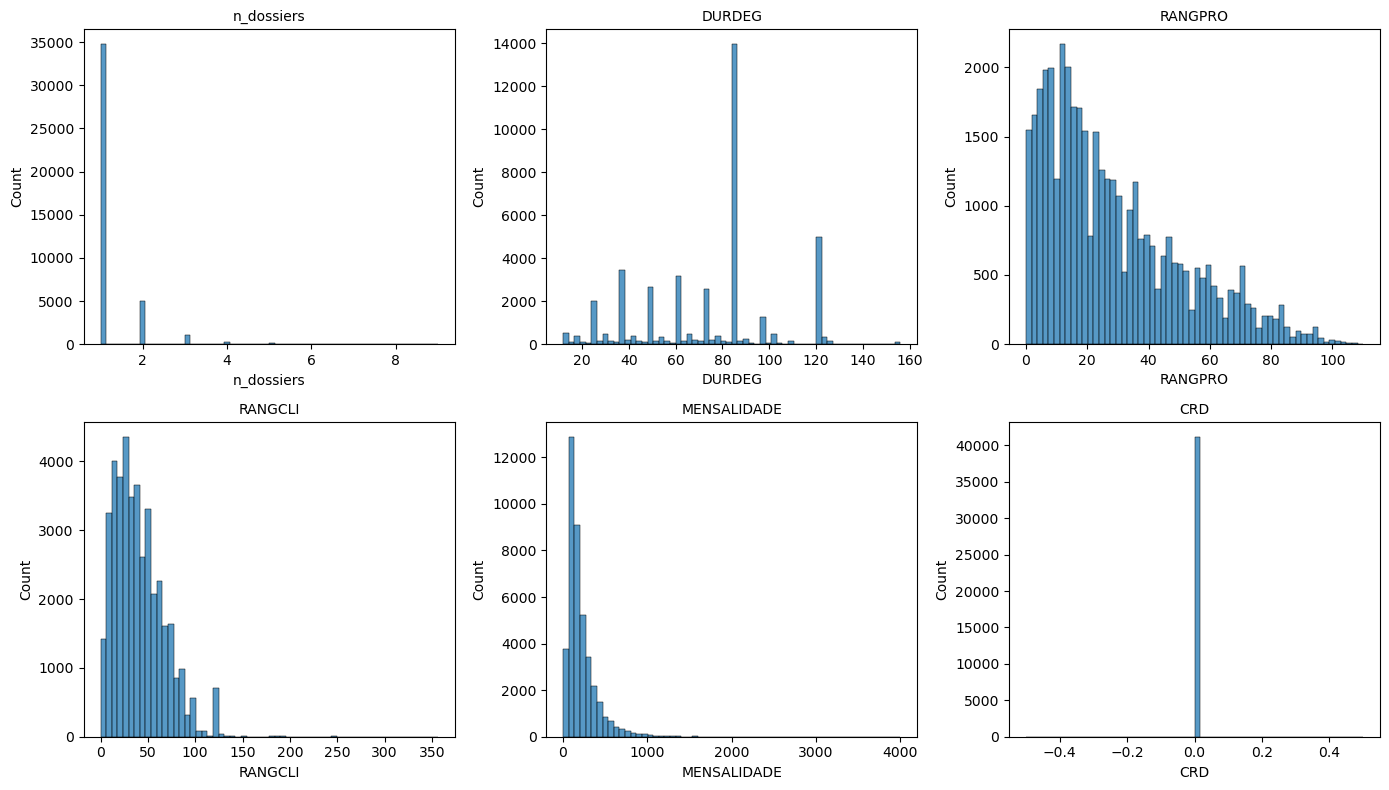

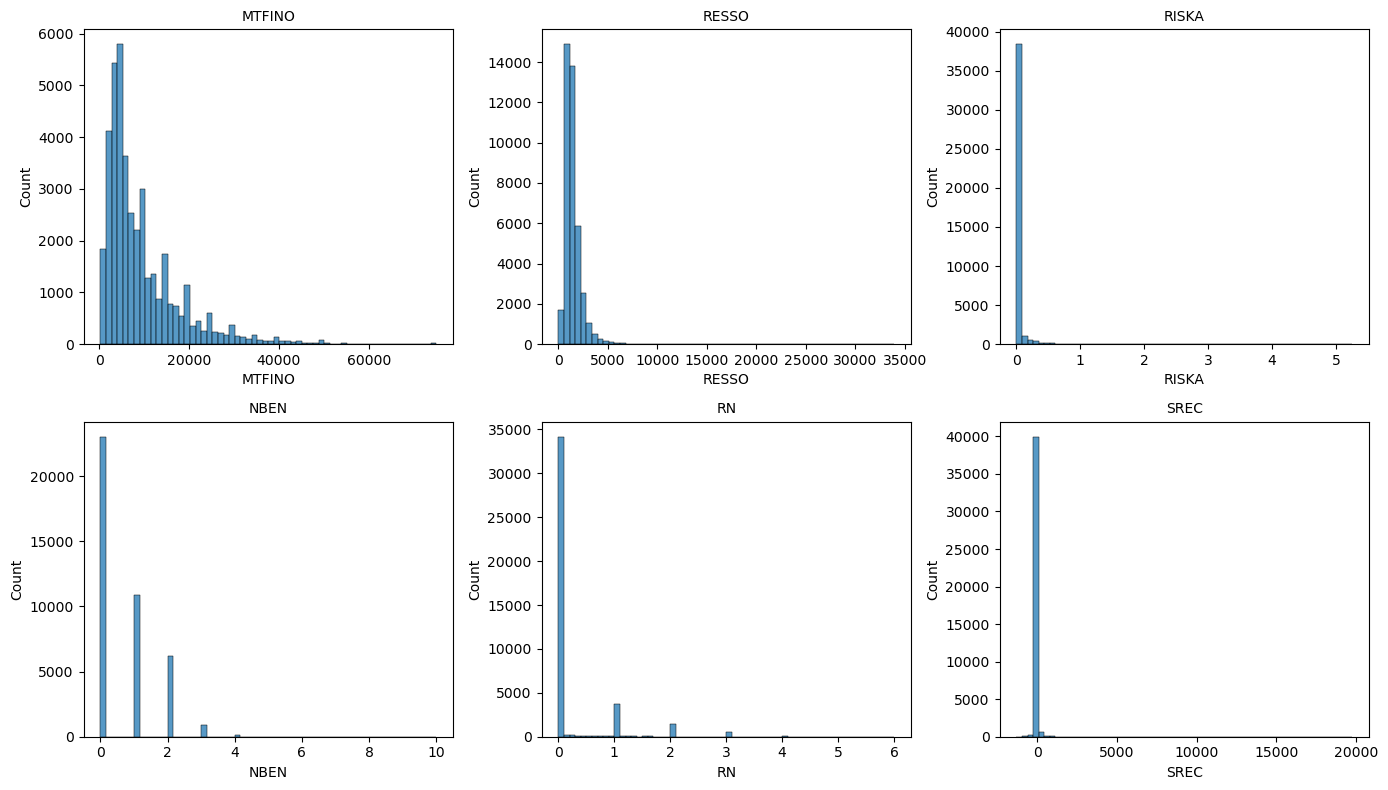

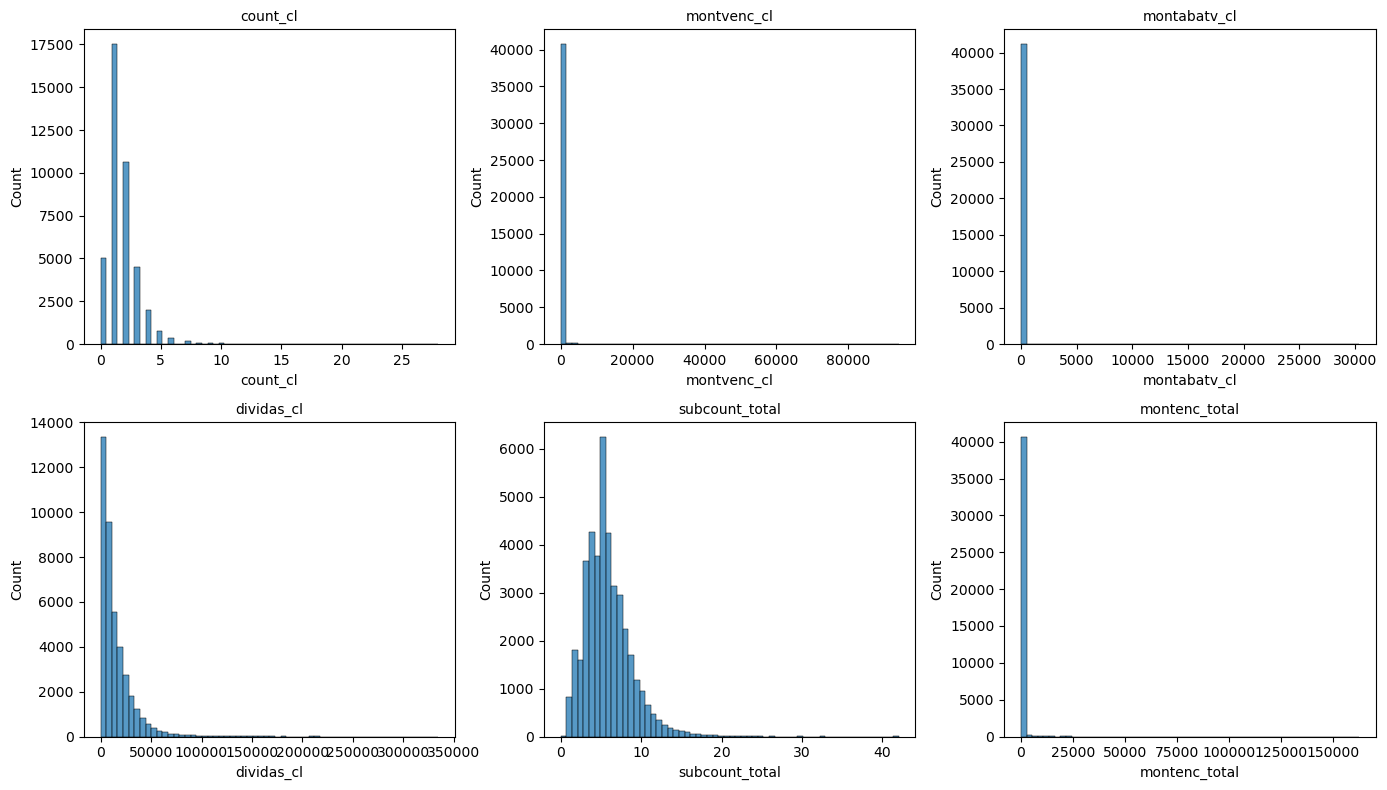

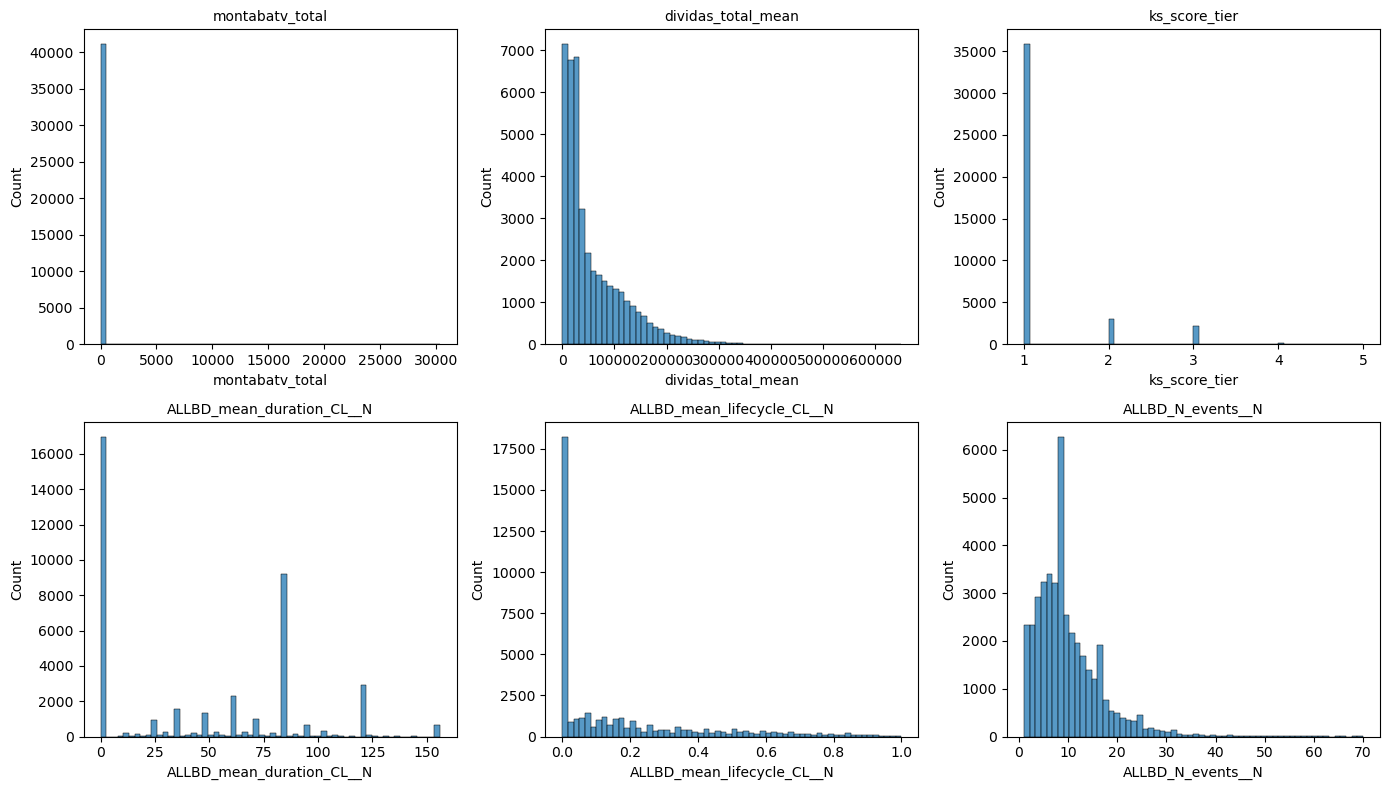

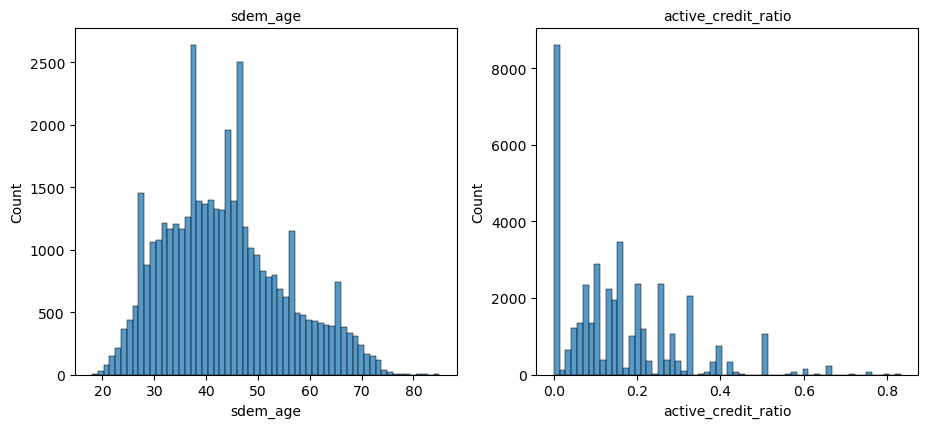

In [19]:
# Sampling
N = 200_000
sample = BNP_san.sample(n=min(N, len(BNP_san)), random_state=42)

cols = metric_features  # all 20 variables

plots_per_fig = 6   # 2 rows x 3 cols
n_figs = ceil(len(cols) / plots_per_fig)

for f in range(n_figs):
    
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    for ax, col in zip(axes, subset_cols):
        sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax)
        ax.set_title(col, fontsize=10)
    
    # Remove empty subplots if last figure has fewer than 6 plots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

In [22]:
BNP_san.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41162 entries, 00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981 to ffffe82f7c91df4a087341fe89db094be2a89294f2178572b937a270b0c9f669
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   n_dossiers                  41162 non-null  int64  
 1   DURDEG                      41162 non-null  float64
 2   RANGPRO                     41162 non-null  float64
 3   RANGCLI                     41162 non-null  float64
 4   MENSALIDADE                 41162 non-null  float64
 5   CRD                         41162 non-null  float64
 6   MTFINO                      41162 non-null  float64
 7   RESSO                       41162 non-null  float64
 8   RISKA                       41162 non-null  float64
 9   NBEN                        41162 non-null  float64
 10  RN                          41162 non-null  float64
 11  SREC                        

In [23]:
BNP_sol['n_dossiers'].value_counts()

n_dossiers
1    25424
2      769
3       60
4        3
7        1
Name: count, dtype: int64

In [24]:
BNP_sol['RISKA'].value_counts()

RISKA
0.000000    23961
1.000000      150
0.333333      122
0.111111      103
0.500000      102
            ...  
0.956522        1
0.434783        1
3.333333        1
0.038462        1
0.023810        1
Name: count, Length: 215, dtype: int64

In [25]:
BNP_sol['SREC'].value_counts()

SREC
 0.000000      24939
 0.897467         11
 1.495778          9
 1.035538          9
 1.121833          7
               ...  
-87.585462         1
-183.692400        1
-30.803200         1
 40.165000         1
 68.820789         1
Name: count, Length: 1223, dtype: int64

In [26]:
BNP_sol['count_cl'].value_counts()

count_cl
1     14290
0      5347
2      4134
3      1446
4       563
5       248
6       117
7        44
8        27
9        16
11        9
10        8
15        2
16        2
14        2
12        1
13        1
Name: count, dtype: Int64

In [27]:
BNP_sol['CHURN'].value_counts()

CHURN
1    25616
0      641
Name: count, dtype: int64

In [28]:
BNP_san['CHURN'].value_counts()

CHURN
1    32626
0     8536
Name: count, dtype: int64

In [29]:
BNP_sol['montvenc_cl'].value_counts()

montvenc_cl
0.000000       24555
2.892400           2
39.077778          2
8.924800           2
0.480000           2
               ...  
18.519600          1
16.956000          1
1380.167200        1
178.855833         1
2.475200           1
Name: count, Length: 1693, dtype: int64

In [30]:
BNP_sol['montabatv_cl'].value_counts()

montabatv_cl
0.000000        26218
16.772727           1
1449.297727         1
6745.975263         1
1128.904000         1
5594.474375         1
50000.000000        1
3803.874000         1
341.002083          1
0.001200            1
229.410500          1
6997.060800         1
170.390400          1
16698.920000        1
249.652000          1
746.614000          1
82.203200           1
1595.836000         1
2.040000            1
571.029375          1
26754.440000        1
1220.435333         1
1804.684800         1
1542.735385         1
149.803200          1
8945.188800         1
270.010000          1
2822.020000         1
849.220000          1
0.225200            1
1068.486800         1
5243.368696         1
137.186800          1
12264.637000        1
198.483333          1
138.422632          1
6001.940000         1
747.409200          1
46.546800           1
6588.512273         1
Name: count, dtype: int64

In [31]:
BNP_sol['RESSO'].value_counts()

RESSO
1045.234000    372
1318.257000    366
0.000000       351
909.708000     314
977.381000     305
              ... 
2713.455000      1
1728.349667      1
2758.576000      1
4260.010000      1
1483.156000      1
Name: count, Length: 4734, dtype: int64

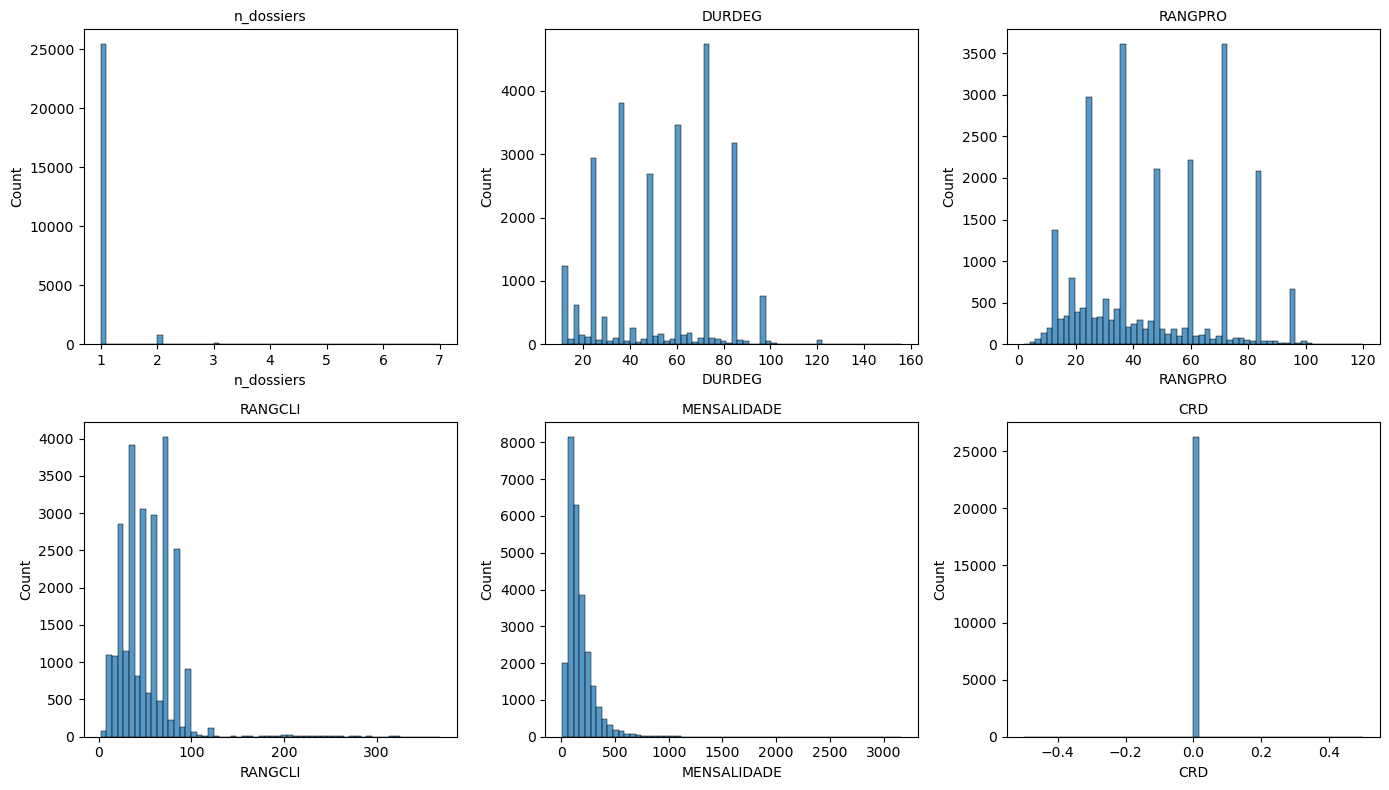

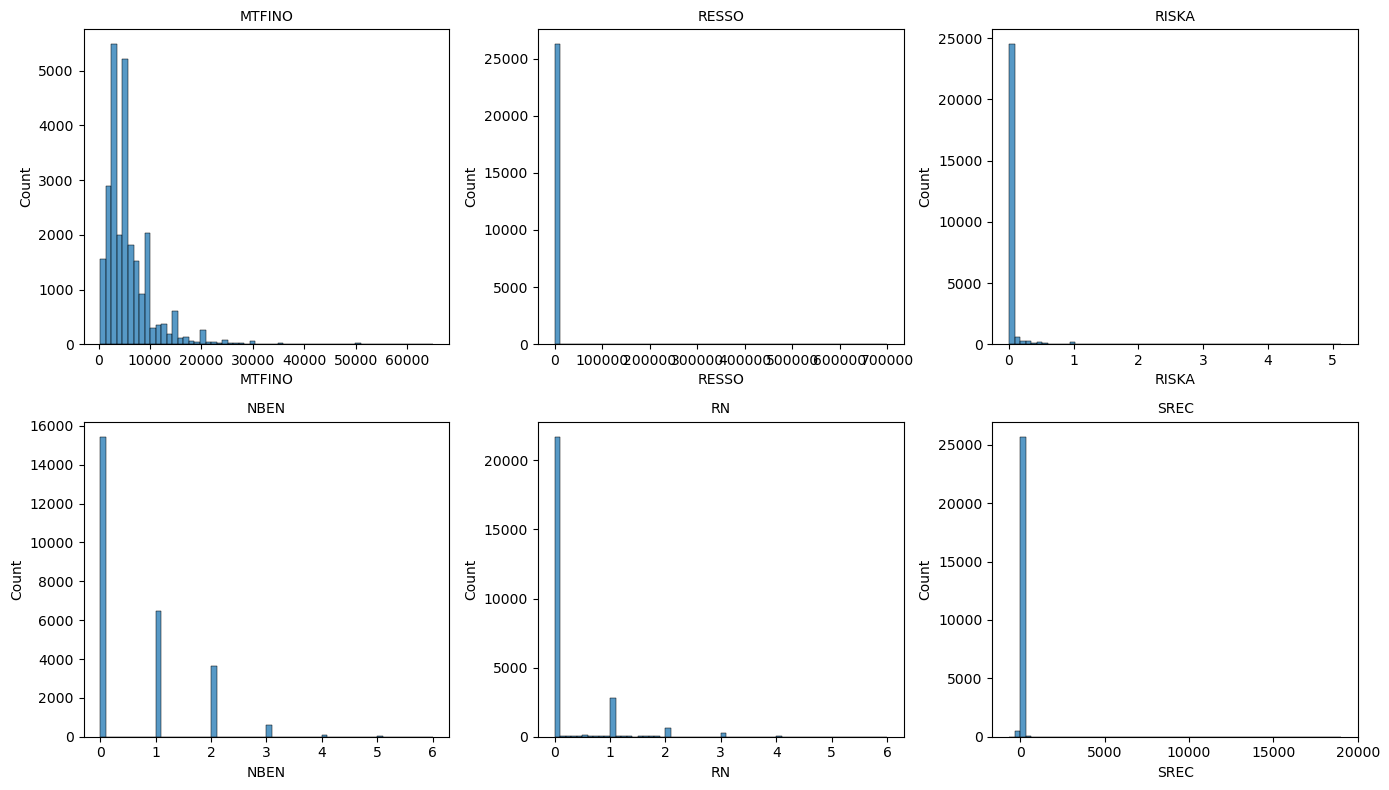

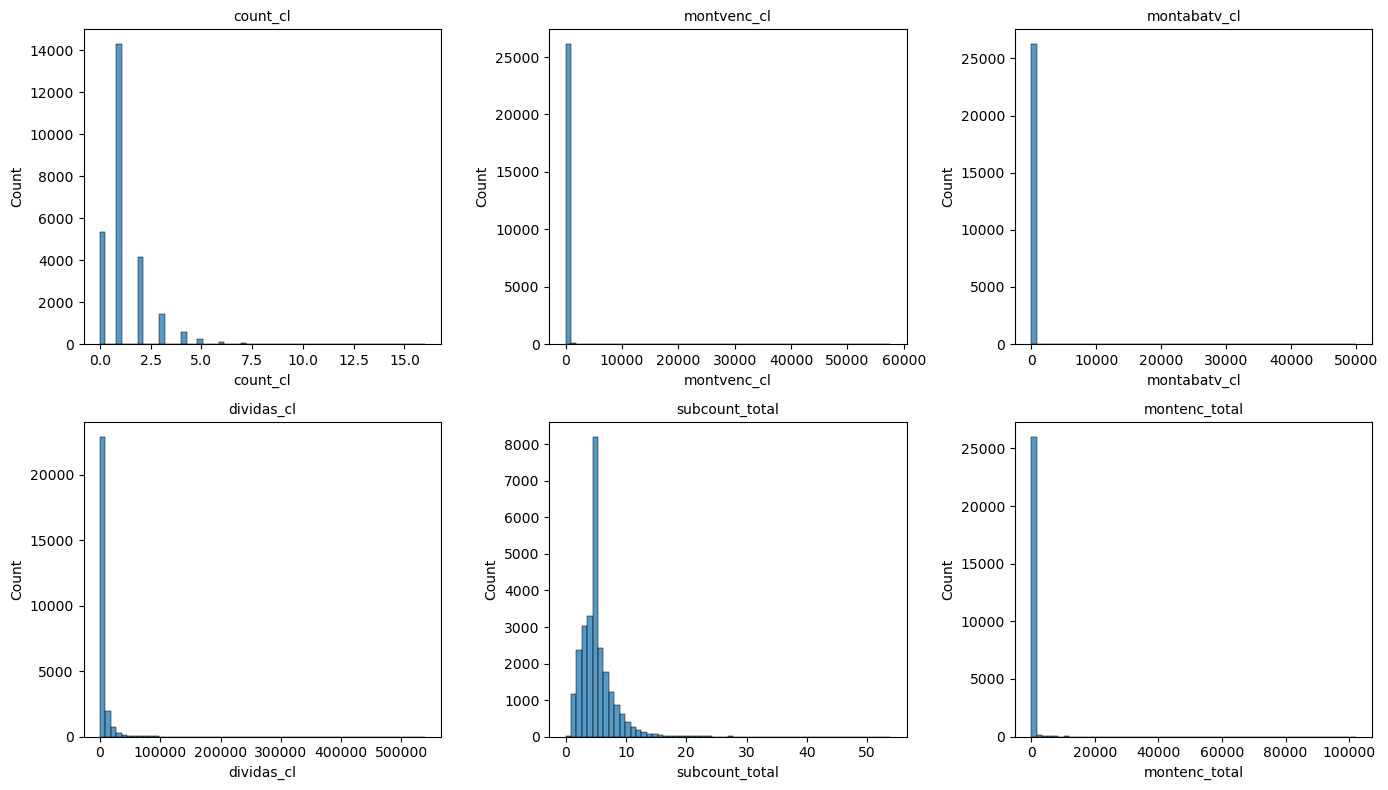

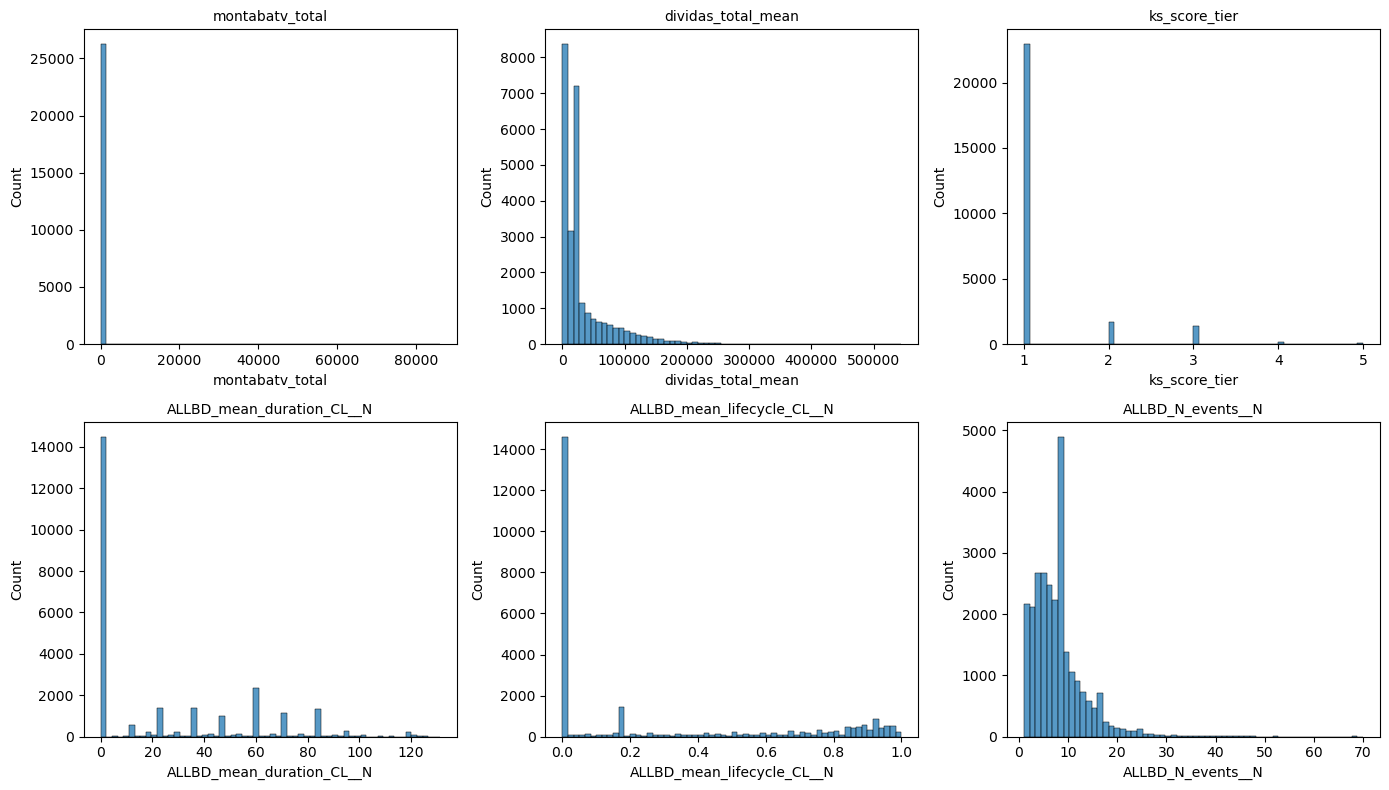

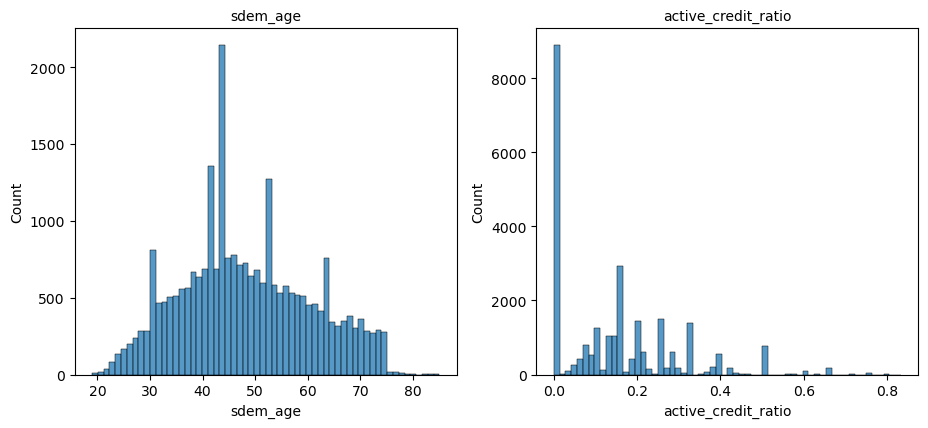

In [32]:
# Sampling
N = 200_000
sample = BNP_sol.sample(n=min(N, len(BNP_sol)), random_state=42)

cols = metric_features  # all 20 variables

plots_per_fig = 6   # 2 rows x 3 cols
n_figs = ceil(len(cols) / plots_per_fig)

for f in range(n_figs):
    
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    for ax, col in zip(axes, subset_cols):
        sns.histplot(sample[col].dropna(), bins=60, kde=False, ax=ax)
        ax.set_title(col, fontsize=10)
    
    # Remove empty subplots if last figure has fewer than 6 plots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()

In [33]:
BNP_sol['montenc_total'].value_counts()

montenc_total
0.000000       22628
0.600000          40
1.200000           7
1.000000           7
1.600000           6
               ...  
114.330000         1
1935.340714        1
2.601200           1
15.384800          1
48.373846          1
Name: count, Length: 3514, dtype: int64

In [181]:
BNP_sol.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26257 entries, 0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a to fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b
Data columns (total 40 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   n_dossiers                  26257 non-null  int64  
 1   DURDEG                      26257 non-null  float64
 2   RANGPRO                     26257 non-null  float64
 3   RANGCLI                     26257 non-null  float64
 4   MENSALIDADE                 26257 non-null  float64
 5   CRD                         26257 non-null  float64
 6   MTFINO                      26257 non-null  float64
 7   RESSO                       26257 non-null  float64
 8   RISKA                       26257 non-null  float64
 9   NBEN                        26257 non-null  Int32  
 10  RN                          26257 non-null  float64
 11  SREC                        

In [183]:
BNP_sol[BNP_sol['RESSO'] > 4000].count()

n_dossiers                    611
DURDEG                        611
RANGPRO                       611
RANGCLI                       611
MENSALIDADE                   611
CRD                           611
MTFINO                        611
RESSO                         611
RISKA                         611
NBEN                          611
RN                            611
SREC                          611
POLE                          611
PRODALP                       611
AGFIN                         611
PAGAMENTO                     611
CSP                           611
NATIO                         611
PTT                           611
MODCONTACTO                   611
CHURN                         611
count_cl                      611
montvenc_cl                   611
montabatv_cl                  611
dividas_cl                    611
subcount_total                611
montenc_total                 611
montabatv_total               611
dividas_total_mean            611
HIGH_RISK_CURR

<div class="alert alert-block alert-info">

<a class="anchor" id="3. Data Preparation">    </a>
# 3. Data preparation
       
</div>

<a class="anchor" id="3.5 feature selection">

## 3.4. Feature Engineering
    
</a>

In [296]:
BNP_sol[BNP_sol['RESSO'] < 900].count()

n_dossiers                    6737
DURDEG                        6737
RANGPRO                       6737
RANGCLI                       6737
MENSALIDADE                   6737
CRD                           6737
MTFINO                        6737
RESSO                         6737
RISKA                         6737
NBEN                          6737
RN                            6737
SREC                          6737
POLE                          6737
PRODALP                       6737
AGFIN                         6737
PAGAMENTO                     6737
CSP                           6737
NATIO                         6737
PTT                           6737
MODCONTACTO                   6737
CHURN                         6737
count_cl                      6737
montvenc_cl                   6737
montabatv_cl                  6737
dividas_cl                    6737
subcount_total                6737
montenc_total                 6737
montabatv_total               6737
dividas_total_mean  

In [297]:
#creating the variable 'IncomeCategory' that indicates whether a customer has low, middle or high income
BNP_sol['LowIncome'] = np.where (BNP_sol['RESSO'] < 1000, 'Low Income', None)
BNP_sol['MiddleIncome'] = np.where((BNP_sol['RESSO'] >= 1000) & (BNP_sol['RESSO'] <= 3500), 'Middle Income', None)
BNP_sol['HighIncome'] = np.where (BNP_sol['RESSO'] > 3500, 'High Income', None)

BNP_sol['IncomeCategory'] = BNP_sol['HighIncome'].combine_first(BNP_sol['LowIncome']).combine_first(BNP_sol['MiddleIncome'])
BNP_sol.drop(columns=['HighIncome', 'LowIncome', 'MiddleIncome'], inplace=True)

In [298]:
#creating the variable 'IncomeCategory' that indicates whether a customer has low, middle or high income
BNP_san['LowIncome'] = np.where (BNP_san['RESSO'] < 1000, 'Low Income', None)
BNP_san['MiddleIncome'] = np.where((BNP_san['RESSO'] >= 1000) & (BNP_san['RESSO'] <= 3500), 'Middle Income', None)
BNP_san['HighIncome'] = np.where (BNP_san['RESSO'] > 3500, 'High Income', None)

BNP_san['IncomeCategory'] = BNP_san['HighIncome'].combine_first(BNP_san['LowIncome']).combine_first(BNP_san['MiddleIncome'])
BNP_san.drop(columns=['HighIncome', 'LowIncome', 'MiddleIncome'], inplace=True)

In [299]:
BNP_sol['IncomeCategory'].value_counts()

IncomeCategory
Middle Income    15594
Low Income        9799
High Income        864
Name: count, dtype: int64

In [300]:
BNP_san['IncomeCategory'].value_counts()

IncomeCategory
Middle Income    29483
Low Income       10543
High Income       1136
Name: count, dtype: int64

In [301]:
BNP_sol['installment_ratio'] = np.where(
    BNP_sol['RESSO'] != 0,
    BNP_sol['MENSALIDADE'] / BNP_sol['RESSO'],
    0
)

In [302]:
BNP_san['installment_ratio'] = np.where(
    BNP_san['RESSO'] != 0,
    BNP_san['MENSALIDADE'] / BNP_san['RESSO'],
    0
)

In [303]:
BNP_sol['installment_ratio'].max()

1019.6022644811976

In [304]:
BNP_sol.describe()

,n_dossiers,DURDEG,RANGPRO,RANGCLI,MENSALIDADE,CRD,MTFINO,RESSO,RISKA,NBEN,RN,SREC,AGFIN,CSP,PTT,CHURN,count_cl,montvenc_cl,montabatv_cl,dividas_cl,subcount_total,montenc_total,montabatv_total,dividas_total_mean,HIGH_RISK_CURRENT,ks_score_tier,is_risky,ALLBD_mean_duration_CL__N,ALLBD_mean_lifecycle_CL__N,ALLBD_N_events__N,sdem_age,active_credit_ratio,installment_ratio
count,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.0,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000
mean,1.034429,53.116564,46.756365,52.611488,171.747250,0.0,5855.352467,1444.841921,0.030498,0.607457,0.224851,7.969287,119.576303,63.267852,4076.121568,0.975587,1.220703,41.339897,6.596992,5384.583353,5.157390,98.433962,13.634376,33633.267661,0.138782,1.202689,0.860609,24.286032,0.277626,7.834977,48.184636,0.144943,0.226992
std,0.199106,23.459343,23.650478,27.918834,127.342656,0.0,4894.305769,4511.684187,0.181445,0.837112,0.576449,247.291171,23.689938,21.809413,2003.259198,0.154329,1.118886,886.864515,390.113738,9610.755817,2.549635,1530.881000,693.839408,43274.173982,0.345726,0.591405,0.346361,31.909492,0.372294,5.107468,12.292106,0.146711,6.956016
min,1.000000,11.000000,2.000000,2.000000,8.986745,0.0,300.000000,0.000000,0.000000,0.0,0.000000,-678.439500,100.000000,0.000000,1000.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000,0.0,0.000000,0.000000,1.000000,19.000000,0.000000,0.000000
25%,1.000000,36.000000,24.000000,35.000000,98.389630,0.0,2500.000000,893.495000,0.000000,0.0,0.000000,0.000000,117.000000,56.000000,2700.000000,1.000000,1.0,0.000000,0.000000,462.738667,3.565217,0.000000,0.000000,5601.021667,0.0,1.000000,1.0,0.000000,0.000000,4.000000,39.000000,0.000000,0.071202
50%,1.000000,59.000000,42.000000,48.000000,133.210021,0.0,5000.000000,1145.966000,0.000000,0.0,0.000000,0.000000,118.000000,70.000000,3680.000000,1.000000,1.0,0.000000,0.000000,2715.462000,5.200000,0.000000,0.000000,25702.332800,0.0,1.000000,1.0,0.000000,0.000000,7.000000,47.000000,0.125000,0.113105
75%,1.000000,72.000000,72.000000,72.000000,209.995221,0.0,7010.000000,1650.147000,0.000000,1.0,0.000000,0.000000,119.000000,80.000000,4700.000000,1.000000,2.0,0.000000,0.000000,7120.235200,6.000000,0.000000,0.000000,34569.331053,0.0,1.000000,1.0,48.000000,0.666667,10.000000,57.000000,0.222222,0.178061
max,7.000000,156.000000,120.000000,368.000000,3166.392662,0.0,65000.000000,700000.000000,5.133333,6.0,6.000000,19029.501333,525.000000,99.000000,9980.000000,1.000000,16.0,57623.850909,50000.000000,538591.304000,53.857143,102188.457778,85972.660000,544613.300000,1.0,5.000000,1.0,131.000000,1.000000,70.000000,85.000000,0.833333,1019.602264


In [305]:
BNP_sol['has_overdue']  = (BNP_sol['montvenc_cl'] > 0).astype(int)
BNP_sol['has_writeoff'] = (BNP_sol['montabatv_total'] > 0).astype(int)
BNP_sol['has_recovery'] = (BNP_sol['RN'] > 0).astype(int)
BNP_san['has_overdue']  = (BNP_san['montvenc_cl'] > 0).astype(int)
BNP_san['has_writeoff'] = (BNP_san['montabatv_total'] > 0).astype(int)
BNP_san['has_recovery'] = (BNP_san['RN'] > 0).astype(int)

<a class="anchor" id="3.5 feature selection">

## 3.5 Feature selection
    
</a>

<a class="anchor" id="3.5.1 variance">

### 3.5.1 Variance
    
</a>

In [209]:
#checking metric features' variance 
BNP_san[metric_features].var()

n_dossiers                             0.293629
DURDEG                               834.811437
RANGPRO                              495.500542
RANGCLI                              726.420821
MENSALIDADE                         29735.90502
CRD                                         0.0
MTFINO                          78607288.058569
RESSO                             854764.462448
RISKA                                  0.040525
NBEN                                    0.70968
RN                                     0.379561
SREC                               51157.930463
count_cl                               1.874216
montvenc_cl                      1800474.102108
montabatv_cl                       33858.459413
dividas_cl                      314789051.65256
subcount_total                         8.220582
montenc_total                     4597924.81067
montabatv_total                    48113.553886
dividas_total_mean            3653859350.944413
ks_score_tier                          0

In [30]:
BNP_san['active_credit_ratio'].value_counts(normalize=True).head()

active_credit_ratio
0.000000    0.209174
0.166667    0.064696
0.250000    0.057116
0.200000    0.056946
0.333333    0.049973
Name: proportion, dtype: float64

In [31]:
BNP_san['RISKA'].value_counts(normalize=True).head()

RISKA
0.000000    0.905763
0.111111    0.004859
0.333333    0.004737
0.200000    0.003863
0.250000    0.003814
Name: proportion, dtype: float64

- *CRD* is a constant variable, so it is not useful.
- *RISKA* has 90% of the observations with the value 0, so we consider that this feature is quasi-constant.

In [30]:
#checking metric features' variance 
BNP_sol[metric_features].var()

n_dossiers                            0.039643
DURDEG                               550.34079
RANGPRO                               559.3451
RANGCLI                             779.461264
MENSALIDADE                       16216.152107
CRD                                        0.0
MTFINO                         23954228.964335
RESSO                          20355294.201054
RISKA                                 0.032922
NBEN                                  0.700756
RN                                    0.332293
SREC                              61152.923095
count_cl                              1.251905
montvenc_cl                      786528.667604
montabatv_cl                     152188.728855
dividas_cl                     92366627.372698
subcount_total                        6.500638
montenc_total                   2343596.635229
montabatv_total                  481413.124318
dividas_total_mean            1872654133.81721
ks_score_tier                          0.34976
ALLBD_mean_du

In [31]:
BNP_sol['active_credit_ratio'].value_counts(normalize=True).head()

active_credit_ratio
0.000000    0.338919
0.166667    0.100773
0.250000    0.056633
0.200000    0.055185
0.333333    0.052710
Name: proportion, dtype: float64

In [32]:
BNP_sol['RISKA'].value_counts(normalize=True).head()

RISKA
0.000000    0.912557
1.000000    0.005713
0.333333    0.004646
0.111111    0.003923
0.500000    0.003885
Name: proportion, dtype: float64

<a class="anchor" id="3.5.2 Redundancy and Relevancy">

### 3.5.2 Redundancy and Relevancy
    
</a>

<a class="anchor" id="3.5.2.1 Numerical Features">

### 3.5.2.1 Numerical features
    
</a>

In [33]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman_san= BNP_san[metric_features].corr(method ='spearman')
cor_spearman_sol= BNP_sol[metric_features].corr(method ='spearman')

In [34]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap='YlGnBu',            #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

'''This function visualises a correlation matrix using a heatmap to
facilitate interpretation of relationships between variables. By 
masking the upper triangle of the matrix, the plot avoids redundant
information and improves the readability. '''

'This function visualises a correlation matrix using a heatmap to\nfacilitate interpretation of relationships between variables. By \nmasking the upper triangle of the matrix, the plot avoids redundant\ninformation and improves the readability. '

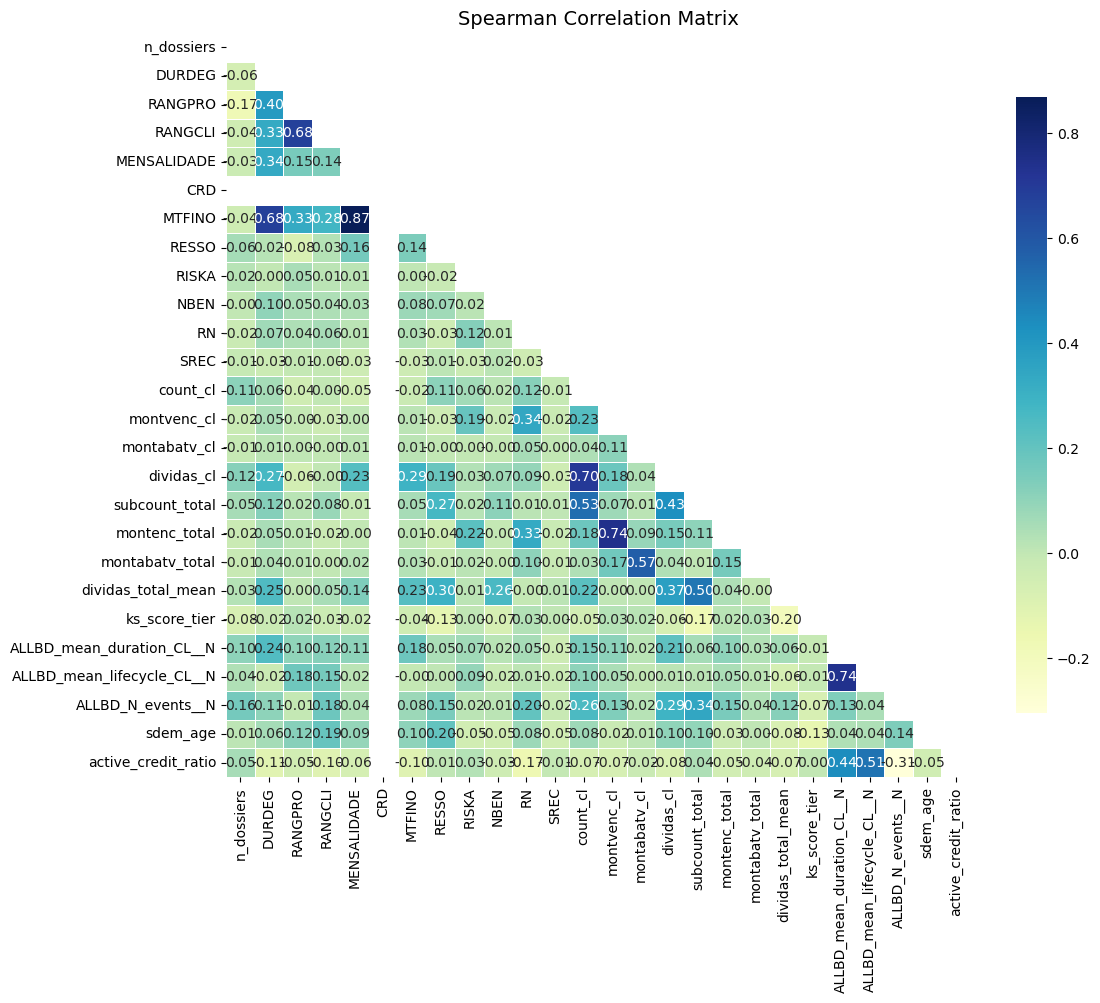

In [35]:
#applying the function to our numerical features
cor_heatmap(cor_spearman_san)

Redundant Features (Considering >0.8): 
- *MENSALIDADE* vs *MTFINO* (0.87)

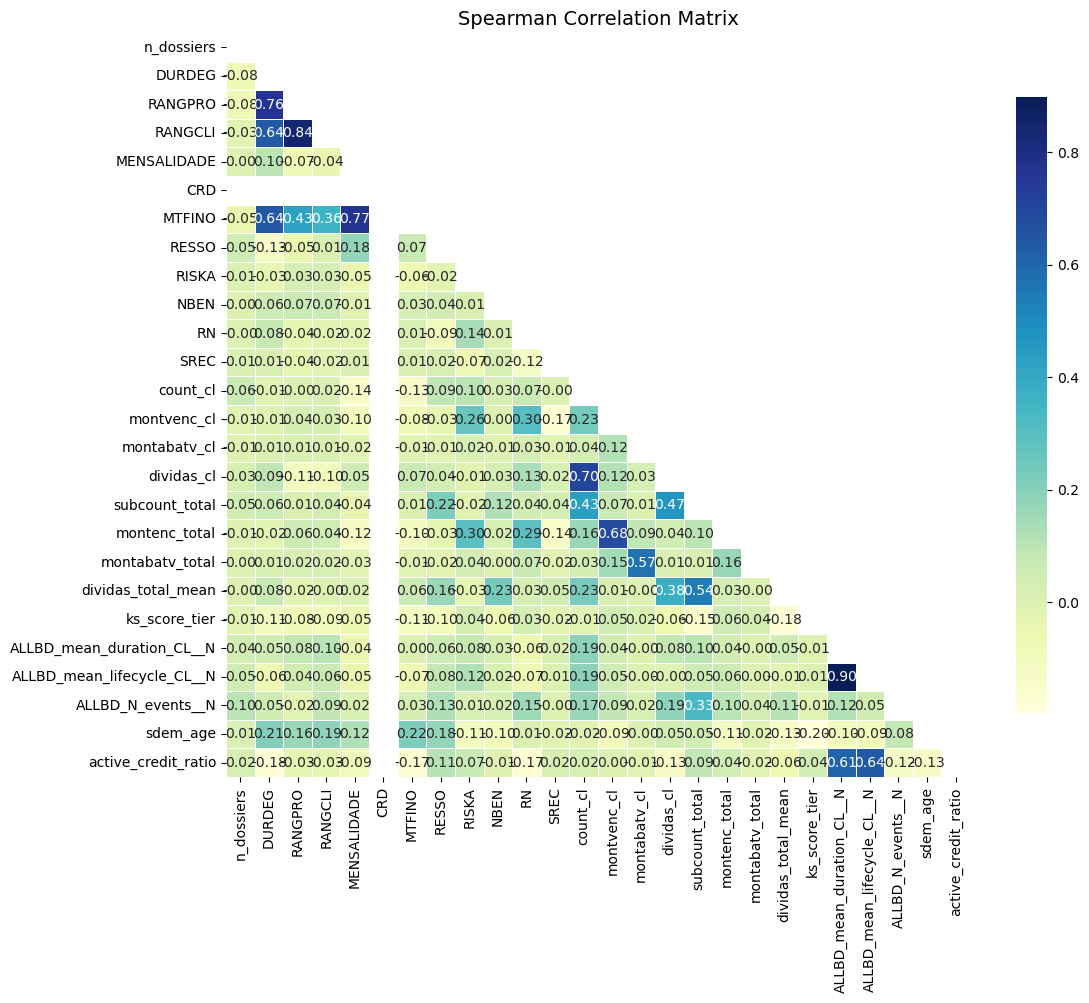

In [36]:
#applying the function to our numerical features
cor_heatmap(cor_spearman_sol)

Redundant Features (Considering >0.8): 
- *RANGCLI* vs *RANGPRO* (0.84)
- *dividas_cl* vs *count_cl* (0.81)
- *ALLBD_mean_lifecycle_CL_N* vs **ALLBD_mean_duration_CL_N* (0.90)

In [17]:
BNP_san['ALLBD_mean_lifecycle_CL__N']

CONTRIB
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981    0.033333
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8    0.000000
0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5    0.055556
000803da8192598bfa2bbd780df6da11b3fe54ff3327487821f060bd3de69e76    0.277778
000a129438776dca90f4359642f343cb037d9afe60897fd1676ac48cd21d2046    0.016667
                                                                      ...   
fffbfb06fdb05fb48a739b0a23650122a66ff61669a5b3e34d22144d0f0c2049    0.350000
fffc5ec9541c7691c7759c637317530910cf44783e4209f205e28474646bad6a    0.138889
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67dc5b24a0b5f3260e7    0.000000
fffe8c5cbb44ad3ec6154ef5a5208ecd76594a88377f00c5ce4e07c92bfe1f3b    0.064103
ffffe82f7c91df4a087341fe89db094be2a89294f2178572b937a270b0c9f669    0.000000
Name: ALLBD_mean_lifecycle_CL__N, Length: 41162, dtype: float64

In [14]:
BNP_sol.drop(['RANGPRO', 'dividas_cl', 'ALLBD_mean_lifecycle_CL__N', 'MENSALIDADE', 'CRD', 'RISKA'], axis=1, inplace=True)
BNP_san.drop(['RANGPRO', 'dividas_cl', 'ALLBD_mean_lifecycle_CL__N', 'MENSALIDADE', 'CRD', 'RISKA'], axis=1, inplace=True)

<a class="anchor" id="3.5.2.2 categorical Features">

### 3.5.2.2 Categorical features
    
</a>

In [32]:
#categorical features
non_metric_features = ['POLE', 'PRODALP', 'AGFIN ', 'PAGAMENTO', 'CSP', 'NATIO', 'PTT', 'MODCONTACTO', 
                       'CHURN', 'HIGH_RISK_CURRENT', 'kp_sqe', 'is_risky', 'sdem_SITFAM', 'sdem_HABITAT'] 

In [38]:
BNP_sol['CSP'].value_counts()

CSP
80    6821
60    5526
70    2394
31    2151
90    1604
91    1007
74     697
15     672
20     634
81     530
35     521
30     476
41     475
56     460
32     417
92     403
10     275
33     185
86     175
50     148
54     122
40     111
55      91
52      83
58      72
57      61
96      43
34      33
53      32
99      17
25      10
0        9
51       2
Name: count, dtype: int64

In [39]:
#how many clients exists for each classification (Alphabetical order)
BNP_sol['kp_sqe'] \
    .value_counts(dropna=False) \
    .sort_index()

kp_sqe
A           1924
B            857
C            566
D            580
E            737
F            672
G            382
H            480
I            138
J             62
K             39
M              7
U             92
Unknown    19598
V              2
W            121
Name: count, dtype: int64

<a class="anchor" id="3.6 Scaling">

## 3.6 Scaling
    
</a>

In [306]:
#log transform the skewed variables
skewed_vars = [
    'NBEN',
    'montvenc_cl',
    'montabatv_cl',
    'montenc_total',
    'montabatv_total',
    'ALLBD_mean_lifecycle_CL__N',
    'ALLBD_mean_duration_CL__N',
    'ks_score_tier'
]

BNP_sol[skewed_vars] = np.log1p(BNP_sol[skewed_vars])
BNP_san[skewed_vars] = np.log1p(BNP_san[skewed_vars])

In [307]:
p99 = BNP_sol['RESSO'].quantile(0.99)
BNP_sol['RESSO_log'] = np.log1p(BNP_sol['RESSO'].clip(upper=p99))
p99 = BNP_san['RESSO'].quantile(0.99)
BNP_san['RESSO_log'] = np.log1p(BNP_san['RESSO'].clip(upper=p99))

In [308]:
BNP_sol.drop(['RESSO'], axis=1, inplace=True)
BNP_san.drop(['RESSO'], axis=1, inplace=True)

In [309]:
for col in skewed_vars:
    BNP_sol[f'{col}_log'] = np.log1p(BNP_sol[col])
    BNP_san[f'{col}_log'] = np.log1p(BNP_san[col])

In [310]:
BNP_sol.drop(columns=skewed_vars, inplace=True)
BNP_san.drop(columns=skewed_vars, inplace=True)

In [311]:
BNP_sol.head()

,n_dossiers,DURDEG,RANGPRO,RANGCLI,MENSALIDADE,CRD,MTFINO,RISKA,RN,SREC,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,CHURN,count_cl,dividas_cl,subcount_total,dividas_total_mean,HIGH_RISK_CURRENT,kp_sqe,is_risky,ALLBD_N_events__N,sdem_SITFAM,sdem_HABITAT,sdem_age,active_credit_ratio,IncomeCategory,installment_ratio,has_overdue,has_writeoff,has_recovery,RESSO_log,NBEN_log,montvenc_cl_log,montabatv_cl_log,montenc_total_log,montabatv_total_log,ALLBD_mean_lifecycle_CL__N_log,ALLBD_mean_duration_CL__N_log,ks_score_tier_log
CONTRIB,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,2,60.0,21.0,21.0,304.456898,0.0,9726.555,0.0,1.0,0.0,P,EP,117.0,P,60,P,2745,T,1,1,7120.2352,5.20,26643.3160,0,Unknown,1,8,C,A,44,0.166667,Low Income,0.448732,0,0,1,6.521332,0.741276,0.0,0.0,0.0,0.0,0.152123,1.631370,0.526589
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,1,84.0,24.0,24.0,274.916857,0.0,12000.000,0.0,1.0,0.0,P,EP,117.0,P,86,P,2835,W,1,1,7120.2352,5.20,26643.3160,0,Unknown,1,7,V,P,74,0.000000,Low Income,0.344592,0,0,1,6.683117,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.526589
000508d6436a34b780df1aa8068568f1b118f5d589ddc7bb33662295defff2aa,1,13.0,13.0,13.0,129.197279,0.0,1300.000,0.0,0.0,0.0,P,EP,117.0,P,80,P,4400,A,1,1,360.7696,7.16,1459.2796,0,Unknown,1,5,X,L,57,0.666667,Middle Income,0.113961,0,0,0,7.034120,0.0,0.0,0.0,0.0,0.0,0.321714,1.291725,0.526589
000607d1adce7aa9ac87274d1a2ffa84e240188de0872fc2cc3dc05d70d63560,1,60.0,60.0,60.0,128.983684,0.0,5000.000,0.0,0.0,0.0,P,EP,118.0,P,60,P,9680,A,1,1,4529.6216,5.64,58294.6068,0,A,0,9,C,P,41,0.100000,Low Income,0.141366,0,0,0,6.817186,0.741276,0.0,0.0,0.0,0.0,0.000000,0.000000,0.526589
00074b200f6c11a8731d6da396546e8d2e7be5621c931b9a039789b1a92f86e6,1,60.0,25.0,34.0,147.460428,0.0,5150.890,0.0,1.0,0.0,P,EPF,117.0,P,74,P,8135,W,1,0,0.0000,1.00,55281.7800,0,W,1,6,C,P,42,0.000000,Middle Income,0.124814,0,0,1,7.075336,0.741276,0.0,0.0,0.0,0.0,0.000000,0.000000,0.526589


In [312]:
'''metric_features = ['n_dossiers', 'DURDEG', 'RANGPRO', 'RANGCLI_log', 
                   'MTFINO_log', 'RESSO_log', 'RISKA_log', 'NBEN_log', 'RN_log', 'SREC_log', 'count_cl_log', 'montvenc_cl_log',
                   'montabatv_cl_log', 'subcount_total_log', 'montenc_total_log', 
                   'montabatv_total_log', 'dividas_total_mean_log', 'ks_score_tier', 'ALLBD_mean_duration_CL__N_log', 
                    'ALLBD_N_events__N_log', 'sdem_age', 'active_credit_ratio', 'installment_ratio']'''

"metric_features = ['n_dossiers', 'DURDEG', 'RANGPRO', 'RANGCLI_log', \n                   'MTFINO_log', 'RESSO_log', 'RISKA_log', 'NBEN_log', 'RN_log', 'SREC_log', 'count_cl_log', 'montvenc_cl_log',\n                   'montabatv_cl_log', 'subcount_total_log', 'montenc_total_log', \n                   'montabatv_total_log', 'dividas_total_mean_log', 'ks_score_tier', 'ALLBD_mean_duration_CL__N_log', \n                    'ALLBD_N_events__N_log', 'sdem_age', 'active_credit_ratio', 'installment_ratio']"

In [313]:
metric_features = ['n_dossiers', 'DURDEG', 'RANGCLI', 'MTFINO', 'RESSO_log', 'NBEN_log', 'RN', 'SREC', 'count_cl', 'montvenc_cl_log',
                   'montabatv_cl_log', 'subcount_total', 'montenc_total_log', 
                   'montabatv_total_log', 'dividas_total_mean', 'ks_score_tier_log', 'ALLBD_mean_duration_CL__N_log', 
                   'ALLBD_N_events__N', 'sdem_age', 'active_credit_ratio', 'installment_ratio'] 

In [314]:
BNP_sol_scaling = RobustScaler().fit_transform(BNP_sol[metric_features])
BNP_sol_scaled = pd.DataFrame(BNP_sol_scaling, columns=BNP_sol[metric_features].columns, index=BNP_sol[metric_features].index)

BNP_san_scaling = RobustScaler().fit_transform(BNP_san[metric_features])
BNP_san_scaled = pd.DataFrame(BNP_san_scaling, columns=BNP_san[metric_features].columns, index=BNP_san[metric_features].index)

In [315]:
BNP_san_scaled.head()

,n_dossiers,DURDEG,RANGCLI,MTFINO,RESSO_log,NBEN_log,RN,SREC,count_cl,montvenc_cl_log,montabatv_cl_log,subcount_total,montenc_total_log,montabatv_total_log,dividas_total_mean,ks_score_tier_log,ALLBD_mean_duration_CL__N_log,ALLBD_N_events__N,sdem_age,active_credit_ratio,installment_ratio
CONTRIB,,,,,,,,,,,,,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,1.0,0.500000,-0.472222,0.647059,0.288297,0.000000,0.0,0.0,-1.0,0.0,0.0,0.000000,0.0,0.0,-0.212261,0.214687,0.121991,0.250,-0.6250,0.853755,0.210014
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,0.0,-0.333333,-0.055556,-0.470588,-0.707781,0.000000,1.0,0.0,0.0,0.0,0.0,-0.024691,0.0,0.0,-0.077069,0.000000,-0.915114,-0.625,1.6250,-0.782609,-0.419487
0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5,1.0,-0.833333,0.541667,-0.294118,1.173372,1.407694,0.0,0.0,2.0,0.0,0.0,0.025814,0.0,0.0,0.479879,0.000000,-0.012996,0.125,0.4375,-0.182609,-0.583355
000803da8192598bfa2bbd780df6da11b3fe54ff3327487821f060bd3de69e76,0.0,-1.333333,-0.527778,-0.294118,0.384351,0.000000,0.0,0.0,1.0,0.0,0.0,-0.000686,0.0,0.0,2.088100,0.000000,-0.012996,-0.625,-0.7500,0.717391,-0.186199
000a129438776dca90f4359642f343cb037d9afe60897fd1676ac48cd21d2046,1.0,-0.333333,0.069444,1.885278,-0.295060,1.407694,0.0,0.0,0.0,0.0,0.0,-0.827160,0.0,0.0,-0.132670,0.000000,0.047764,0.375,0.1250,0.217391,3.054802


In [316]:
BNP_sol = BNP_sol.copy()

# drop original unscaled metric features
BNP_sol.drop(columns=metric_features, inplace=True)

# add scaled versions
BNP_sol = BNP_sol.join(BNP_sol_scaled)

BNP_sol.head()

,RANGPRO,MENSALIDADE,CRD,RISKA,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,CHURN,dividas_cl,HIGH_RISK_CURRENT,kp_sqe,is_risky,sdem_SITFAM,sdem_HABITAT,IncomeCategory,has_overdue,has_writeoff,has_recovery,ALLBD_mean_lifecycle_CL__N_log,n_dossiers,DURDEG,RANGCLI,MTFINO,RESSO_log,NBEN_log,RN,SREC,count_cl,montvenc_cl_log,montabatv_cl_log,subcount_total,montenc_total_log,montabatv_total_log,dividas_total_mean,ks_score_tier_log,ALLBD_mean_duration_CL__N_log,ALLBD_N_events__N,sdem_age,active_credit_ratio,installment_ratio
CONTRIB,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,21.0,304.456898,0.0,0.0,P,EP,117.0,P,60,P,2745,T,1,7120.2352,0,Unknown,1,C,A,Low Income,0,0,1,0.152123,1.0,0.027778,-0.729730,1.048017,-0.854114,1.407694,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.032483,0.0,1.027593,0.166667,-0.166667,0.1875,3.140861
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,24.0,274.916857,0.0,0.0,P,EP,117.0,P,86,P,2835,W,1,7120.2352,0,Unknown,1,V,P,Low Income,0,0,1,0.000000,0.0,0.694444,-0.648649,1.552106,-0.590177,0.000000,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.032483,0.0,0.000000,0.000000,1.500000,-0.5625,2.166296
000508d6436a34b780df1aa8068568f1b118f5d589ddc7bb33662295defff2aa,13.0,129.197279,0.0,0.0,P,EP,117.0,P,80,P,4400,A,1,360.7696,0,Unknown,1,X,L,Middle Income,0,0,0,0.321714,0.0,-1.277778,-0.945946,-0.820399,-0.017547,0.000000,0.0,0.0,0.0,0.0,0.0,0.805000,0.0,0.0,-0.836882,0.0,0.813652,-0.333333,0.555556,2.4375,0.008011
000607d1adce7aa9ac87274d1a2ffa84e240188de0872fc2cc3dc05d70d63560,60.0,128.983684,0.0,0.0,P,EP,118.0,P,60,P,9680,A,1,4529.6216,0,A,0,C,P,Low Income,0,0,0,0.000000,0.0,0.027778,0.324324,0.000000,-0.371455,1.407694,0.0,0.0,0.0,0.0,0.0,0.180714,0.0,0.0,1.125101,0.0,0.000000,0.333333,-0.333333,-0.1125,0.264469
00074b200f6c11a8731d6da396546e8d2e7be5621c931b9a039789b1a92f86e6,25.0,147.460428,0.0,0.0,P,EPF,117.0,P,74,P,8135,W,1,0.0000,0,W,1,C,P,Middle Income,0,0,1,0.000000,0.0,0.027778,-0.378378,0.033457,0.049694,1.407694,1.0,0.0,-1.0,0.0,0.0,-1.725000,0.0,0.0,1.021097,0.0,0.000000,-0.166667,-0.277778,-0.5625,0.109575


In [317]:
BNP_san = BNP_san.copy()

# drop original unscaled metric features
BNP_san.drop(columns=metric_features, inplace=True)

# add scaled versions
BNP_san = BNP_san.join(BNP_san_scaled)

BNP_san.head()

,RANGPRO,MENSALIDADE,CRD,RISKA,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,CHURN,dividas_cl,HIGH_RISK_CURRENT,kp_sqe,is_risky,sdem_SITFAM,sdem_HABITAT,IncomeCategory,has_overdue,has_writeoff,has_recovery,ALLBD_mean_lifecycle_CL__N_log,n_dossiers,DURDEG,RANGCLI,MTFINO,RESSO_log,NBEN_log,RN,SREC,count_cl,montvenc_cl_log,montabatv_cl_log,subcount_total,montenc_total_log,montabatv_total_log,dividas_total_mean,ks_score_tier_log,ALLBD_mean_duration_CL__N_log,ALLBD_N_events__N,sdem_age,active_credit_ratio,installment_ratio
CONTRIB,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,8.0,219.380678,0.0,0.0,P,EP,118.0,P,74,P,8600,W,0,2565.793600,0,H,1,S,F,Middle Income,0,0,0,0.032264,1.0,0.500000,-0.472222,0.647059,0.288297,0.000000,0.0,0.0,-1.0,0.0,0.0,0.000000,0.0,0.0,-0.212261,0.214687,0.121991,0.250,-0.6250,0.853755,0.210014
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,34.0,56.017772,0.0,0.0,P,EP,120.0,N,91,P,2855,A,1,7120.235200,0,Unknown,1,S,A,Low Income,0,0,1,0.000000,0.0,-0.333333,-0.055556,-0.470588,-0.707781,0.000000,1.0,0.0,0.0,0.0,0.0,-0.024691,0.0,0.0,-0.077069,0.000000,-0.915114,-0.625,1.6250,-0.782609,-0.419487
0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5,28.5,106.760743,0.0,0.0,P,EP,118.0,P,35,P,4425,W,1,21840.323636,0,H,1,C,L,Middle Income,0,0,0,0.052656,1.0,-0.833333,0.541667,-0.294118,1.173372,1.407694,0.0,0.0,2.0,0.0,0.0,0.025814,0.0,0.0,0.479879,0.000000,-0.012996,0.125,0.4375,-0.182609,-0.583355
000803da8192598bfa2bbd780df6da11b3fe54ff3327487821f060bd3de69e76,17.0,150.272552,0.0,0.0,P,EP,120.0,P,60,P,2870,W,1,40638.824444,0,Unknown,1,C,A,Middle Income,0,0,0,0.219234,0.0,-1.333333,-0.527778,-0.294118,0.384351,0.000000,0.0,0.0,1.0,0.0,0.0,-0.000686,0.0,0.0,2.088100,0.000000,-0.012996,-0.625,-0.7500,0.717391,-0.186199
000a129438776dca90f4359642f343cb037d9afe60897fd1676ac48cd21d2046,24.5,558.572694,0.0,0.0,P,DEF,117.0,P,70,P,6200,A,1,19812.814400,0,Unknown,1,C,F,Middle Income,0,0,0,0.016394,1.0,-0.333333,0.069444,1.885278,-0.295060,1.407694,0.0,0.0,0.0,0.0,0.0,-0.827160,0.0,0.0,-0.132670,0.000000,0.047764,0.375,0.1250,0.217391,3.054802


In [318]:
'''metric_data = data[metric_features]
scaler = MinMaxScaler().fit(metric_data)
scaled_data = scaler.transform(metric_data)
scaled_data = pd.DataFrame(scaled_data, columns=metric_data.columns, index = metric_data.index)
scaled_data.head()'''

'metric_data = data[metric_features]\nscaler = MinMaxScaler().fit(metric_data)\nscaled_data = scaler.transform(metric_data)\nscaled_data = pd.DataFrame(scaled_data, columns=metric_data.columns, index = metric_data.index)\nscaled_data.head()'

<a class="anchor" id="3.7 Encoding">

## 3.7 Encoding
    
</a>

In [319]:
kp_map = {
    'A': 'Low Risk', 'B': 'Low Risk', 'C': 'Low Risk',
    
    'D': 'Low/Middle Risk', 'E': 'Low/Middle Risk',
    'F': 'Low/Middle Risk', 'G': 'Low/Middle Risk',
    
    'H': 'Middle/High Risk', 'I': 'Middle/High Risk',
    'J': 'Middle/High Risk', 'K': 'Middle/High Risk',
    
    'M': 'High Risk', 'U': 'High Risk',
    'V': 'High Risk', 'W': 'High Risk',
    
    'Unknown': 'Unknown'
}

BNP_sol['kp_sqe_group'] = BNP_sol['kp_sqe'].map(kp_map)
BNP_san['kp_sqe_group'] = BNP_san['kp_sqe'].map(kp_map)

In [320]:
#how many clients exists for each classification (Alphabetical order)
BNP_sol['kp_sqe_group'].value_counts()

kp_sqe_group
Unknown             19598
Low Risk             3347
Low/Middle Risk      2371
Middle/High Risk      719
High Risk             222
Name: count, dtype: int64

In [321]:
csp_groups = {
    # Highly qualified professionals
    20: 'highly_qualified',
    30: 'highly_qualified',
    31: 'highly_qualified',
    32: 'highly_qualified',
    33: 'highly_qualified',
    34: 'highly_qualified',
    40: 'highly_qualified',
    41: 'highly_qualified',

    # Skilled
    10: 'skilled',
    15: 'skilled',
    35: 'skilled',
    60: 'skilled',
    70: 'skilled',
    74: 'skilled',

    # Operational workers
    80: 'operational_worker',
    81: 'operational_worker',
    86: 'operational_worker',

    # Inactive worker
    25: 'inactive_worker',
    90: 'inactive_worker',
    91: 'inactive_worker',
    92: 'inactive_worker',
    96: 'inactive_worker',
    99: 'inactive_worker'
}

BNP_sol['CSP_group'] = BNP_sol['CSP'].map(csp_groups)
BNP_san['CSP_group'] = BNP_san['CSP'].map(csp_groups)

In [322]:
#how many clients exists for each classification (Alphabetical order)
BNP_sol['CSP_group'].value_counts()

CSP_group
skilled               10085
operational_worker     7526
highly_qualified       4482
inactive_worker        3084
Name: count, dtype: int64

In [323]:
BNP_sol.describe()

,RANGPRO,MENSALIDADE,CRD,RISKA,AGFIN,CSP,PTT,CHURN,dividas_cl,HIGH_RISK_CURRENT,is_risky,has_overdue,has_writeoff,has_recovery,ALLBD_mean_lifecycle_CL__N_log,n_dossiers,DURDEG,RANGCLI,MTFINO,RESSO_log,NBEN_log,RN,SREC,count_cl,montvenc_cl_log,montabatv_cl_log,subcount_total,montenc_total_log,montabatv_total_log,dividas_total_mean,ks_score_tier_log,ALLBD_mean_duration_CL__N_log,ALLBD_N_events__N,sdem_age,active_credit_ratio,installment_ratio
count,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.0,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000
mean,46.756365,171.747250,0.0,0.030498,119.576303,63.267852,4076.121568,0.975587,5384.583353,0.138782,0.860609,0.064821,0.004532,0.175077,0.165170,0.034429,-0.163429,0.124635,0.189657,-0.028662,0.486311,0.224851,7.969287,0.220703,0.095274,0.002855,-0.017501,0.197581,0.008521,0.273780,0.036349,0.445730,0.139163,0.065813,0.089745,1.065777
std,23.650478,127.342656,0.0,0.181445,23.689938,21.809413,2003.259198,0.154329,9610.755817,0.345726,0.346361,0.246214,0.067170,0.380040,0.209373,0.199106,0.651648,0.754563,1.085212,1.567765,0.599523,0.576449,247.291171,1.118886,0.378152,0.076775,1.047171,0.529131,0.128795,1.493845,0.099473,0.496975,0.851245,0.682895,0.660200,65.095759
min,2.000000,8.986745,0.0,0.000000,100.000000,0.000000,1000.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-1.333333,-1.243243,-1.042129,-11.493090,0.000000,0.000000,-678.439500,-1.000000,0.000000,0.000000,-2.135714,0.000000,0.000000,-0.887257,0.000000,0.000000,-1.000000,-1.555556,-0.562500,-1.058459
25%,24.000000,98.389630,0.0,0.000000,117.000000,56.000000,2700.000000,1.000000,462.738667,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,-0.638889,-0.351351,-0.554324,-0.405595,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.671429,0.000000,0.000000,-0.693907,0.000000,0.000000,-0.500000,-0.444444,-0.562500,-0.392133
50%,42.000000,133.210021,0.0,0.000000,118.000000,70.000000,3680.000000,1.000000,2715.462000,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,72.000000,209.995221,0.0,0.000000,119.000000,80.000000,4700.000000,1.000000,7120.235200,0.0,1.0,0.000000,0.000000,0.000000,0.412656,0.000000,0.361111,0.648649,0.445676,0.594405,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.328571,0.000000,0.000000,0.306093,0.000000,1.000000,0.500000,0.555556,0.437500,0.607867
max,120.000000,3166.392662,0.0,5.133333,525.000000,99.000000,9980.000000,1.000000,538591.304000,1.0,1.0,1.000000,1.000000,1.000000,0.526589,6.000000,2.694444,8.648649,13.303769,2.483235,2.051729,6.000000,19029.501333,15.000000,2.481711,2.469776,19.984184,2.528492,2.514611,17.913057,0.500083,1.116196,10.500000,2.111111,3.187500,9540.578763


In [324]:
BNP_sol['PAGAMENTO'].unique()

array(['P', 'N'], dtype=object)

In [325]:
BNP_sol.head()

,RANGPRO,MENSALIDADE,CRD,RISKA,POLE,PRODALP,AGFIN,PAGAMENTO,CSP,NATIO,PTT,MODCONTACTO,CHURN,dividas_cl,HIGH_RISK_CURRENT,kp_sqe,is_risky,sdem_SITFAM,sdem_HABITAT,IncomeCategory,has_overdue,has_writeoff,has_recovery,ALLBD_mean_lifecycle_CL__N_log,n_dossiers,DURDEG,RANGCLI,MTFINO,RESSO_log,NBEN_log,RN,SREC,count_cl,montvenc_cl_log,montabatv_cl_log,subcount_total,montenc_total_log,montabatv_total_log,dividas_total_mean,ks_score_tier_log,ALLBD_mean_duration_CL__N_log,ALLBD_N_events__N,sdem_age,active_credit_ratio,installment_ratio,kp_sqe_group,CSP_group
CONTRIB,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,21.0,304.456898,0.0,0.0,P,EP,117.0,P,60,P,2745,T,1,7120.2352,0,Unknown,1,C,A,Low Income,0,0,1,0.152123,1.0,0.027778,-0.729730,1.048017,-0.854114,1.407694,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.032483,0.0,1.027593,0.166667,-0.166667,0.1875,3.140861,Unknown,skilled
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,24.0,274.916857,0.0,0.0,P,EP,117.0,P,86,P,2835,W,1,7120.2352,0,Unknown,1,V,P,Low Income,0,0,1,0.000000,0.0,0.694444,-0.648649,1.552106,-0.590177,0.000000,1.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.032483,0.0,0.000000,0.000000,1.500000,-0.5625,2.166296,Unknown,operational_worker
000508d6436a34b780df1aa8068568f1b118f5d589ddc7bb33662295defff2aa,13.0,129.197279,0.0,0.0,P,EP,117.0,P,80,P,4400,A,1,360.7696,0,Unknown,1,X,L,Middle Income,0,0,0,0.321714,0.0,-1.277778,-0.945946,-0.820399,-0.017547,0.000000,0.0,0.0,0.0,0.0,0.0,0.805000,0.0,0.0,-0.836882,0.0,0.813652,-0.333333,0.555556,2.4375,0.008011,Unknown,operational_worker
000607d1adce7aa9ac87274d1a2ffa84e240188de0872fc2cc3dc05d70d63560,60.0,128.983684,0.0,0.0,P,EP,118.0,P,60,P,9680,A,1,4529.6216,0,A,0,C,P,Low Income,0,0,0,0.000000,0.0,0.027778,0.324324,0.000000,-0.371455,1.407694,0.0,0.0,0.0,0.0,0.0,0.180714,0.0,0.0,1.125101,0.0,0.000000,0.333333,-0.333333,-0.1125,0.264469,Low Risk,skilled
00074b200f6c11a8731d6da396546e8d2e7be5621c931b9a039789b1a92f86e6,25.0,147.460428,0.0,0.0,P,EPF,117.0,P,74,P,8135,W,1,0.0000,0,W,1,C,P,Middle Income,0,0,1,0.000000,0.0,0.027778,-0.378378,0.033457,0.049694,1.407694,1.0,0.0,-1.0,0.0,0.0,-1.725000,0.0,0.0,1.021097,0.0,0.000000,-0.166667,-0.277778,-0.5625,0.109575,High Risk,skilled


In [326]:
BNP_sol['PTT']

CONTRIB
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a    2745
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73    2835
000508d6436a34b780df1aa8068568f1b118f5d589ddc7bb33662295defff2aa    4400
000607d1adce7aa9ac87274d1a2ffa84e240188de0872fc2cc3dc05d70d63560    9680
00074b200f6c11a8731d6da396546e8d2e7be5621c931b9a039789b1a92f86e6    8135
                                                                    ... 
fff9e4e8b1bcd50dfef2953c7b7ce0db2bd4e235b4892b01c149bfd4827fdbd1    7860
fffa36f944396a3e75f9c54900165502a3eb725962144bd97f6af33e8ba6fac2    8005
fffbc66ca4256976c9932916770f1ff3b23aacce5998ffc7d570a73378d619df    4820
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67dc5b24a0b5f3260e7    9500
fffc991d73df732084dab58938d520b8a5d8712474fa53902c42190d5b1e0f9b    4400
Name: PTT, Length: 26257, dtype: int64

In [327]:
def map_region(cp4):
    
    cp4 = int(cp4)
    
    if 1000 <= cp4 <= 1999:
        return 'Lisboa'
    
    elif 2000 <= cp4 <= 3999 or 6000 <= cp4 <= 6999:
        return 'Centro'
    
    elif 4000 <= cp4 <= 5999:
        return 'Norte'
    
    elif 7000 <= cp4 <= 7999:
        return 'Alentejo'
    
    elif 8000 <= cp4 <= 8999:
        return 'Algarve'
    
    else:
        return 'Arquipélagos'

In [328]:
BNP_sol['region'] = BNP_sol['PTT'].apply(map_region)
BNP_san['region'] = BNP_san['PTT'].apply(map_region)

In [329]:
BNP_san['region'].value_counts()

region
Centro          20953
Norte           12657
Lisboa           2066
Arquipélagos     1889
Alentejo         1832
Algarve          1765
Name: count, dtype: int64

In [330]:
non_metric_features = ['POLE', 'PRODALP', 'PAGAMENTO', 'CSP_group', 'NATIO', 'region', 'MODCONTACTO', 
                       'CHURN', 'HIGH_RISK_CURRENT', 'kp_sqe_group', 'is_risky', 'sdem_SITFAM', 'sdem_HABITAT', 'has_overdue', 'has_writeoff', 'has_recovery'] 

<div class="alert alert-block alert-info">

<a class="anchor" id="4. Clustering">    </a>
# 4. Clustering
       
</div>

[Back to Index](#index)

<a class="anchor" id="Defining Perspectives">

## Defining perspectives
    
</a>

In [331]:
BNP_sol.describe()

,RANGPRO,MENSALIDADE,CRD,RISKA,AGFIN,CSP,PTT,CHURN,dividas_cl,HIGH_RISK_CURRENT,is_risky,has_overdue,has_writeoff,has_recovery,ALLBD_mean_lifecycle_CL__N_log,n_dossiers,DURDEG,RANGCLI,MTFINO,RESSO_log,NBEN_log,RN,SREC,count_cl,montvenc_cl_log,montabatv_cl_log,subcount_total,montenc_total_log,montabatv_total_log,dividas_total_mean,ks_score_tier_log,ALLBD_mean_duration_CL__N_log,ALLBD_N_events__N,sdem_age,active_credit_ratio,installment_ratio
count,26257.000000,26257.000000,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.0,26257.0,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000,26257.000000
mean,46.756365,171.747250,0.0,0.030498,119.576303,63.267852,4076.121568,0.975587,5384.583353,0.138782,0.860609,0.064821,0.004532,0.175077,0.165170,0.034429,-0.163429,0.124635,0.189657,-0.028662,0.486311,0.224851,7.969287,0.220703,0.095274,0.002855,-0.017501,0.197581,0.008521,0.273780,0.036349,0.445730,0.139163,0.065813,0.089745,1.065777
std,23.650478,127.342656,0.0,0.181445,23.689938,21.809413,2003.259198,0.154329,9610.755817,0.345726,0.346361,0.246214,0.067170,0.380040,0.209373,0.199106,0.651648,0.754563,1.085212,1.567765,0.599523,0.576449,247.291171,1.118886,0.378152,0.076775,1.047171,0.529131,0.128795,1.493845,0.099473,0.496975,0.851245,0.682895,0.660200,65.095759
min,2.000000,8.986745,0.0,0.000000,100.000000,0.000000,1000.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,-1.333333,-1.243243,-1.042129,-11.493090,0.000000,0.000000,-678.439500,-1.000000,0.000000,0.000000,-2.135714,0.000000,0.000000,-0.887257,0.000000,0.000000,-1.000000,-1.555556,-0.562500,-1.058459
25%,24.000000,98.389630,0.0,0.000000,117.000000,56.000000,2700.000000,1.000000,462.738667,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,-0.638889,-0.351351,-0.554324,-0.405595,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.671429,0.000000,0.000000,-0.693907,0.000000,0.000000,-0.500000,-0.444444,-0.562500,-0.392133
50%,42.000000,133.210021,0.0,0.000000,118.000000,70.000000,3680.000000,1.000000,2715.462000,0.0,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,72.000000,209.995221,0.0,0.000000,119.000000,80.000000,4700.000000,1.000000,7120.235200,0.0,1.0,0.000000,0.000000,0.000000,0.412656,0.000000,0.361111,0.648649,0.445676,0.594405,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.328571,0.000000,0.000000,0.306093,0.000000,1.000000,0.500000,0.555556,0.437500,0.607867
max,120.000000,3166.392662,0.0,5.133333,525.000000,99.000000,9980.000000,1.000000,538591.304000,1.0,1.0,1.000000,1.000000,1.000000,0.526589,6.000000,2.694444,8.648649,13.303769,2.483235,2.051729,6.000000,19029.501333,15.000000,2.481711,2.469776,19.984184,2.528492,2.514611,17.913057,0.500083,1.116196,10.500000,2.111111,3.187500,9540.578763


In [332]:
#financial_features= ['RESSO_log', 'DURDEG', 'MENSALIDADE_log', 'count_cl_log', 'ALLBD_mean_duration_CL__N_log']
#financial_features = ['RESSO_log', 'MENSALIDADE_log', 'installment_ratio', 'count_cl_log', 'ALLBD_mean_duration_CL__N_log']
#financial_features = ['RESSO_log', 'DURDEG', 'installment_ratio', 'count_cl_log', 'ALLBD_mean_duration_CL__N_log']
#financial_features = ['DURDEG', 'installment_ratio', 'count_cl_log', 'ALLBD_mean_duration_CL__N_log']
#financial_features = ['active_credit_ratio', 'ALLBD_N_events__N_log', 'count_cl_log', 'ALLBD_mean_duration_CL__N_log', 'n_dossiers']
#financial_features = ['active_credit_ratio', 'ALLBD_N_events__N_log', 'count_cl_log', 'ALLBD_mean_duration_CL__N_log']
#financial_features = ['RESSO_log', 'MENSALIDADE_log', 'count_cl_log', 'ALLBD_mean_duration_CL__N_log']
#financial_features = ['active_credit_ratio', 'count_cl_log', 'ALLBD_mean_duration_CL__N_log', 'DURDEG']
#financial_features = ['ALLBD_N_events__N', 'count_cl', 'ALLBD_mean_duration_CL__N', 'DURDEG']

#financial_features = ['ALLBD_N_events__N', 'count_cl', 'ALLBD_mean_duration_CL__N', 'DURDEG', 'MTFINO', 'ks_score_tier', 'RANGCLI', 'dividas_total_mean', 'montenc_total_log'
financial_features = [
    # Client engagement & tenure
    'ALLBD_N_events__N',       # contract activity — good spread
    'DURDEG',                  # contract maturity
    #'n_dossiers',              # number of dossiers

    # Financial capacity
    #'RESSO_log',                   # income — log first
    #'MTFINO',                  # total financed — log first     
    'NBEN_log',                    # dependents (household burden)

    # Credit breadth (cross-institution)
    'count_cl',                # consumer credits — log first
    #'subcount_total',          # total product breadth
    'montenc_total_log',       # total commitments — already logged

    # Payment behavior
    'RANGCLI',                 # payments made (drop RANGCLI — correlated)
    'ks_score_tier_log',           # risk score

    # Demographics
    'sdem_age'
]

financial_data_sol = BNP_sol[financial_features]
financial_data_san = BNP_san[financial_features]

'''risk_features = ['ks_score_tier', 'RANGCLI', 'dividas_total_mean', 'montenc_total_log']
risk_data_sol = BNP_sol[risk_features]
risk_data_san = BNP_san[risk_features]'''


"risk_features = ['ks_score_tier', 'RANGCLI', 'dividas_total_mean', 'montenc_total_log']\nrisk_data_sol = BNP_sol[risk_features]\nrisk_data_san = BNP_san[risk_features]"

<a class="anchor" id="4.1 Perspective 1">

## 4.1 Perspective 1 - Financial
    
</a>

<a class="anchor" id="4.1.1 Perspective Analysis">

### 4.1.1 Hierarchical clustering
    
</a>

In [49]:
financial_data_sol.isna().sum()

RESSO_log                        0
count_cl_log                     0
ALLBD_mean_duration_CL__N_log    0
DURDEG                           0
dtype: int64

In [109]:
financial_data_san.isna().sum()

RESSO_log                        0
DURDEG                           0
installment_ratio                0
count_cl_log                     0
ALLBD_mean_duration_CL__N_log    0
dtype: int64

In [269]:
# Performing HC for financial_data_sol
hclust_sol = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=4)
hc_labels_sol = hclust_sol.fit_predict(financial_data_sol)
hc_labels_sol

array([2, 1, 1, ..., 0, 3, 2])

In [270]:
financial_data_san.info()

<class 'pandas.core.frame.DataFrame'>
Index: 41162 entries, 00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981 to ffffe82f7c91df4a087341fe89db094be2a89294f2178572b937a270b0c9f669
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ALLBD_N_events__N  41162 non-null  float64
 1   DURDEG             41162 non-null  float64
 2   NBEN_log           41162 non-null  float64
 3   count_cl           41162 non-null  float64
 4   montenc_total_log  41162 non-null  float64
 5   RANGCLI            41162 non-null  float64
 6   ks_score_tier_log  41162 non-null  float64
 7   sdem_age           41162 non-null  float64
dtypes: float64(8)
memory usage: 3.8+ MB


In [271]:
financial_data_san = financial_data_san.astype('float32')

In [272]:
# Performing HC for financial_data_san
hclust_san = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=4)
hc_labels_san = hclust_san.fit_predict(financial_data_san)
hc_labels_san

array([0, 0, 1, ..., 1, 0, 0])

In [273]:
# characterizing the clusters

labels_series = pd.Series(hc_labels_sol, 
                          name='labels', 
                          index=financial_data_sol.index 
                          ) 

df_concat_sol = pd.concat(
    [financial_data_sol, labels_series],
    axis=1)

df_concat_sol

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age,labels
CONTRIB,,,,,,,,,
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,0.166667,0.027778,1.407694,0.0,0.000000,-0.729730,0.0,-0.166667,2
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,0.000000,0.694444,0.000000,0.0,0.000000,-0.648649,0.0,1.500000,1
000508d6436a34b780df1aa8068568f1b118f5d589ddc7bb33662295defff2aa,-0.333333,-1.277778,0.000000,0.0,0.000000,-0.945946,0.0,0.555556,1
000607d1adce7aa9ac87274d1a2ffa84e240188de0872fc2cc3dc05d70d63560,0.333333,0.027778,1.407694,0.0,0.000000,0.324324,0.0,-0.333333,2
00074b200f6c11a8731d6da396546e8d2e7be5621c931b9a039789b1a92f86e6,-0.166667,0.027778,1.407694,-1.0,0.000000,-0.378378,0.0,-0.277778,2
...,...,...,...,...,...,...,...,...,...
fff9e4e8b1bcd50dfef2953c7b7ce0db2bd4e235b4892b01c149bfd4827fdbd1,-0.333333,0.361111,0.000000,0.0,0.000000,0.648649,0.0,1.222222,1
fffa36f944396a3e75f9c54900165502a3eb725962144bd97f6af33e8ba6fac2,-0.666667,-0.638889,0.000000,-1.0,0.000000,-0.324324,0.0,1.166667,1
fffbc66ca4256976c9932916770f1ff3b23aacce5998ffc7d570a73378d619df,1.333333,0.361111,1.000000,1.0,1.608877,0.702703,0.0,-0.388889,0


In [274]:
# characterizing the clusters

labels_series = pd.Series(hc_labels_san, 
                          name='labels', 
                          index=financial_data_san.index 
                          ) 

df_concat_san = pd.concat(
    [financial_data_san, labels_series],
    axis=1)

df_concat_san

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age,labels
CONTRIB,,,,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,0.250,0.500000,0.000000,-1.0,0.0,-0.472222,0.214687,-0.6250,0
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,-0.625,-0.333333,0.000000,0.0,0.0,-0.055556,0.000000,1.6250,0
0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5,0.125,-0.833333,1.407694,2.0,0.0,0.541667,0.000000,0.4375,1
000803da8192598bfa2bbd780df6da11b3fe54ff3327487821f060bd3de69e76,-0.625,-1.333333,0.000000,1.0,0.0,-0.527778,0.000000,-0.7500,0
000a129438776dca90f4359642f343cb037d9afe60897fd1676ac48cd21d2046,0.375,-0.333333,1.407694,0.0,0.0,0.069444,0.000000,0.1250,0
...,...,...,...,...,...,...,...,...,...
fffbfb06fdb05fb48a739b0a23650122a66ff61669a5b3e34d22144d0f0c2049,0.250,-0.666667,0.000000,0.0,0.0,0.361111,0.000000,1.0000,0
fffc5ec9541c7691c7759c637317530910cf44783e4209f205e28474646bad6a,0.375,-1.333333,0.000000,3.0,0.0,0.055556,0.000000,0.1875,1
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67dc5b24a0b5f3260e7,1.875,0.000000,1.651652,1.0,0.0,0.694444,0.000000,1.1250,1


In [275]:
def get_ss(df, feats):
    """
    Calculate the sum of squares (SS) for the given DataFrame.

    The sum of squares is computed as the sum of the variances of each column
    multiplied by the number of non-NA/null observations minus one.

    Parameters:
    df (pandas.DataFrame): The input DataFrame for which the sum of squares is to be calculated.
    feats (list of str): A list of feature column names to be used in the calculation.

    Returns:
    float: The sum of squares of the DataFrame.
    """
    df_ = df[feats]
    ss = np.sum(df_.var() * (df_.count() - 1))
    
    return ss 


def get_ssb(df, feats, label_col):
    """
    Calculate the between-group sum of squares (SSB) for the given DataFrame.
    The between-group sum of squares is computed as the sum of the squared differences
    between the mean of each group and the overall mean, weighted by the number of observations
    in each group.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column in the DataFrame that contains the group labels.
    
    Returns
    float: The between-group sum of squares of the DataFrame.
    """
    
    ssb_i = 0
    for i in np.unique(df[label_col]):
        df_ = df.loc[:, feats]
        X_ = df_.values
        X_k = df_.loc[df[label_col] == i].values
        
        ssb_i += (X_k.shape[0] * (np.square(X_k.mean(axis=0) - X_.mean(axis=0))) )

    ssb = np.sum(ssb_i)
    

    return ssb


def get_ssw(df, feats, label_col):
    """
    Calculate the sum of squared within-cluster distances (SSW) for a given DataFrame.

    Parameters:
    df (pandas.DataFrame): The input DataFrame containing the data.
    feats (list of str): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing cluster labels.

    Returns:
    float: The sum of squared within-cluster distances (SSW).
    """
    feats_label = feats+[label_col]

    df_k = df[feats_label].groupby(by=label_col).apply(
        lambda col: get_ss(col, feats), 
        include_groups=False
        )

    return df_k.sum()

In [276]:
df_sst_sol = get_ss(df_concat_sol, financial_features)
df_ssb_sol = get_ssb(df_concat_sol, financial_features, 'labels')
df_ssw_sol = get_ssw(df_concat_sol, financial_features, 'labels')

print("SSb:  ", df_ssb_sol)
print("SSw:  ", df_ssw_sol)
print("SSt:  ", df_sst_sol)
print("SSt == SSb+SSw ? ", (round(df_sst_sol) == round(df_ssb_sol + df_ssw_sol)))

SSb:   28773.104321852607
SSw:   78513.67848947913
SSt:   107286.78281133073
SSt == SSb+SSw ?  True


In [277]:
df_sst_san = get_ss(df_concat_san, financial_features)
df_ssb_san = get_ssb(df_concat_san, financial_features, 'labels')
df_ssw_san = get_ssw(df_concat_san, financial_features, 'labels')

print("SSb:  ", df_ssb_san)
print("SSw:  ", df_ssw_san)
print("SSt:  ", df_sst_san)
print("SSt == SSb+SSw ? ", (round(df_sst_san) == round(df_ssb_san + df_ssw_san)))

SSb:   62544.504
SSw:   146033.63844804466
SSt:   208568.34341474716
SSt == SSb+SSw ?  False


In [278]:
def get_rsq(df, feats, label_col):
    """
    Calculate the R-squared value for a given DataFrame and features.

    Parameters:
    df (pd.DataFrame): The input DataFrame containing the data.
    feats (list): A list of feature column names to be used in the calculation.
    label_col (str): The name of the column containing the labels or cluster assignments.

    Returns:
    float: The R-squared value, representing the proportion of variance explained by the clustering.
    """

    df_sst_ = get_ss(df, feats)                 # get total sum of squares
    df_ssw_ = get_ssw(df, feats, label_col)     # get ss within
    df_ssb_ = df_sst_ - df_ssw_                 # get ss between

    # r2 = ssb/sst 
    return (df_ssb_/df_sst_)

In [279]:
def get_r2_hc(df, link_method, max_nclus, min_nclus=1, dist="euclidean"):
    """This function computes the R2 for a set of cluster solutions given by the application of a hierarchical method.
    The R2 is a measure of the homogenity of a cluster solution. It is based on SSt = SSw + SSb and R2 = SSb/SSt. 
    
    Parameters:
    df (DataFrame): Dataset to apply clustering
    link_method (str): either "ward", "complete", "average", "single"
    max_nclus (int): maximum number of clusters to compare the methods
    min_nclus (int): minimum number of clusters to compare the methods. Defaults to 1.
    dist (str): distance to use to compute the clustering solution. Must be a valid distance. Defaults to "euclidean".
    
    Returns:
    ndarray: R2 values for the range of cluster solutions
    """
    
    r2 = []  # where we will store the R2 metrics for each cluster solution
    feats = df.columns.tolist()
    
    for i in range(min_nclus, max_nclus+1):  # iterate over desired ncluster range
        
        cluster = AgglomerativeClustering(linkage=link_method, metric=dist, n_clusters=i)
        
        #get cluster labels
        hclabels = cluster.fit_predict(df[feats])
        
        # concat df with labels
        df_concat = pd.concat([df, pd.Series(hclabels, name='labels', index=df.index)], axis=1)  
        
        
        # append the R2 of the given cluster solution
        r2.append(get_rsq(df_concat, feats, 'labels'))
        
    return np.array(r2)

In [280]:
hc_methods_sol = ["ward", "complete", "average", "single"]
max_nclus = 8

results = []
for link in hc_methods_sol:
    r2 = get_r2_hc(
        df=financial_data_sol, 
        link_method=link, 
        max_nclus=max_nclus, 
        min_nclus=1, 
        dist="euclidean")
    results.append(r2)

r2_hc = np.vstack(results)

KeyboardInterrupt: 

In [ ]:
hc_methods_san = ["ward", "complete", "average", "single"]
max_nclus = 8

results = []
for link in hc_methods_san:
    r2 = get_r2_hc(
        df=financial_data_san, 
        link_method=link, 
        max_nclus=max_nclus, 
        min_nclus=1, 
        dist="euclidean")
    results.append(r2)

r2_hc = np.vstack(results)

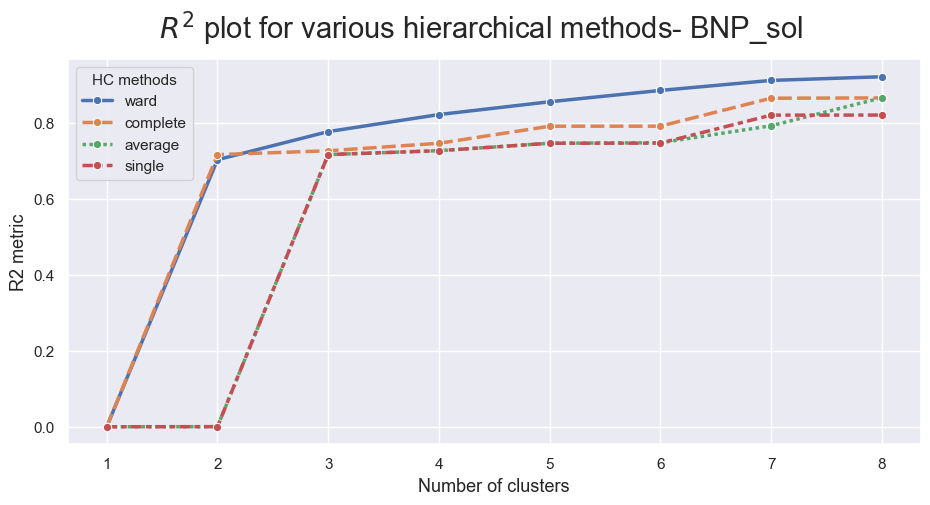

In [117]:
r2_hc_methods_sol = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods_sol)

sns.set()

# plot data
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods_sol, linewidth=2.5, markers=["o"]*4)

# finalize the plot
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R2 metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods- BNP_sol", fontsize=21)

plt.show()

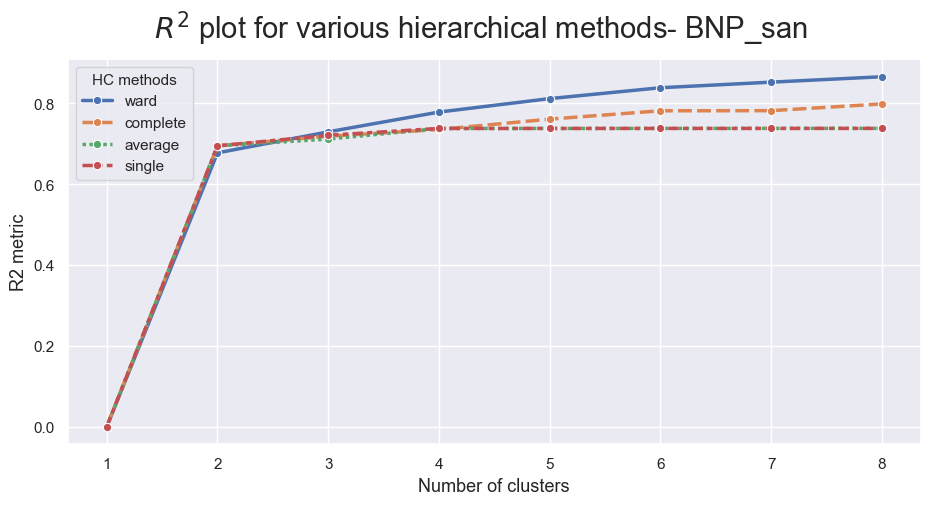

In [30]:
r2_hc_methods_san = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods_san)

sns.set()

# plot data
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods_san, linewidth=2.5, markers=["o"]*4)

# finalize the plot
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R2 metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods- BNP_san", fontsize=21)

plt.show()

In [245]:
#settig the best method
linkage_matrix_sol= linkage(financial_data_sol, method="ward")

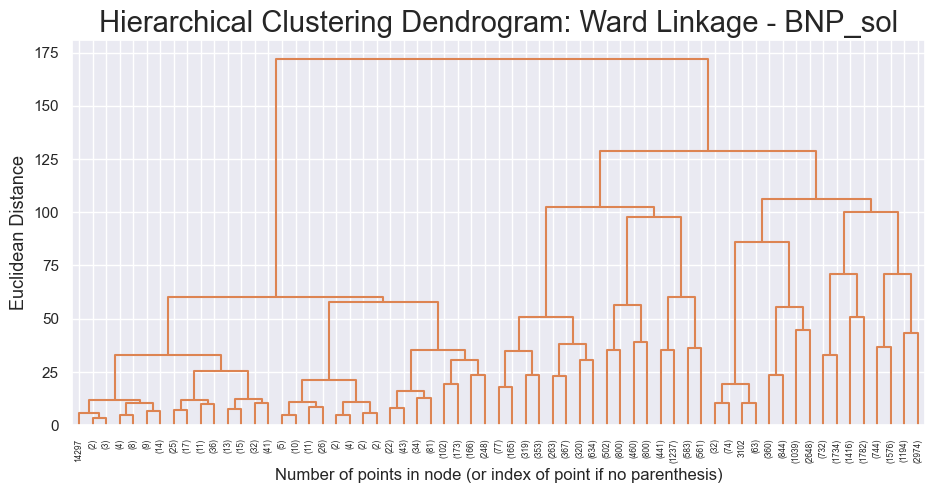

In [246]:
# plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
Y_THRESHOLD = 200
dendrogram(linkage_matrix_sol, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')

plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage - BNP_sol', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Euclidean Distance', fontsize=13)
plt.show()

In [247]:
# 2 clusters

n_clusters = 2

hc2_clust_sol = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc2_labels_sol = hc2_clust_sol.fit_predict(financial_data_sol)

df_concat_2_sol = pd.concat([financial_data_sol, 
                       pd.Series(hc2_labels_sol, 
                                 name='labels', 
                                 index=financial_data_sol.index)], 
                    axis=1)

df_concat_2_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.084266,-0.157806,0.485292,0.070133,0.177360,0.120896,0.036528,0.063844
1,1.324727,-0.284855,0.508321,3.472461,0.634268,0.205374,0.032476,0.108338


In [248]:
# 3 clusters

n_clusters = 3

hc3_clust_sol = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc3_labels_sol = hc3_clust_sol.fit_predict(financial_data_sol)

df_concat_3_sol = pd.concat([financial_data_sol, 
                       pd.Series(hc3_labels_sol, 
                                 name='labels', 
                                 index=financial_data_sol.index)], 
                    axis=1)

df_concat_3_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,-0.091704,-0.096535,0.450085,-0.221519,0.005690,0.129133,0.034664,0.092930
1,1.324727,-0.284855,0.508321,3.472461,0.634268,0.205374,0.032476,0.108338
2,0.468557,-0.291612,0.562179,0.707054,0.552262,0.102908,0.040600,0.000324


In [168]:
# 4 clusters

n_clusters = 4

hc4_clust_sol = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc4_labels_sol = hc4_clust_sol.fit_predict(financial_data_sol)

df_concat_4_sol = pd.concat([financial_data_sol, 
                       pd.Series(hc4_labels_sol, 
                                 name='labels', 
                                 index=financial_data_sol.index)], 
                    axis=1)

df_concat_4_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,RESSO,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,,
0,0.134351,-0.162261,0.189565,0.491662,0.211348,0.199894,0.123661,0.037111,0.042540
1,0.279429,-0.196968,5.073844,0.332227,0.492571,0.130945,0.153179,0.014331,0.738159
2,0.166667,-0.305556,197.065870,0.000000,0.000000,0.000000,0.000000,0.000000,1.444444
3,-0.500000,-0.305556,923.613542,0.000000,0.000000,0.000000,0.000000,0.000000,1.055556


In [256]:
#checking the mumber of observations in each cluster
pd.crosstab(
    pd.Series(hc2_labels_sol, name='hc2_labels_sol', index=financial_data_sol.index),
    pd.Series(hc3_labels_sol, name='hc3_labels_sol', index=financial_data_sol.index),
    )

hc3_labels_sol,0,1,2
hc2_labels_sol,,,
0,17213,0,7882
1,0,1162,0


In [257]:
pd.crosstab(
    pd.Series(hc3_labels_sol, name='hc2_labels_sol', index=financial_data_sol.index),
    pd.Series(hc4_labels_sol, name='hc3_labels_sol', index=financial_data_sol.index),
    )

hc3_labels_sol,0,1,2,3
hc2_labels_sol,,,,
0,16697,514,1,1
1,1067,95,0,0
2,7616,266,0,0


In [258]:
BNP_sol['hc3_labels_sol'] = hc3_labels_sol
BNP_san['hc3_labels_san'] = hc3_labels_san

In [ ]:
r2_sol = get_rsq(BNP_sol, financial_features, 'hc3_labels_sol')

NameError: name 'get_ss' is not defined

In [249]:
#settig the best method
linkage_matrix_san= linkage(financial_data_san, method="ward")

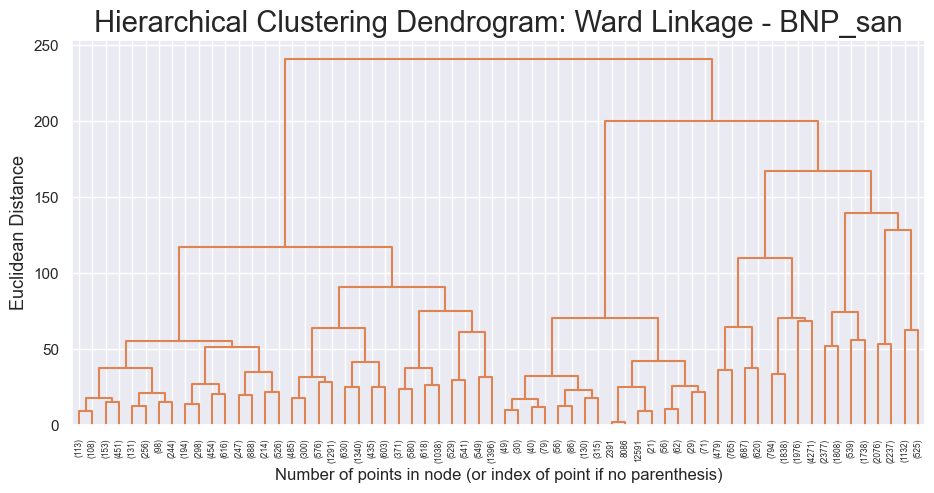

In [250]:
# plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
Y_THRESHOLD = 300
dendrogram(linkage_matrix_san, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')

plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage - BNP_san', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Euclidean Distance', fontsize=13)
plt.show()

In [251]:
# 2 clusters

n_clusters = 2

hc2_clust_san = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc2_labels_san = hc2_clust_san.fit_predict(financial_data_san)

df_concat_2_san = pd.concat([financial_data_san, 
                       pd.Series(hc2_labels_san, 
                                 name='labels', 
                                 index=financial_data_san.index)], 
                    axis=1)

df_concat_2_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.431184,-0.091549,0.572926,1.265298,0.409696,0.294126,0.032460,0.049447
1,-0.048170,-0.629832,0.437568,-0.197075,0.103086,-0.133353,0.040877,0.016865


In [252]:
# 2 clusters

n_clusters = 3

hc3_clust_san = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc3_labels_san = hc3_clust_san.fit_predict(financial_data_san)

df_concat_3_san = pd.concat([financial_data_san, 
                       pd.Series(hc3_labels_san, 
                                 name='labels', 
                                 index=financial_data_san.index)], 
                    axis=1)

df_concat_3_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.423031,-0.081527,0.575833,1.080085,0.407617,0.304716,0.032883,0.045485
1,-0.048170,-0.629832,0.437568,-0.197075,0.103086,-0.133353,0.040877,0.016865
2,0.620618,-0.324409,0.505383,5.568647,0.458003,0.048076,0.022620,0.141492


In [253]:
# 4 clusters

n_clusters = 4

hc4_clust_san = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc4_labels_san = hc4_clust_san.fit_predict(financial_data_san)

df_concat_4_san = pd.concat([financial_data_san, 
                       pd.Series(hc4_labels_san, 
                                 name='labels', 
                                 index=financial_data_san.index)], 
                    axis=1)

df_concat_4_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.558468,0.211071,0.582050,0.502252,0.600905,0.558362,0.034713,0.041988
1,-0.048170,-0.629832,0.437568,-0.197075,0.103086,-0.133353,0.040877,0.016865
2,0.620618,-0.324409,0.505383,5.568647,0.458003,0.048076,0.022620,0.141492
3,0.275722,-0.399775,0.569072,1.708574,0.197384,0.028835,0.030893,0.049289


In [254]:
#checking the mumber of observations in each cluster
pd.crosstab(
    pd.Series(hc2_labels_san, name='hc2_labels_san', index=financial_data_san.index),
    pd.Series(hc3_labels_san, name='hc3_labels_san', index=financial_data_san.index),
    )

hc3_labels_san,0,1,2
hc2_labels_san,,,
0,23862,0,1027
1,0,16273,0


In [255]:
pd.crosstab(
    pd.Series(hc3_labels_san, name='hc3_labels_san', index=financial_data_san.index),
    pd.Series(hc4_labels_san, name='hc4_labels_san', index=financial_data_san.index),
    )

hc4_labels_san,0,1,2,3
hc3_labels_san,,,,
0,12432,0,0,11430
1,0,16273,0,0
2,0,0,1027,0


<a class="anchor" id="4.1.2 K-means">

### 4.1.2 K-means
</a>

In [333]:
# initial clustering
kmclust_sol = KMeans(n_clusters=4, init='k-means++', n_init=15, random_state=1)
kmclust_sol.fit_predict(financial_data_sol)

array([1, 2, 1, ..., 0, 0, 1], dtype=int32)

In [334]:
# initial clustering
kmclust_san = KMeans(n_clusters=4, init='k-means++', n_init=15, random_state=1)
kmclust_san.fit_predict(financial_data_san)

array([1, 1, 3, ..., 3, 3, 1], dtype=int32)

In [335]:
range_clusters_sol = range(1, 9)

inertia = []
for n_clus in range_clusters_sol:  # iterate over desired ncluster range
    kmclust_sol = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust_sol.fit(financial_data_sol)
    inertia.append(kmclust_sol.inertia_) 

In [336]:
range_clusters_san = range(1, 9)

inertia = []
for n_clus in range_clusters_san:  # iterate over desired ncluster range
    kmclust_san = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust_san.fit(financial_data_san)
    inertia.append(kmclust_san.inertia_) 

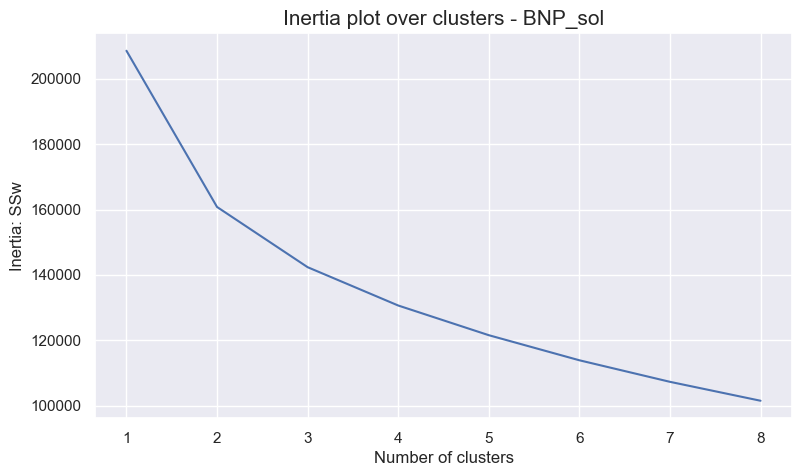

In [337]:
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters_sol, inertia)
ax.set_xticks(range_clusters_sol)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters - BNP_sol", size=15)

plt.show()

In [338]:
avg_silhouette_sol = []

for nclus in range_clusters_sol:
    if nclus == 1:
        continue

    kmclust_sol = KMeans(
        n_clusters=nclus,
        init='k-means++',
        n_init=15,
        random_state=1
    )

    cluster_labels_sol = kmclust_sol.fit_predict(financial_data_sol)

    silhouette_avg_sol = silhouette_score(financial_data_sol, cluster_labels_sol)
    avg_silhouette_sol.append(silhouette_avg_sol)

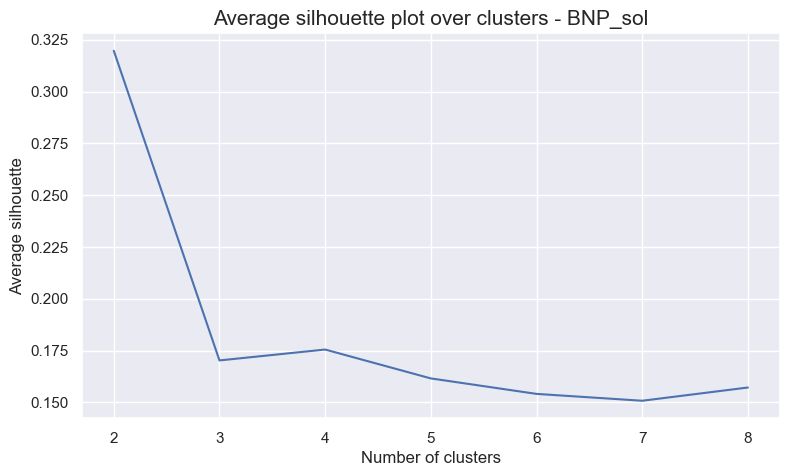

In [339]:
# average silhouette plot
# inertia plot
plt.figure(figsize=(9,5))

plt.plot(range_clusters_sol[1:],
         avg_silhouette_sol)

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters - BNP_sol", size=15)
plt.show()

In [340]:
# 2 clusters
number_clusters = 2
kmclust2_sol = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels2_sol = kmclust2_sol.fit_predict(financial_data_sol)
km_labels2_sol

array([1, 1, 1, ..., 0, 0, 1], dtype=int32)

In [341]:
df_concat_km2_sol = pd.concat((financial_data_sol, pd.Series(km_labels2_sol, name='labels', index=financial_data_sol.index)), axis=1)
df_concat_km2_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.908671,-0.220879,0.542544,2.060993,0.511909,0.234997,0.036547,0.000670
1,-0.005209,-0.152650,0.475761,-0.124565,0.138608,0.103929,0.036312,0.078035


In [342]:
# 3 clusters
number_clusters = 3
kmclust3_sol = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels3_sol = kmclust3_sol.fit_predict(financial_data_sol)
km_labels3_sol

array([2, 1, 2, ..., 0, 0, 2], dtype=int32)

In [343]:
df_concat_km3_sol = pd.concat((financial_data_sol, pd.Series(km_labels3_sol, name='labels', index=financial_data_sol.index)), axis=1)
df_concat_km3_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.880847,-0.243274,0.536800,2.531676,0.511803,0.196827,0.036246,-0.003387
1,0.150097,0.342761,0.518087,-0.063332,0.169652,0.665597,0.025044,0.312820
2,-0.046921,-0.594343,0.446063,-0.076375,0.147685,-0.373338,0.046421,-0.137271


In [344]:
# 3 clusters
number_clusters = 4
kmclust4_sol = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels4_sol = kmclust4_sol.fit_predict(financial_data_sol)
km_labels4_sol

array([1, 2, 1, ..., 0, 0, 1], dtype=int32)

In [345]:
df_concat_km4_sol = pd.concat((financial_data_sol, pd.Series(km_labels4_sol, name='labels', index=financial_data_sol.index)), axis=1)
df_concat_km4_sol.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,1.593329,-0.174681,0.475551,0.202730,0.293409,0.226660,0.033321,0.258705
1,-0.165415,-0.600106,0.442523,-0.081372,0.140866,-0.397265,0.047608,-0.160130
2,-0.126979,0.369625,0.528995,-0.083174,0.161407,0.683741,0.024009,0.279588
3,0.500000,-0.223287,0.536822,2.852273,0.465390,0.193942,0.037152,-0.007950


In [346]:
#checking the mumber of observations in 2- cluster and 3-cluster solutions
pd.crosstab(
    pd.Series(km_labels2_sol, name='km_labels2_sol', index=financial_data_sol.index),
    pd.Series(km_labels4_sol, name='km_labels4_sol', index=financial_data_sol.index),
    )

km_labels4_sol,0,1,2,3
km_labels2_sol,,,,
0,1210,286,276,2376
1,2233,10762,9114,0


In [347]:
#checking the mumber of observations in 2- cluster and 3-cluster solutions
pd.crosstab(
    pd.Series(km_labels2_sol, name='km_labels2_sol', index=financial_data_sol.index),
    pd.Series(km_labels3_sol, name='km_labels3_sol', index=financial_data_sol.index),
    )

km_labels3_sol,0,1,2
km_labels2_sol,,,
0,2936,693,519
1,0,10281,11828


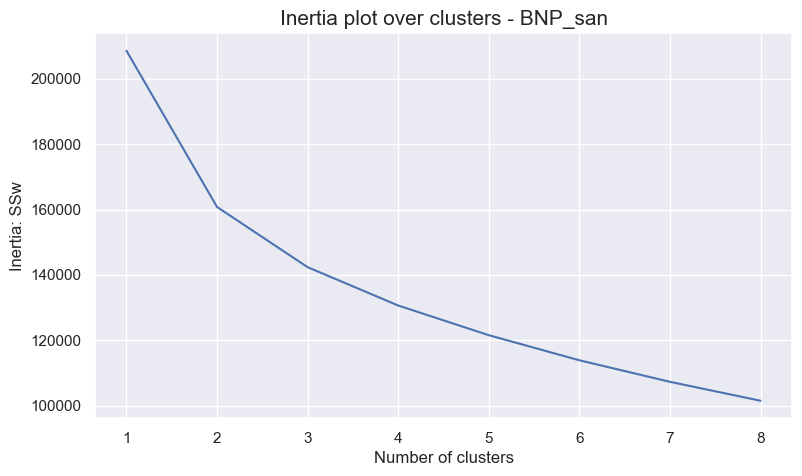

In [348]:
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters_san, inertia)
ax.set_xticks(range_clusters_san)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters - BNP_san", size=15)

plt.show()

In [349]:
avg_silhouette_san = []

for nclus in range_clusters_san:
    if nclus == 1:
        continue

    kmclust_san = KMeans(
        n_clusters=nclus,
        init='k-means++',
        n_init=15,
        random_state=1
    )

    cluster_labels_san = kmclust_san.fit_predict(financial_data_san)

    silhouette_avg = silhouette_score(financial_data_san, cluster_labels_san)
    avg_silhouette_san.append(silhouette_avg)

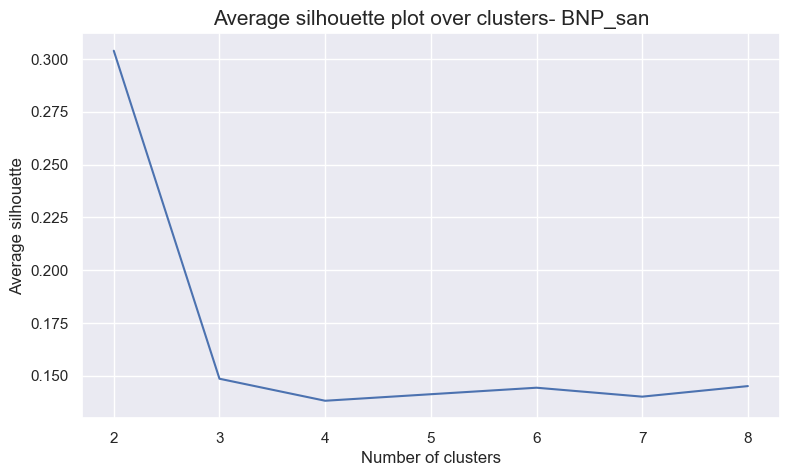

In [350]:
# average silhouette plot
# inertia plot
plt.figure(figsize=(9,5))

plt.plot(range_clusters_san[1:],
         avg_silhouette_san)

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters- BNP_san", size=15)
plt.show()

In [351]:
# 2 clusters
number_clusters = 2
kmclust2_san = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels2_san = kmclust2_san.fit_predict(financial_data_san)
km_labels2_san

array([0, 0, 1, ..., 0, 0, 0], dtype=int32)

In [352]:
df_concat_km2_san = pd.concat((financial_data_san, pd.Series(km_labels2_san, name='labels', index=financial_data_san.index)), axis=1)
df_concat_km2_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.134568,-0.323096,0.516153,0.163983,0.238134,0.12071,0.037539,0.020185
1,0.672945,-0.228889,0.532542,2.793748,0.491201,0.14291,0.028735,0.102523


In [353]:
# 3 clusters
number_clusters = 3
kmclust3_san = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels3_san = kmclust3_san.fit_predict(financial_data_san)
km_labels3_san

array([2, 1, 0, ..., 1, 1, 1], dtype=int32)

In [354]:
df_concat_km3_san = pd.concat((financial_data_san, pd.Series(km_labels3_san, name='labels', index=financial_data_san.index)), axis=1)
df_concat_km3_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,0.634847,-0.218450,0.535367,2.852518,0.486142,0.141507,0.028271,0.111608
1,0.421378,0.177923,0.556623,0.225523,0.273249,0.581791,0.030216,0.252166
2,-0.107298,-0.797772,0.477081,0.131884,0.212454,-0.312387,0.044471,-0.200766


In [355]:
# 3 clusters
number_clusters = 4
kmclust4_san = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels4_san = kmclust4_san.fit_predict(financial_data_san)
km_labels4_san

array([1, 1, 3, ..., 3, 3, 1], dtype=int32)

In [356]:
df_concat_km4_san = pd.concat((financial_data_san, pd.Series(km_labels4_san, name='labels', index=financial_data_san.index)), axis=1)
df_concat_km4_san.groupby('labels').mean()

,ALLBD_N_events__N,DURDEG,NBEN_log,count_cl,montenc_total_log,RANGCLI,ks_score_tier_log,sdem_age
labels,,,,,,,,
0,-0.144670,-0.922854,0.461670,0.000223,0.181308,-0.342269,0.046425,-0.217747
1,0.162774,0.238905,0.574081,-0.101379,0.171447,0.656943,0.031774,0.216459
2,0.763447,-0.214107,0.543089,3.925703,0.558993,0.160047,0.026568,0.136976
3,0.608386,-0.193601,0.521182,1.333923,0.452051,0.092712,0.030601,0.108660


In [357]:
#checking the mumber of observations in 2- cluster and 3-cluster solutions
pd.crosstab(
    pd.Series(km_labels4_san, name='km_labels4_san', index=financial_data_san.index),
    pd.Series(km_labels3_san, name='km_labels3_san', index=financial_data_san.index),
    )

km_labels3_san,0,1,2
km_labels4_san,,,
0,0,104,13362
1,0,11186,1144
2,3486,0,0
3,4359,4868,2653


In [358]:
#checking the mumber of observations in 2- cluster and 3-cluster solutions
pd.crosstab(
    pd.Series(km_labels2_san, name='km_labels2_san', index=financial_data_san.index),
    pd.Series(km_labels3_san, name='km_labels3_san', index=financial_data_san.index),
    )

km_labels3_san,0,1,2
km_labels2_san,,,
0,1,15949,17023
1,7844,209,136


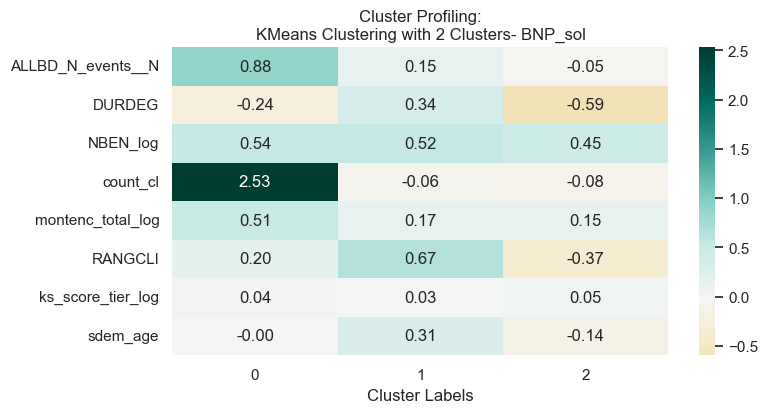

In [359]:
#visualization of averages for 2 clusters
fig, ax = plt.subplots(figsize=(8,4))

km_profile3_sol = df_concat_km3_sol.groupby('labels').mean().T

sns.heatmap(km_profile3_sol,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 2 Clusters- BNP_sol")
plt.show()

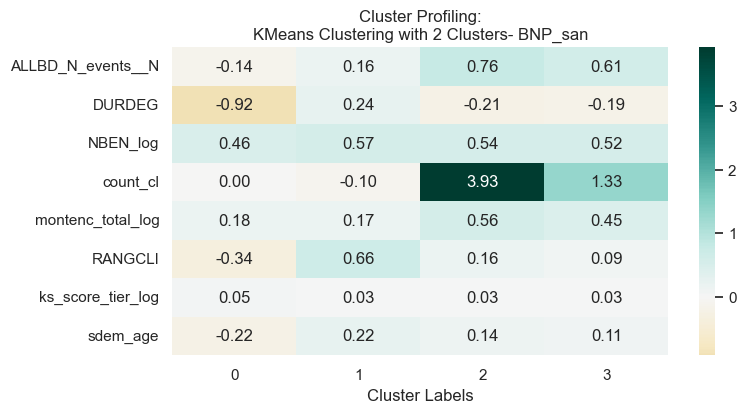

In [360]:
#visualization of averages for 2 clusters
fig, ax = plt.subplots(figsize=(8,4))

km_profile4_san = df_concat_km4_san.groupby('labels').mean().T

sns.heatmap(km_profile4_san,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 2 Clusters- BNP_san")
plt.show()

In [366]:
BNP_sol['km_labels3_sol'] = km_labels3_sol
BNP_san['km_labels4_san'] = km_labels4_san
r2_sol = get_rsq(BNP_sol, financial_features, 'km_labels3_sol')
r2_san = get_rsq(BNP_san, financial_features, 'km_labels4_san')
r2_san

np.float64(0.3737023880314876)

<a class="anchor" id="4.2 Perspective 2">

## 4.2 Perspective 2 - Risk
    
</a>

<a class="anchor" id="4.2.1 hierarchical clustering">

### 4.2.1 Hierarchical clustering
    
</a>

In [ ]:
hclust_sol = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=3)
hc_labels_sol = hclust_sol.fit_predict(risk_data_sol)
hc_labels_sol

array([0, 0, 0, ..., 1, 0, 0])

In [70]:
hclust_san = AgglomerativeClustering(linkage='ward', metric='euclidean', n_clusters=3)
hc_labels_san = hclust_san.fit_predict(risk_data_san)
hc_labels_san

array([2, 1, 1, ..., 1, 1, 1])

In [71]:
# characterizing the clusters

labels_series_sol = pd.Series(hc_labels_sol, 
                          name='labels', 
                          index=risk_data_sol.index 
                          ) 

df_concat_sol = pd.concat(
    [risk_data_sol, labels_series_sol],
    axis=1)

df_concat_sol

,ks_score_tier,RANGCLI_log,dividas_total_mean_log,montenc_total_log,montabatv_total_log,labels
CONTRIB,,,,,,
0000c74654405ec1da4dbdcd00b86e397954043965d98e542d19fa4808c6b65a,0.0,0.560093,0.910037,0.000000,0.0,0
000406feeb8088e3b05f47bc89160d25ca14f11c31f91bc6516a4e6753e58d73,0.0,0.585910,0.910037,0.000000,0.0,0
000508d6436a34b780df1aa8068568f1b118f5d589ddc7bb33662295defff2aa,0.0,0.461860,0.796827,0.000000,0.0,0
000607d1adce7aa9ac87274d1a2ffa84e240188de0872fc2cc3dc05d70d63560,0.0,0.746843,0.935520,0.000000,0.0,0
00074b200f6c11a8731d6da396546e8d2e7be5621c931b9a039789b1a92f86e6,0.0,0.650294,0.933847,0.000000,0.0,0
...,...,...,...,...,...,...
fff9e4e8b1bcd50dfef2953c7b7ce0db2bd4e235b4892b01c149bfd4827fdbd1,0.0,0.775820,0.886087,0.000000,0.0,0
fffa36f944396a3e75f9c54900165502a3eb725962144bd97f6af33e8ba6fac2,0.0,0.660467,0.762153,0.000000,0.0,0
fffbc66ca4256976c9932916770f1ff3b23aacce5998ffc7d570a73378d619df,0.0,0.780096,0.844279,0.636299,0.0,1


In [72]:
# characterizing the clusters

labels_series_san = pd.Series(hc_labels_san, 
                          name='labels', 
                          index=risk_data_san.index 
                          ) 

df_concat_san = pd.concat(
    [risk_data_san, labels_series_san],
    axis=1)

df_concat_san

,ks_score_tier,RANGCLI_log,dividas_total_mean_log,montenc_total_log,montabatv_total_log,labels
CONTRIB,,,,,,
00008246f87bcc3c17b90629bb183fe2e58795176310f017217d7749af7ee981,0.25,0.718371,0.890859,0.0,0.0,2
0000e359b15a80ba12c7f60c0fe06ffc68621c87f13a4f88f54188543d9a09c8,0.00,0.786346,0.905829,0.0,0.0,1
0005f134494d2ab97ed5d4164994dcde766a3f77cdb3a915e0cf605c564e7aa5,0.00,0.838185,0.934857,0.0,0.0,1
000803da8192598bfa2bbd780df6da11b3fe54ff3327487821f060bd3de69e76,0.00,0.704513,0.964618,0.0,0.0,1
000a129438776dca90f4359642f343cb037d9afe60897fd1676ac48cd21d2046,0.00,0.799936,0.900508,0.0,0.0,1
...,...,...,...,...,...,...
fffbfb06fdb05fb48a739b0a23650122a66ff61669a5b3e34d22144d0f0c2049,0.00,0.825439,0.922124,0.0,0.0,1
fffc5ec9541c7691c7759c637317530910cf44783e4209f205e28474646bad6a,0.00,0.798521,0.952987,0.0,0.0,1
fffc6e5b2f4865ed2d2c6c8724f9c4c340e47d2b052bc67dc5b24a0b5f3260e7,0.00,0.847667,0.919307,0.0,0.0,1


In [73]:
df_sst_sol = get_ss(df_concat_sol, risk_features)
df_ssb_sol = get_ssb(df_concat_sol, risk_features, 'labels')
df_ssw_sol = get_ssw(df_concat_sol, risk_features, 'labels')

print("SSb:  ", df_ssb_sol)
print("SSw:  ", df_ssw_sol)
print("SSt:  ", df_sst_sol)
print("SSt == SSb+SSw ? ", (round(df_sst_sol) == round(df_ssb_sol+ df_ssw_sol)))

SSb:   1385.7778783904928
SSw:   818.224432511601
SSt:   2204.0023109018703
SSt == SSb+SSw ?  True


In [74]:
df_sst_san = get_ss(df_concat_san, risk_features)
df_ssb_san = get_ssb(df_concat_san, risk_features, 'labels')
df_ssw_san = get_ssw(df_concat_san, risk_features, 'labels')

print("SSb:  ", df_ssb_san)
print("SSw:  ", df_ssw_san)
print("SSt:  ", df_sst_san)
print("SSt == SSb+SSw ? ", (round(df_sst_san) == round(df_ssb_san+ df_ssw_san)))

SSb:   2588.300512946555
SSw:   1328.82281638893
SSt:   3917.1233293356477
SSt == SSb+SSw ?  True


In [75]:
hc_methods_sol = ["ward", "complete", "average", "single"]
max_nclus = 8

results = []
for link in hc_methods_sol:
    r2 = get_r2_hc(
        df=risk_data_sol, 
        link_method=link, 
        max_nclus=max_nclus, 
        min_nclus=1, 
        dist="euclidean")
    results.append(r2)

r2_hc = np.vstack(results)

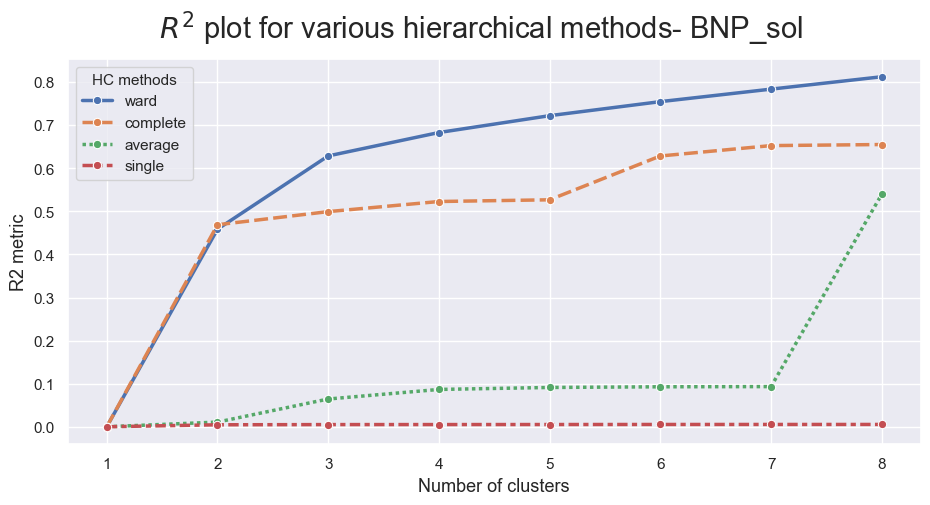

In [76]:
r2_hc_methods_sol = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods_sol)

sns.set()

# plot data
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods_sol, linewidth=2.5, markers=["o"]*4)

# finalize the plot
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R2 metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods- BNP_sol", fontsize=21)

plt.show()

In [77]:
hc_methods_san = ["ward", "complete", "average", "single"]
max_nclus = 8

results = []
for link in hc_methods_san:
    r2 = get_r2_hc(
        df=risk_data_san, 
        link_method=link, 
        max_nclus=max_nclus, 
        min_nclus=1, 
        dist="euclidean")
    results.append(r2)

r2_hc = np.vstack(results)

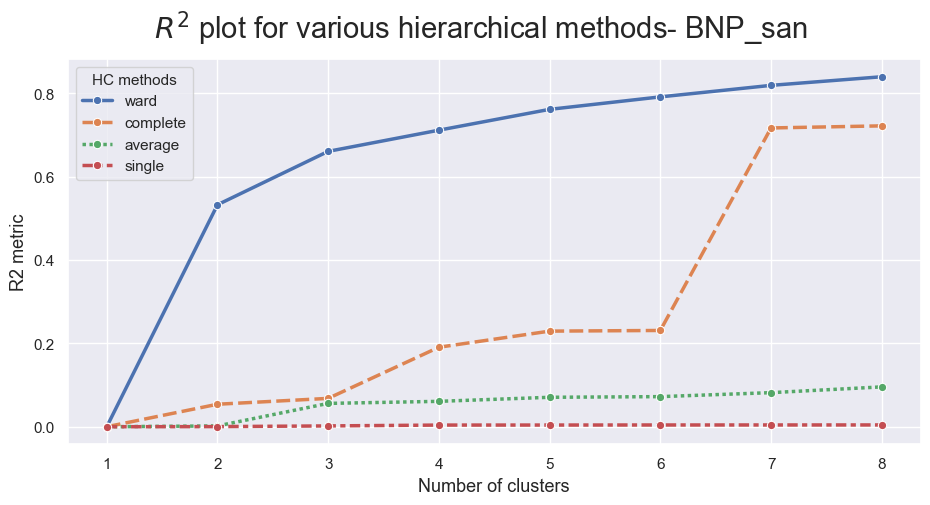

In [78]:
r2_hc_methods_san = pd.DataFrame(r2_hc.T, index=range(1, max_nclus + 1), columns=hc_methods_san)

sns.set()

# plot data
fig = plt.figure(figsize=(11,5))
sns.lineplot(data=r2_hc_methods_san, linewidth=2.5, markers=["o"]*4)

# finalize the plot
plt.legend(title="HC methods", title_fontsize=11)
plt.xticks(range(1, max_nclus + 1))
plt.xlabel("Number of clusters", fontsize=13)
plt.ylabel("R2 metric", fontsize=13)

fig.suptitle("$R^2$ plot for various hierarchical methods- BNP_san", fontsize=21)

plt.show()

In [41]:
#settig the best method
linkage_matrix_sol= linkage(risk_data_sol, method="ward")

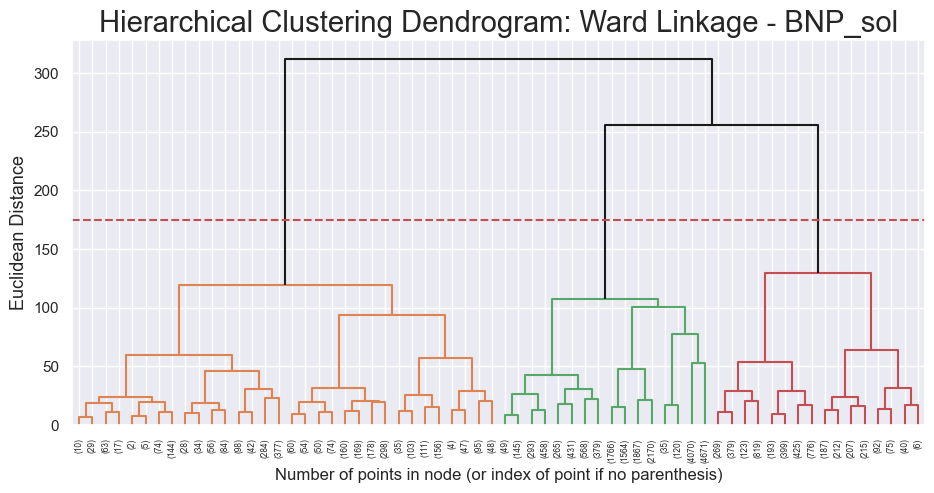

In [43]:
# plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
Y_THRESHOLD = 175
dendrogram(linkage_matrix_sol, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')

plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage - BNP_sol', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Euclidean Distance', fontsize=13)
plt.show()

In [86]:
BNP_sol['montenc_total'].value_counts()

montenc_total
0.000000       22628
0.600000          40
1.200000           7
1.000000           7
1.600000           6
               ...  
114.330000         1
1935.340714        1
2.601200           1
15.384800          1
48.373846          1
Name: count, Length: 3514, dtype: int64

In [44]:
# 2 clusters

n_clusters = 2

hc2_clust_sol = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc2_labels_sol = hc2_clust_sol.fit_predict(risk_data_sol)

df_concat_2_sol = pd.concat([risk_data_sol, 
                       pd.Series(hc2_labels_sol, 
                                 name='labels', 
                                 index=risk_data_sol.index)], 
                    axis=1)

df_concat_2_sol.groupby('labels').mean()

,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log
labels,,,,
0,0.188413,0.117081,0.242819,0.026263
1,0.313817,0.183440,0.514796,4.307549


In [45]:
# 3 clusters

n_clusters = 3

hc3_clust_sol = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc3_labels_sol = hc3_clust_sol.fit_predict(risk_data_sol)

df_concat_3_sol = pd.concat([risk_data_sol, 
                       pd.Series(hc3_labels_sol, 
                                 name='labels', 
                                 index=risk_data_sol.index)], 
                    axis=1)

df_concat_3_sol.groupby('labels').mean()

,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log
labels,,,,
0,0.044148,0.214847,2.682268,0.029291
1,0.313817,0.183440,0.514796,4.307549
2,0.222216,0.094173,-0.328771,0.025554


In [46]:
#checking the mumber of observations in each cluster
pd.crosstab(
    pd.Series(hc2_labels_sol, name='hc2_labels_sol', index=risk_data_sol.index),
    pd.Series(hc3_labels_sol, name='hc3_labels_sol', index=risk_data_sol.index),
    )

hc3_labels_sol,0,1,2
hc2_labels_sol,,,
0,4417,0,18851
1,0,2989,0


In [47]:
#settig the best method
linkage_matrix_san= linkage(risk_data_san, method="ward")

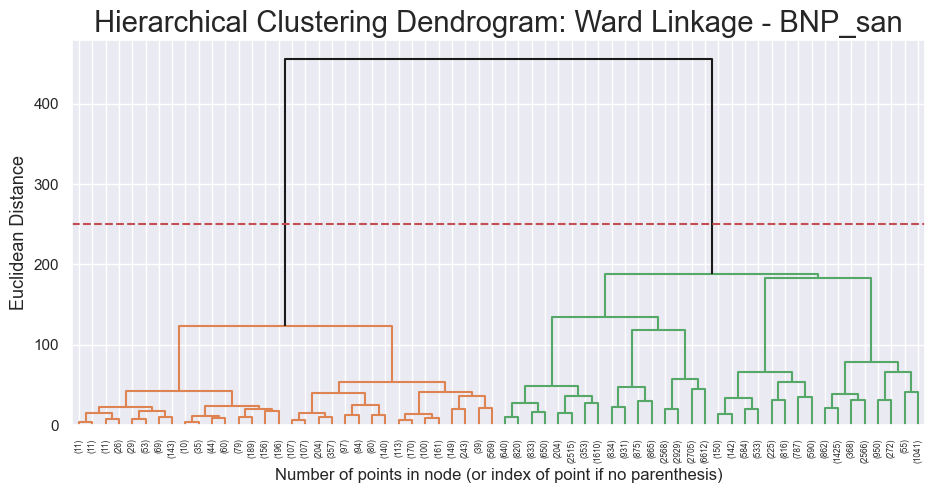

In [49]:
# plot the corresponding dendrogram
sns.set()
fig = plt.figure(figsize=(11,5))
Y_THRESHOLD = 250
dendrogram(linkage_matrix_san, truncate_mode='level', p=5, color_threshold=Y_THRESHOLD, above_threshold_color='k')

plt.hlines(Y_THRESHOLD, 0, 1000, colors="r", linestyles="dashed")
plt.title(f'Hierarchical Clustering Dendrogram: Ward Linkage - BNP_san', fontsize=21)
plt.xlabel('Number of points in node (or index of point if no parenthesis)')
plt.ylabel(f'Euclidean Distance', fontsize=13)
plt.show()

In [50]:
# 2 clusters

n_clusters = 2

hc2_clust_san = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc2_labels_san = hc2_clust_san.fit_predict(risk_data_san)

df_concat_2_san = pd.concat([risk_data_san, 
                       pd.Series(hc2_labels_san, 
                                 name='labels', 
                                 index=risk_data_san.index)], 
                    axis=1)

df_concat_2_san.groupby('labels').mean()

,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log
labels,,,,
0,0.182632,0.128826,0.375594,0.244100
1,0.300104,0.089289,0.312050,5.700128


In [53]:
# 3 clusters

n_clusters = 3

hc3_clust_san = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc3_labels_san = hc3_clust_san.fit_predict(risk_data_san)

df_concat_3_san = pd.concat([risk_data_san, 
                       pd.Series(hc3_labels_san, 
                                 name='labels', 
                                 index=risk_data_san.index)], 
                    axis=1)

df_concat_3_san.groupby('labels').mean()

,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log
labels,,,,
0,0.082879,0.097567,1.262115,0.776480
1,0.300104,0.089289,0.312050,5.700128
2,0.226334,0.142521,-0.012788,0.010865


In [51]:
# 3 clusters

n_clusters = 4

hc4_clust_san = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
hc4_labels_san = hc4_clust_san.fit_predict(risk_data_san)

df_concat_4_san = pd.concat([risk_data_san, 
                       pd.Series(hc4_labels_san, 
                                 name='labels', 
                                 index=risk_data_san.index)], 
                    axis=1)

df_concat_4_san.groupby('labels').mean()

,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log
labels,,,,
0,0.226334,0.142521,-0.012788,0.010865
1,0.300104,0.089289,0.312050,5.700128
2,0.061547,0.139623,1.679360,0.018411
3,0.124902,0.014721,0.440163,2.269840


In [54]:
#checking the mumber of observations in each cluster
pd.crosstab(
    pd.Series(hc2_labels_san, name='hc2_labels_san', index=risk_data_san.index),
    pd.Series(hc3_labels_san, name='hc3_labels_san', index=risk_data_san.index),
    )

hc3_labels_san,0,1,2
hc2_labels_san,,,
0,11366,0,25944
1,0,3852,0


In [55]:
#checking the mumber of observations in each cluster
pd.crosstab(
    pd.Series(hc3_labels_san, name='hc3_labels_san', index=risk_data_san.index),
    pd.Series(hc4_labels_san, name='hc4_labels_san', index=risk_data_san.index),
    )

hc4_labels_san,0,1,2,3
hc3_labels_san,,,,
0,0,0,7539,3827
1,0,3852,0,0
2,25944,0,0,0


<a class="anchor" id="4.2.2 kmeans">

### 4.2.2 K-means
    
</a>

In [ ]:
# initial clustering
kmclust_sol = KMeans(n_clusters=4, init='k-means++', n_init=15, random_state=1)
kmclust_sol.fit_predict(risk_data_sol)

In [ ]:
# initial clustering
kmclust_san = KMeans(n_clusters=4, init='k-means++', n_init=15, random_state=1)
kmclust_san.fit_predict(risk_data_san)

In [56]:
range_clusters_sol = range(1, 9)

inertia = []
for n_clus in range_clusters_sol:  # iterate over desired ncluster range
    kmclust_sol = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust_sol.fit(risk_data_sol)
    inertia.append(kmclust_sol.inertia_) 

c:\Users\nicol\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\nicol\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\nicol\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\nicol\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

In [57]:
range_clusters_san = range(1, 9)

inertia = []
for n_clus in range_clusters_san:  # iterate over desired ncluster range
    kmclust_san = KMeans(n_clusters=n_clus, init='k-means++', n_init=15, random_state=1)
    kmclust_san.fit(risk_data_san)
    inertia.append(kmclust_san.inertia_) 

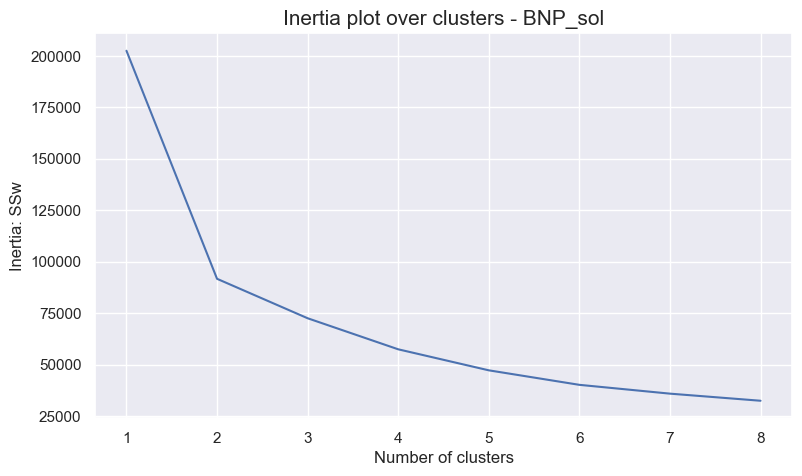

In [58]:
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters_sol, inertia)
ax.set_xticks(range_clusters_sol)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters - BNP_sol", size=15)

plt.show()

In [59]:
avg_silhouette_sol = []

for nclus in range_clusters_sol:
    if nclus == 1:
        continue

    kmclust_sol = KMeans(
        n_clusters=nclus,
        init='k-means++',
        n_init=15,
        random_state=1
    )

    cluster_labels_sol = kmclust_sol.fit_predict(risk_data_sol)

    silhouette_avg_sol = silhouette_score(risk_data_sol, cluster_labels_sol)
    avg_silhouette_sol.append(silhouette_avg_sol)

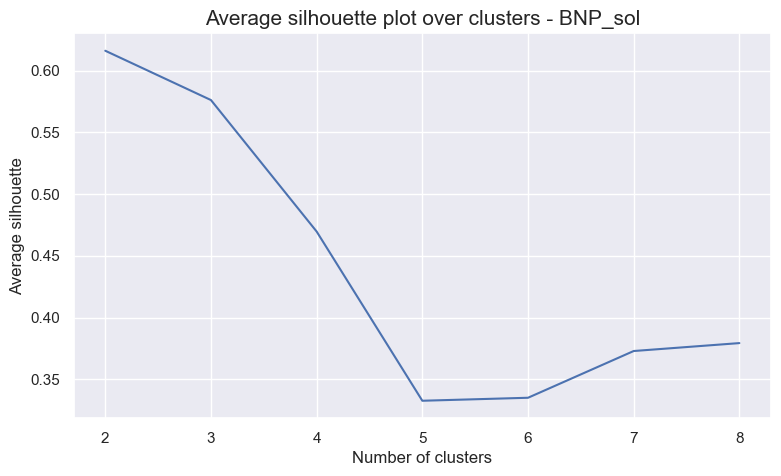

In [60]:
# average silhouette plot
# inertia plot
plt.figure(figsize=(9,5))

plt.plot(range_clusters_sol[1:],
         avg_silhouette_sol)

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters - BNP_sol", size=15)
plt.show()

In [61]:
# 2 clusters
number_clusters = 2
kmclust2_sol = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels2_sol = kmclust2_sol.fit_predict(risk_data_sol)
km_labels2_sol

array([0, 0, 0, ..., 1, 0, 0], dtype=int32)

In [62]:
df_concat_km2_sol = pd.concat((risk_data_sol, pd.Series(km_labels2_sol, name='labels', index=risk_data_sol.index)), axis=1)
df_concat_km2_sol.groupby('labels').mean()

,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log
labels,,,,
0,0.192564,0.116042,0.248189,0.070942
1,0.302143,0.209042,0.525159,4.862218


In [63]:
# 3 clusters
number_clusters = 3
kmclust3_sol = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels3_sol = kmclust3_sol.fit_predict(risk_data_sol)
km_labels3_sol

array([2, 2, 2, ..., 0, 2, 2], dtype=int32)

In [64]:
df_concat_km3_sol = pd.concat((risk_data_sol, pd.Series(km_labels3_sol, name='labels', index=risk_data_sol.index)), axis=1)
df_concat_km3_sol.groupby('labels').mean()

,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log
labels,,,,
0,0.321043,0.209174,0.216085,5.015368
1,0.066550,0.199973,3.377645,0.243597
2,0.212549,0.102986,-0.236024,0.072675


In [65]:
#checking the mumber of observations in 2- cluster and 3-cluster solutions
pd.crosstab(
    pd.Series(km_labels2_sol, name='km_labels2_sol', index=financial_data_sol.index),
    pd.Series(km_labels3_sol, name='km_labels3_sol', index=financial_data_sol.index),
    )

km_labels3_sol,0,1,2
km_labels2_sol,,,
0,0,3251,20580
1,2224,175,27


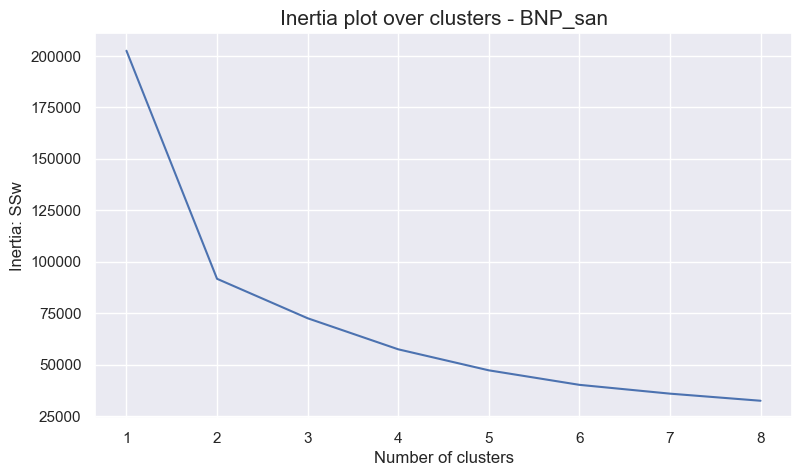

In [66]:
fig, ax = plt.subplots(figsize=(9,5))

ax.plot(range_clusters_san, inertia)
ax.set_xticks(range_clusters_san)
ax.set_ylabel("Inertia: SSw")
ax.set_xlabel("Number of clusters")
ax.set_title("Inertia plot over clusters - BNP_san", size=15)

plt.show()

In [67]:
avg_silhouette_san = []

for nclus in range_clusters_san:
    if nclus == 1:
        continue

    kmclust_san = KMeans(
        n_clusters=nclus,
        init='k-means++',
        n_init=15,
        random_state=1
    )

    cluster_labels_san = kmclust_san.fit_predict(risk_data_san)

    silhouette_avg = silhouette_score(risk_data_san, cluster_labels_san)
    avg_silhouette_san.append(silhouette_avg)

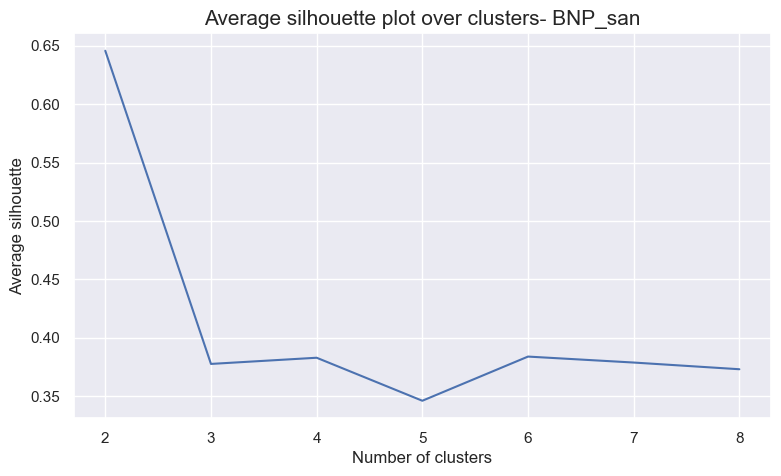

In [68]:
# average silhouette plot
# inertia plot
plt.figure(figsize=(9,5))

plt.plot(range_clusters_san[1:],
         avg_silhouette_san)

plt.ylabel("Average silhouette")
plt.xlabel("Number of clusters")
plt.title("Average silhouette plot over clusters- BNP_san", size=15)
plt.show()

In [69]:
# 2 clusters
number_clusters = 2
kmclust2_san = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels2_san = kmclust2_san.fit_predict(risk_data_san)
km_labels2_san

array([0, 0, 0, ..., 0, 0, 0], dtype=int32)

In [70]:
df_concat_km2_san = pd.concat((risk_data_san, pd.Series(km_labels2_san, name='labels', index=risk_data_san.index)), axis=1)
df_concat_km2_san.groupby('labels').mean()

,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log
labels,,,,
0,0.188170,0.131187,0.366814,0.115561
1,0.229578,0.085188,0.388322,4.966663


In [71]:
# 3 clusters
number_clusters = 3
kmclust3_san = KMeans(n_clusters=number_clusters, init='k-means++', n_init=15, random_state=1)
km_labels3_san = kmclust3_san.fit_predict(risk_data_san)
km_labels3_san

array([1, 1, 1, ..., 1, 1, 1], dtype=int32)

In [72]:
df_concat_km3_san = pd.concat((risk_data_san, pd.Series(km_labels3_san, name='labels', index=risk_data_san.index)), axis=1)
df_concat_km3_san.groupby('labels').mean()

,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log
labels,,,,
0,0.052507,0.167884,1.643041,0.147751
1,0.232577,0.118697,-0.048444,0.115768
2,0.231595,0.086333,0.365333,5.014124


In [73]:
pd.crosstab(
    pd.Series(km_labels2_san, name='km_labels2_san', index=risk_data_san.index),
    pd.Series(km_labels3_san, name='km_labels3_san', index=risk_data_san.index),
    )

km_labels3_san,0,1,2
km_labels2_san,,,
0,8802,26934,3
1,73,42,5308


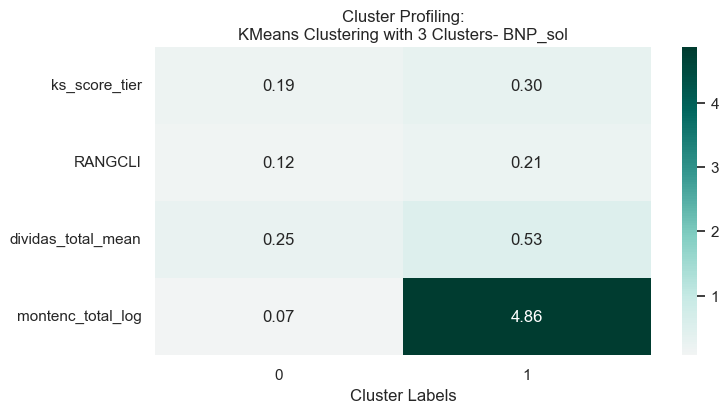

In [74]:
#visualization of averages for 2 clusters
fig, ax = plt.subplots(figsize=(8,4))

km_profile2_sol = df_concat_km2_sol.groupby('labels').mean().T

sns.heatmap(km_profile2_sol,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 3 Clusters- BNP_sol")
plt.show()

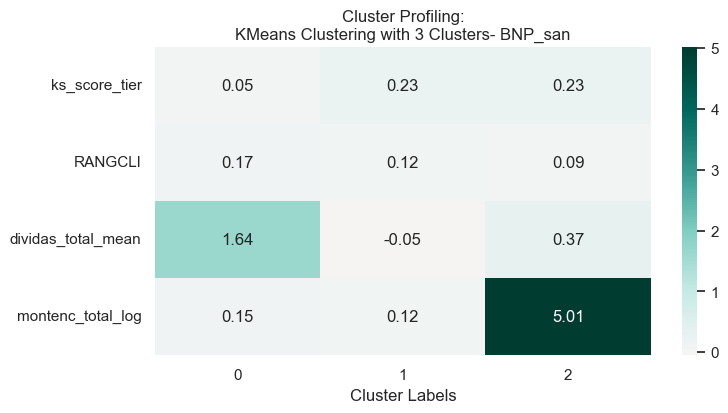

In [75]:
#visualization of averages for 2 clusters
fig, ax = plt.subplots(figsize=(8,4))

km_profile3_san = df_concat_km3_san.groupby('labels').mean().T

sns.heatmap(km_profile3_san,
            center=0, annot=True, cmap="BrBG", fmt=".2f",
            ax=ax 
            )

ax.set_xlabel("Cluster Labels")
ax.set_title("Cluster Profiling:\nKMeans Clustering with 3 Clusters- BNP_san")
plt.show()

<a class="anchor" id="3.2 Merge">

## 3.2 Merge
    
</a>

<a class="anchor" id="3.2.1 final clusters">

### 3.2.1 Final clusters
    
</a>

In [77]:
metric_features = ['active_credit_ratio', 'count_cl', 'ALLBD_mean_duration_CL__N', 'DURDEG',
'ks_score_tier', 'RANGCLI', 'dividas_total_mean', 'montenc_total_log', 'MTFINO']

In [78]:
#sol

hclust_financial_sol = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    n_clusters=3
)
financial_labels_sol = hclust_financial_sol.fit_predict(financial_data_sol)
financial_labels_sol

BNP_sol['financial_cluster_sol'] = financial_labels_sol

hclust_risk_sol = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    n_clusters=3
)
risk_labels_sol = hclust_risk_sol.fit_predict(risk_data_sol)
risk_labels_sol

BNP_sol['risk_cluster_sol'] = risk_labels_sol

In [79]:
crosstab = pd.crosstab(
    index=BNP_sol["financial_cluster_sol"],
    columns=BNP_sol["risk_cluster_sol"],
    rownames=["financial_cluster_sol"],
    colnames=["risk_cluster_sol"]
)

crosstab

risk_cluster_sol,0,1,2
financial_cluster_sol,,,
0,3632,2297,16917
1,612,601,1232
2,173,91,702


In [34]:
combo_counts_sol = BNP_sol.groupby(['financial_cluster_sol', 'risk_cluster_sol']).size()
combo_counts_sol.sort_values()

financial_cluster_sol  risk_cluster_sol
2                      1                    360
                       2                    480
0                      2                   1013
                       1                   1215
1                      2                   1370
                       1                   1495
2                      0                   2841
0                      0                   8576
1                      0                   8907
dtype: int64

In [80]:
#san

hclust_financial_san = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    n_clusters=2
)
financial_labels_san = hclust_financial_san.fit_predict(financial_data_san)
financial_labels_san

BNP_san['financial_cluster_san'] = financial_labels_san

hclust_risk_san = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    n_clusters=3
)
risk_labels_san = hclust_risk_san.fit_predict(risk_data_san)
risk_labels_san

BNP_san['risk_cluster_san'] = risk_labels_san

In [81]:
crosstab = pd.crosstab(
    index=BNP_san["financial_cluster_san"],
    columns=BNP_san["risk_cluster_san"],
    rownames=["financial_cluster_san"],
    colnames=["risk_cluster_san"]
)

crosstab

risk_cluster_san,0,1,2
financial_cluster_san,,,
0,6823,1854,17941
1,4543,1998,8003


In [37]:
combo_counts_san = BNP_san.groupby(['financial_cluster_san', 'risk_cluster_san']).size()
combo_counts_san.sort_values()

financial_cluster_san  risk_cluster_san
0                      2                    1104
                       1                    1348
2                      2                    1395
1                      2                    1928
                       1                    2478
2                      1                    3217
0                      0                    6613
2                      0                   10513
1                      0                   12566
dtype: int64

In [ ]:
'''MIN_SIZE = 200

rare_combos = combo_counts[combo_counts < MIN_SIZE].index
common_combos = combo_counts[combo_counts >= MIN_SIZE].index

print("Rare combos:", len(rare_combos))
print("Common combos:", len(common_combos))'''

<a class="anchor" id="3.2.2 Hierarchical clustering for merge">

### 3.2.2 Hierarchical clustering for merge
    
</a>

In [82]:
# Calculate centroids for each combination
BNP_sol_centroids = BNP_sol.groupby(['financial_cluster_sol', 'risk_cluster_sol'])[metric_features].mean()
BNP_sol_centroids

active_credit_ratio  count_cl  \
financial_cluster_sol risk_cluster_sol                                  
0                     0                            0.186660 -0.022026   
                      1                            0.082884  0.206791   
                      2                            0.039100 -0.075250   
1                     0                            0.319620  2.740196   
                      1                            0.242242  2.797005   
                      2                            0.472142  2.321429   
2                     0                            0.012255  0.913295   
                      1                           -0.190748  1.274725   
                      2                           -0.115360  0.257835   

                                        ALLBD_mean_duration_CL__N    DURDEG  \
financial_cluster_sol risk_cluster_sol                                        
0                     0                                  0.546625 -0.243683   
                      1                                  0.500602 -0.237429   
                      2                                  0.441392 -0.178117   
1                     0                                  0.889198 -0.083833   
                      1                                  0.829200 -0.183431   
                      2                                  0.905365 -0.180905   
2                     0                                  0.679030  0.608542   
                      1                                  0.452038  0.747863   
                      2                                  0.521600  0.517925   

                                        ks_score_tier   RANGCLI  \
financial_cluster_sol risk_cluster_sol                            
0                     0                      0.045430  0.174480   
                      1                      0.327819  0.164323   
                      2                      0.224508  0.071918   
1                     0                      0.035948  0.302104   
                      1                      0.269551  0.185614   
                      2                      0.246753  0.233772   
2                     0                      0.046243  0.753632   
                      1                      0.252747  0.651619   
                      2                      0.123932  0.385501   

                                        dividas_total_mean  montenc_total_log  \
financial_cluster_sol risk_cluster_sol                                          
0                     0                           2.634640           0.019577   
                      1                           0.395902           4.224538   
                      2                          -0.344917           0.024124   
1                     0                           2.799177           0.071007   
                      1                           0.895968           4.595840   
                      2                          -0.164120           0.049495   
2                     0                           3.268596           0.085650   
                      1                           0.998482           4.498887   
                      2                          -0.228645           0.017992   

                                          MTFINO  
financial_cluster_sol risk_cluster_sol            
0                     0                 0.032252  
                      1                -0.124194  
                      2                 0.112852  
1                     0                -0.125092  
                      1                -0.263287  
                      2                -0.227722  
2                     0                 3.776020  
                      1                 3.472200  
                      2                 3.967184

In [83]:
# Calculate centroids for each combination
BNP_san_centroids = BNP_san.groupby(['financial_cluster_san', 'risk_cluster_san'])[metric_features].mean()
BNP_san_centroids

active_credit_ratio  count_cl  \
financial_cluster_san risk_cluster_san                                  
0                     0                            0.177381  0.029606   
                      1                           -0.029248  0.317152   
                      2                            0.182380 -0.034335   
1                     0                            0.074787  2.029056   
                      1                           -0.114340  2.328829   
                      2                            0.163618  1.779333   

                                        ALLBD_mean_duration_CL__N    DURDEG  \
financial_cluster_san risk_cluster_san                                        
0                     0                                  0.035885 -0.147846   
                      1                                  0.228314 -0.079832   
                      2                                  0.001265 -0.357463   
1                     0                                  0.087860 -0.281742   
                      1                                  0.242368 -0.272578   
                      2                                  0.121810 -0.391509   

                                        ks_score_tier   RANGCLI  \
financial_cluster_san risk_cluster_san                            
0                     0                      0.086033  0.110556   
                      1                      0.362999  0.096960   
                      2                      0.244357  0.152109   
1                     0                      0.078142  0.078060   
                      1                      0.241742  0.082171   
                      2                      0.185930  0.121027   

                                        dividas_total_mean  montenc_total_log  \
financial_cluster_san risk_cluster_san                                          
0                     0                           1.274464           0.695504   
                      1                           0.248162           5.549034   
                      2                          -0.045506           0.010317   
1                     0                           1.243568           0.898096   
                      1                           0.371333           5.840333   
                      2                           0.060558           0.012092   

                                          MTFINO  
financial_cluster_san risk_cluster_san            
0                     0                 0.679747  
                      1                 0.808357  
                      2                 0.412406  
1                     0                 0.200037  
                      1                 0.225290  
                      2                 0.060860

In [84]:
'''centroids_common = data_centroids.loc[common_combos]
centroids_rare = data_centroids.loc[rare_combos]

D = cdist(centroids_rare.values, centroids_common.values, metric="euclidean")
nearest_idx = D.argmin(axis=1)

rare_to_common_map = {
    rare_combos[i]: common_combos[nearest_idx[i]]
    for i in range(len(rare_combos))
}

rare_to_common_map'''

'centroids_common = data_centroids.loc[common_combos]\ncentroids_rare = data_centroids.loc[rare_combos]\n\nD = cdist(centroids_rare.values, centroids_common.values, metric="euclidean")\nnearest_idx = D.argmin(axis=1)\n\nrare_to_common_map = {\n    rare_combos[i]: common_combos[nearest_idx[i]]\n    for i in range(len(rare_combos))\n}\n\nrare_to_common_map'

In [ ]:
'''data['combo'] = list(zip(data['value_cluster'], data['bhv_cluster'], data['loyalty_cluster']))

data['combo_fixed'] = data['combo'].apply(
    lambda c: rare_to_common_map.get(c, c)
)

# agora cria centróides “limpos”
data_centroids_fixed = (
    data
    .groupby('combo_fixed')[metric_features]
    .mean()
)'''

In [ ]:
#data_centroids = data_centroids_fixed

In [84]:
# Fit hierarchical clustering with distance tracking
hclust_sol = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels_sol = hclust_sol.fit_predict(BNP_sol_centroids)

# Build linkage matrix for dendrogram
# (Adapted from scikit-learn documentation)
counts_sol = np.zeros(hclust_sol.children_.shape[0])
n_samples_sol = len(hclust_sol.labels_)

for i, merge in enumerate(hclust_sol.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples_sol:
            current_count += 1  # Leaf node
        else:
            current_count += counts_sol[child_idx - n_samples_sol]
    counts_sol[i] = current_count

linkage_matrix = np.column_stack([
    hclust_sol.children_,
    hclust_sol.distances_,
    counts_sol
]).astype(float)

print("Linkage matrix ready for dendrogram!")

Linkage matrix ready for dendrogram!


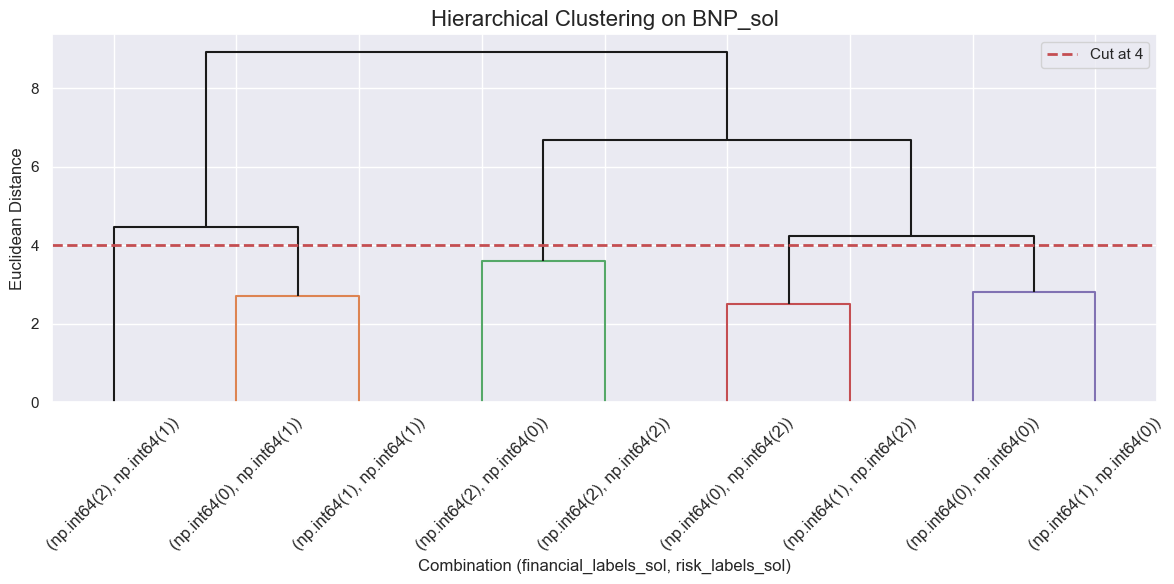

In [85]:
# Plot dendrogram with cutting options
fig = plt.figure(figsize=(12, 6))

# Potential cutting heights to consider
y_threshold = 4

dendrogram(
    linkage_matrix,
    labels=BNP_sol_centroids.index,
    color_threshold=y_threshold,
    above_threshold_color='k'
)

plt.axhline(y=y_threshold, color='r', linestyle='--', linewidth=2, label=f'Cut at {y_threshold}')

plt.title(f'Hierarchical Clustering on BNP_sol', fontsize=16)
plt.xlabel('Combination (financial_labels_sol, risk_labels_sol)')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [86]:
for k in range(3, 7):
    labels_sol = AgglomerativeClustering(
            linkage='ward',
            n_clusters=k
        ).fit_predict(BNP_sol_centroids)
    
    sizes_sol = pd.Series(labels_sol).value_counts().sort_index()
    
    print(f"\nk = {k}")
    print(sizes_sol)


k = 3
0    3
1    4
2    2
Name: count, dtype: int64

k = 4
0    4
1    2
2    2
3    1
Name: count, dtype: int64

k = 5
0    2
1    2
2    2
3    1
4    2
Name: count, dtype: int64

k = 6
0    2
1    2
2    1
3    1
4    2
5    1
Name: count, dtype: int64


In [87]:
n_final_clusters_sol = 5

hclust_final_sol = AgglomerativeClustering(
    linkage='ward',
    n_clusters=n_final_clusters_sol
)

labels_fixed_sol = hclust_final_sol.fit_predict(BNP_sol_centroids)
labels_fixed_sol

array([2, 1, 4, 2, 1, 4, 0, 3, 0])

In [124]:
n_final_clusters_sol = 5

kmeans_final_sol = KMeans(
    init='k-means++',
    n_init=20,
    random_state=42,
    n_clusters= n_final_clusters_sol
)

labels_fixed_sol = kmeans_final_sol.fit_predict(BNP_sol_centroids)
labels_fixed_sol

c:\Users\nicol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([3, 0, 1, 2, 4, 1, 3, 0, 1], dtype=int32)

In [88]:
BNP_sol_centroids['merged_labels_sol'] = labels_fixed_sol
BNP_sol_centroids

active_credit_ratio  count_cl  \
financial_cluster_sol risk_cluster_sol                                  
0                     0                            0.186660 -0.022026   
                      1                            0.082884  0.206791   
                      2                            0.039100 -0.075250   
1                     0                            0.319620  2.740196   
                      1                            0.242242  2.797005   
                      2                            0.472142  2.321429   
2                     0                            0.012255  0.913295   
                      1                           -0.190748  1.274725   
                      2                           -0.115360  0.257835   

                                        ALLBD_mean_duration_CL__N    DURDEG  \
financial_cluster_sol risk_cluster_sol                                        
0                     0                                  0.546625 -0.243683   
                      1                                  0.500602 -0.237429   
                      2                                  0.441392 -0.178117   
1                     0                                  0.889198 -0.083833   
                      1                                  0.829200 -0.183431   
                      2                                  0.905365 -0.180905   
2                     0                                  0.679030  0.608542   
                      1                                  0.452038  0.747863   
                      2                                  0.521600  0.517925   

                                        ks_score_tier   RANGCLI  \
financial_cluster_sol risk_cluster_sol                            
0                     0                      0.045430  0.174480   
                      1                      0.327819  0.164323   
                      2                      0.224508  0.071918   
1                     0                      0.035948  0.302104   
                      1                      0.269551  0.185614   
                      2                      0.246753  0.233772   
2                     0                      0.046243  0.753632   
                      1                      0.252747  0.651619   
                      2                      0.123932  0.385501   

                                        dividas_total_mean  montenc_total_log  \
financial_cluster_sol risk_cluster_sol                                          
0                     0                           2.634640           0.019577   
                      1                           0.395902           4.224538   
                      2                          -0.344917           0.024124   
1                     0                           2.799177           0.071007   
                      1                           0.895968           4.595840   
                      2                          -0.164120           0.049495   
2                     0                           3.268596           0.085650   
                      1                           0.998482           4.498887   
                      2                          -0.228645           0.017992   

                                          MTFINO  merged_labels_sol  
financial_cluster_sol risk_cluster_sol                               
0                     0                 0.032252                  2  
                      1                -0.124194                  1  
                      2                 0.112852                  4  
1                     0                -0.125092                  2  
                      1                -0.263287                  1  
                      2                -0.227722                  4  
2                     0                 3.776020                  0  
                      1                 3.472200                  3  
                      2             

In [89]:
cluster_mapper_sol = BNP_sol_centroids['merged_labels_sol'].to_dict()
cluster_mapper_sol

{(0, 0): 2,
 (0, 1): 1,
 (0, 2): 4,
 (1, 0): 2,
 (1, 1): 1,
 (1, 2): 4,
 (2, 0): 0,
 (2, 1): 3,
 (2, 2): 0}

In [90]:
BNP_sol['merged_labels_sol'] = list(zip(
    BNP_sol['financial_cluster_sol'],
    BNP_sol['risk_cluster_sol']
))

BNP_sol['merged_labels_sol'] = BNP_sol['merged_labels_sol'].map(cluster_mapper_sol)

In [91]:
BNP_sol['merged_labels_sol'].value_counts()

merged_labels_sol
4    18149
2     4244
1     2898
0      875
3       91
Name: count, dtype: int64

In [92]:
# Merged cluster centroids
BNP_sol.groupby('merged_labels_sol').mean(numeric_only=True)[metric_features]

,active_credit_ratio,count_cl,ALLBD_mean_duration_CL__N,DURDEG,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log,MTFINO
merged_labels_sol,,,,,,,,,
0,-0.090129,0.387429,0.552726,0.535841,0.108571,0.458286,0.462810,0.031369,3.929388
1,0.115932,0.743961,0.568748,-0.226231,0.315735,0.168739,0.499608,4.301540,-0.153040
2,0.205833,0.376296,0.596026,-0.220632,0.044062,0.192884,2.658367,0.026993,0.009563
3,-0.190748,1.274725,0.452038,0.747863,0.252747,0.651619,0.998482,4.498887,3.472200
4,0.068496,0.087443,0.472887,-0.178307,0.226018,0.082905,-0.332644,0.025847,0.089733


In [93]:
# Quick distinctiveness check (R²)
r2_merged_sol = get_rsq(BNP_sol, metric_features, 'merged_labels_sol')
print(f"\nMerged clustering R² for BNP_sol: {r2_merged_sol:.4f}")


Merged clustering R² for BNP_sol: 0.3965


In [94]:
# Fit hierarchical clustering with distance tracking
hclust_san = AgglomerativeClustering(
    linkage='ward',
    metric='euclidean',
    distance_threshold=0,
    n_clusters=None
)
hclust_labels_san = hclust_san.fit_predict(BNP_san_centroids)

# Build linkage matrix for dendrogram
# (Adapted from scikit-learn documentation)
counts_san = np.zeros(hclust_san.children_.shape[0])
n_samples_san = len(hclust_san.labels_)

for i, merge in enumerate(hclust_san.children_):
    current_count = 0
    for child_idx in merge:
        if child_idx < n_samples_san:
            current_count += 1  # Leaf node
        else:
            current_count += counts_san[child_idx - n_samples_san]
    counts_san[i] = current_count

linkage_matrix = np.column_stack([
    hclust_san.children_,
    hclust_san.distances_,
    counts_san
]).astype(float)

print("Linkage matrix ready for dendrogram!")

Linkage matrix ready for dendrogram!


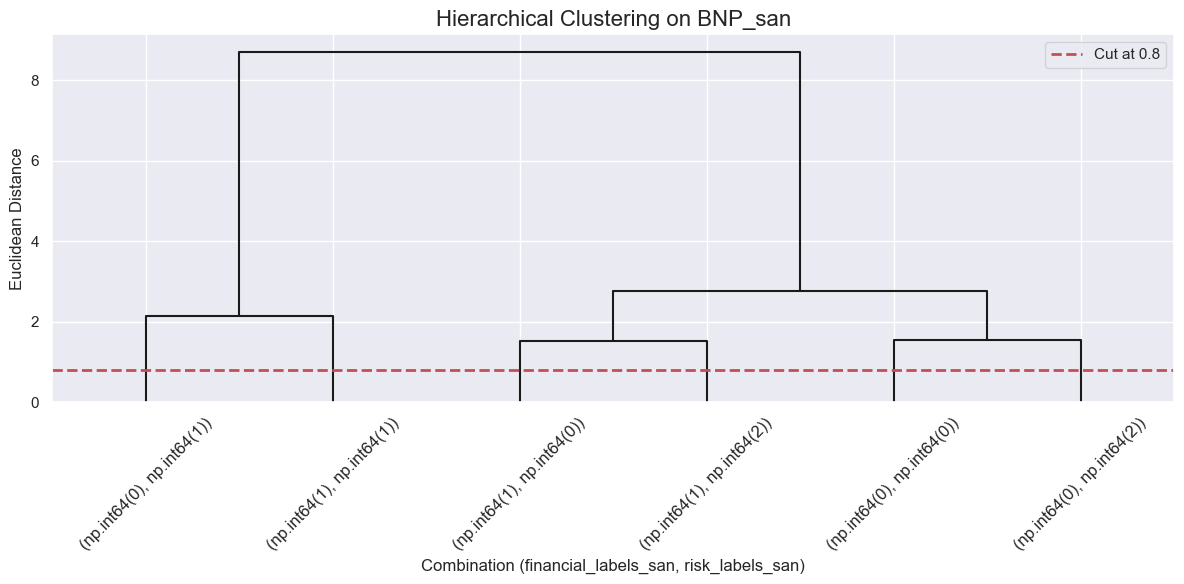

In [95]:
# Plot dendrogram with cutting options
fig = plt.figure(figsize=(12, 6))

# Potential cutting heights to consider
y_threshold = 0.8 # Can adjust this!

dendrogram(
    linkage_matrix,
    labels=BNP_san_centroids.index,
    color_threshold=y_threshold,
    above_threshold_color='k'
)

plt.axhline(y=y_threshold, color='r', linestyle='--', linewidth=2, label=f'Cut at {y_threshold}')

plt.title(f'Hierarchical Clustering on BNP_san', fontsize=16)
plt.xlabel('Combination (financial_labels_san, risk_labels_san)')
plt.ylabel('Euclidean Distance')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [91]:
for k in range(3, 7):
    labels_san = AgglomerativeClustering(
            linkage='ward',
            n_clusters=k
        ).fit_predict(BNP_san_centroids)
    
    sizes_san = pd.Series(labels_san).value_counts().sort_index()
    
    print(f"\nk = {k}")
    print(sizes_san)


k = 3
0    3
1    4
2    2
Name: count, dtype: int64

k = 4
0    4
1    2
2    2
3    1
Name: count, dtype: int64

k = 5
0    2
1    2
2    2
3    1
4    2
Name: count, dtype: int64

k = 6
0    2
1    2
2    1
3    1
4    2
5    1
Name: count, dtype: int64


In [96]:
n_final_clusters_san = 2

hclust_final_san = AgglomerativeClustering(
    linkage='ward',
    n_clusters=n_final_clusters_san
)

labels_fixed_san = hclust_final_san.fit_predict(BNP_san_centroids)
labels_fixed_san

array([0, 1, 0, 0, 1, 0])

In [142]:
n_final_clusters_san = 3

kmeans_final_san = KMeans(
    init='k-means++',
    n_init=20,
    random_state=42,
    n_clusters= n_final_clusters_san
)

labels_fixed_san = kmeans_final_san.fit_predict(BNP_san_centroids)
labels_fixed_san

c:\Users\nicol\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([2, 1, 2, 0, 1, 0, 0, 1, 0], dtype=int32)

In [97]:
BNP_san_centroids['merged_labels_san'] = labels_fixed_san
BNP_san_centroids

active_credit_ratio  count_cl  \
financial_cluster_san risk_cluster_san                                  
0                     0                            0.177381  0.029606   
                      1                           -0.029248  0.317152   
                      2                            0.182380 -0.034335   
1                     0                            0.074787  2.029056   
                      1                           -0.114340  2.328829   
                      2                            0.163618  1.779333   

                                        ALLBD_mean_duration_CL__N    DURDEG  \
financial_cluster_san risk_cluster_san                                        
0                     0                                  0.035885 -0.147846   
                      1                                  0.228314 -0.079832   
                      2                                  0.001265 -0.357463   
1                     0                                  0.087860 -0.281742   
                      1                                  0.242368 -0.272578   
                      2                                  0.121810 -0.391509   

                                        ks_score_tier   RANGCLI  \
financial_cluster_san risk_cluster_san                            
0                     0                      0.086033  0.110556   
                      1                      0.362999  0.096960   
                      2                      0.244357  0.152109   
1                     0                      0.078142  0.078060   
                      1                      0.241742  0.082171   
                      2                      0.185930  0.121027   

                                        dividas_total_mean  montenc_total_log  \
financial_cluster_san risk_cluster_san                                          
0                     0                           1.274464           0.695504   
                      1                           0.248162           5.549034   
                      2                          -0.045506           0.010317   
1                     0                           1.243568           0.898096   
                      1                           0.371333           5.840333   
                      2                           0.060558           0.012092   

                                          MTFINO  merged_labels_san  
financial_cluster_san risk_cluster_san                               
0                     0                 0.679747                  0  
                      1                 0.808357                  1  
                      2                 0.412406                  0  
1                     0                 0.200037                  0  
                      1                 0.225290                  1  
                      2                 0.060860                  0

In [98]:
cluster_mapper_san = BNP_san_centroids['merged_labels_san'].to_dict()
cluster_mapper_san

{(0, 0): 0, (0, 1): 1, (0, 2): 0, (1, 0): 0, (1, 1): 1, (1, 2): 0}

In [99]:
BNP_san['merged_labels_san'] = list(zip(
    BNP_san['financial_cluster_san'],
    BNP_san['risk_cluster_san']
))

BNP_san['merged_labels_san'] = BNP_san['merged_labels_san'].map(cluster_mapper_san)

In [100]:
BNP_san['merged_labels_san'].value_counts()

merged_labels_san
0    37310
1     3852
Name: count, dtype: int64

In [101]:
# Merged cluster centroids
BNP_san.groupby('merged_labels_san').mean(numeric_only=True)[metric_features]

,active_credit_ratio,count_cl,ALLBD_mean_duration_CL__N,DURDEG,ks_score_tier,RANGCLI,dividas_total_mean,montenc_total_log,MTFINO
merged_labels_san,,,,,,,,,
0,0.164340,0.617636,0.043997,-0.317212,0.182632,0.128826,0.375594,0.244100,0.360030
1,-0.073384,1.360592,0.235604,-0.179808,0.300104,0.089289,0.312050,5.700128,0.505925


In [102]:
# Quick distinctiveness check (R²)
r2_merged_san = get_rsq(BNP_san, metric_features, 'merged_labels_san')
print(f"\nMerged clustering R² for BNP_san: {r2_merged_san:.4f}")


Merged clustering R² for BNP_san: 0.2728


<a class="anchor" id="3.3 Results">

## 3.3 Results
    
</a>

In [69]:
financial_features = ['active_credit_ratio', 'count_cl_log', 'ALLBD_mean_duration_CL__N_log', 'DURDEG']
risk_features = ['ks_score_tier', 'RANGCLI_log', 'dividas_total_mean_log', 'montenc_total_log']

<a class="anchor" id="3.3.1 Financial features">

### 3.3.1 Financial Features
    
</a>

In [80]:
BNP_sol['hc3_labels_sol'] = hc3_labels_sol
BNP_san['hc3_labels_san'] = hc3_labels_san

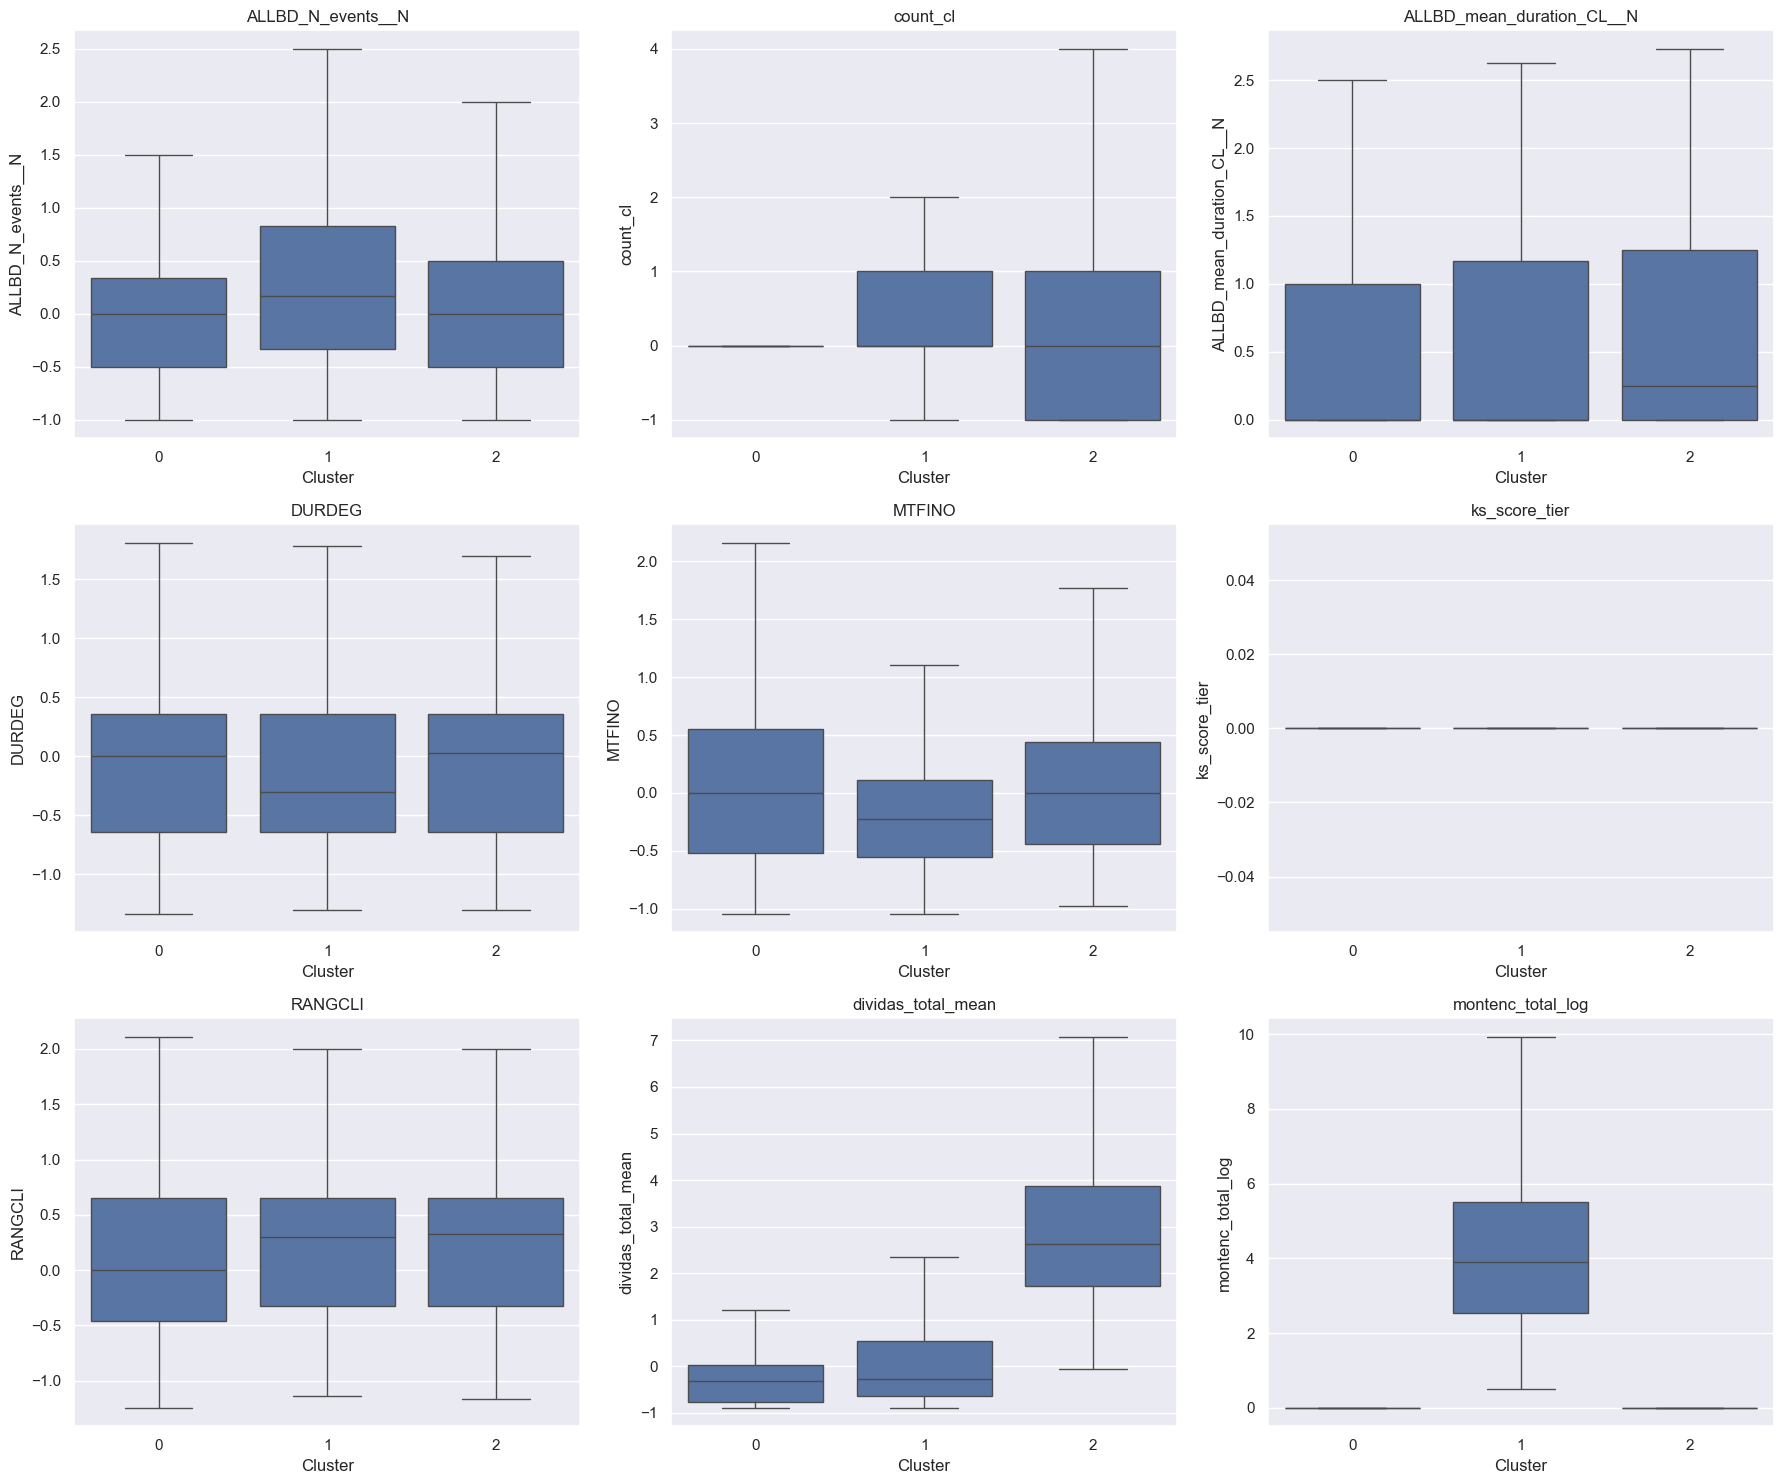

In [81]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for ax, var in zip(axes.flatten(), financial_features):
    sns.boxplot(
        data=BNP_sol,
        x="hc3_labels_sol",
        y=var,
        ax=ax,
        showfliers=False
    )
    ax.set_title(var)
    ax.set_xlabel("Cluster")

plt.tight_layout()
plt.show()

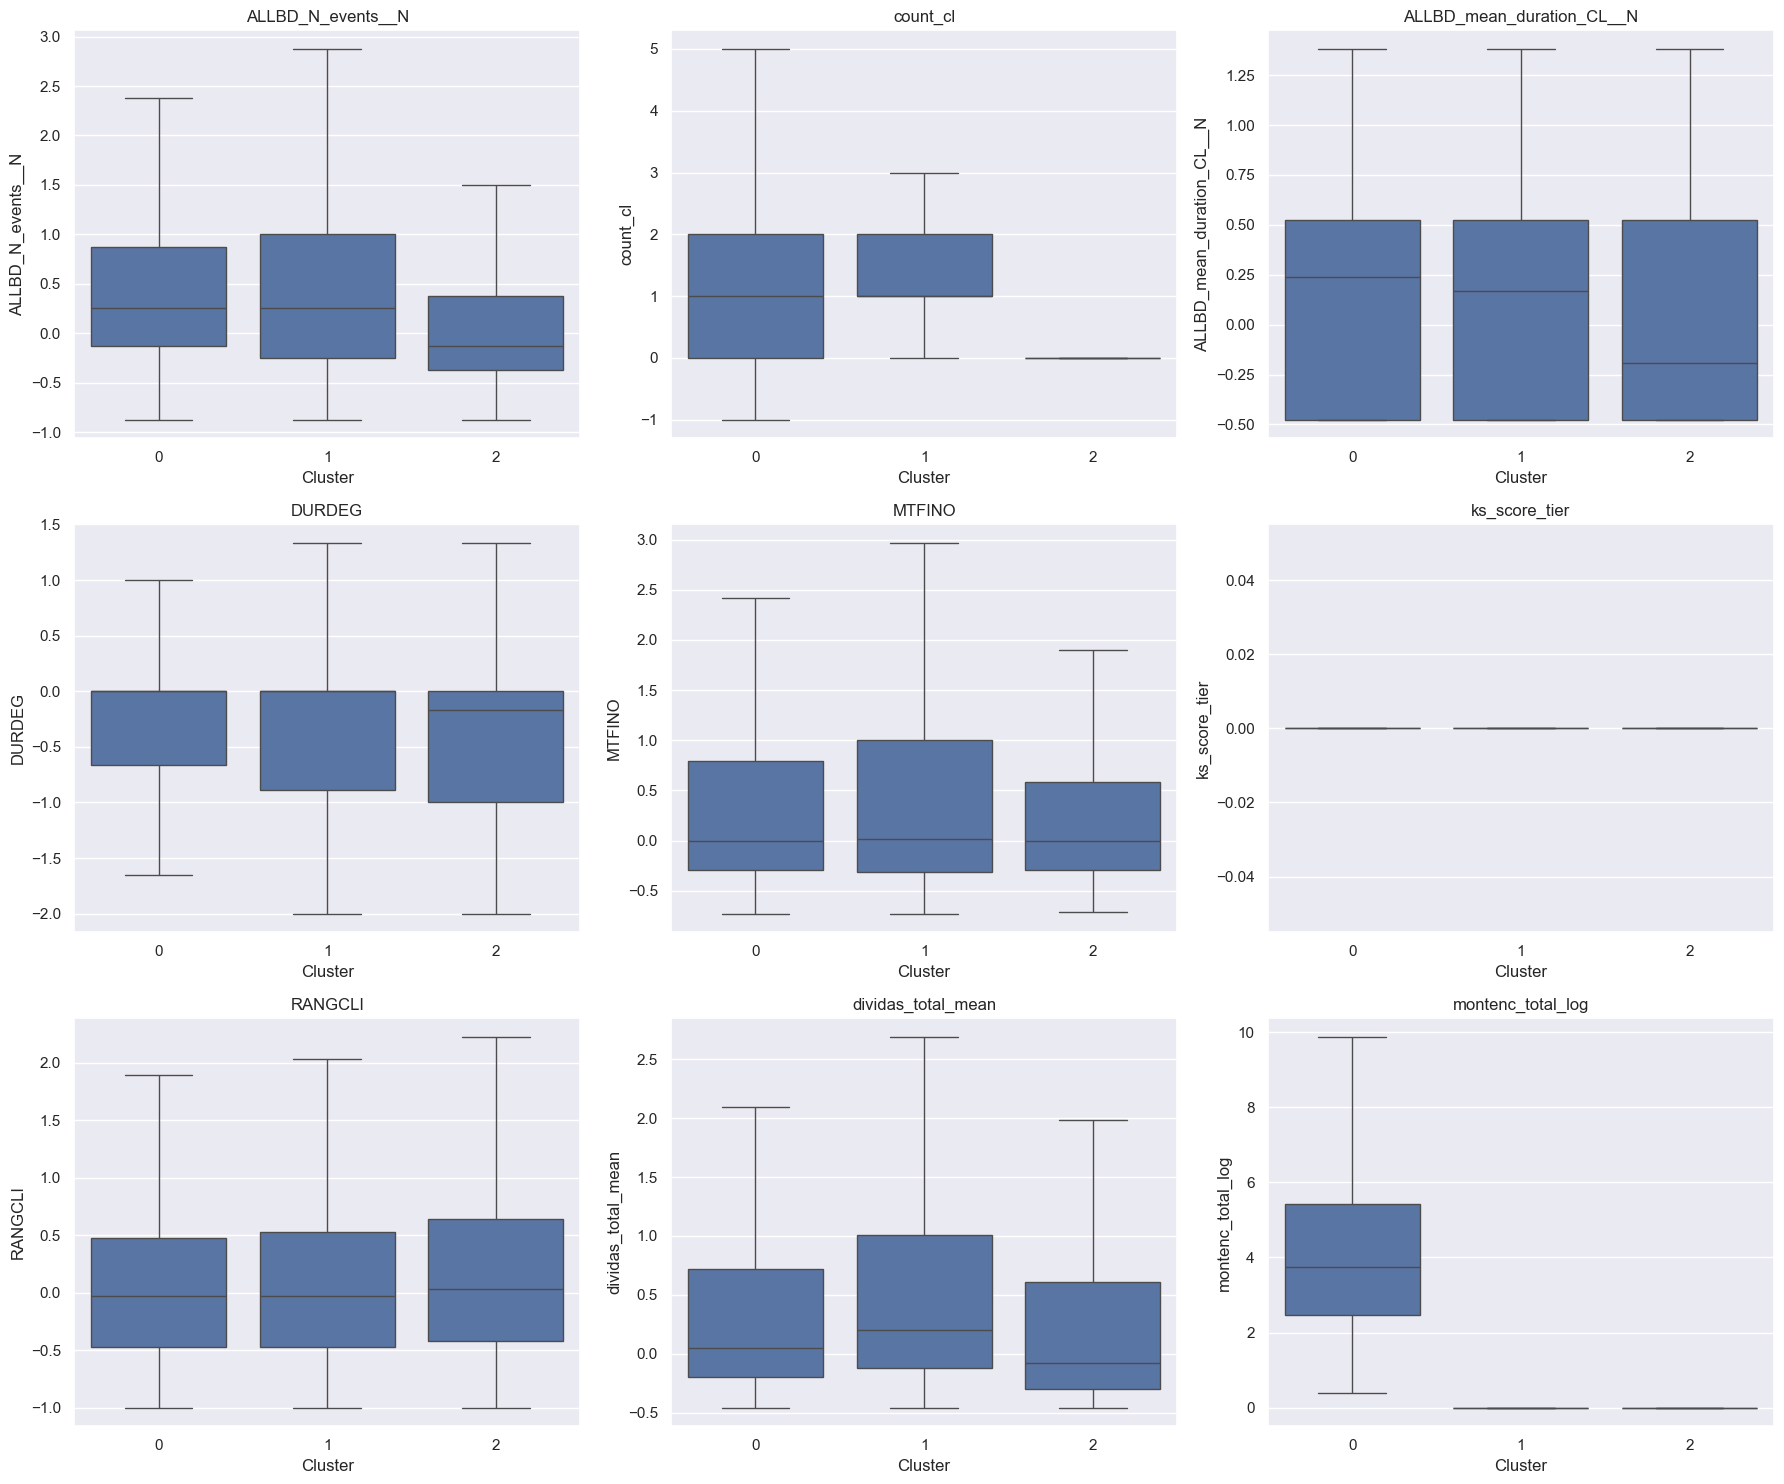

In [82]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for ax, var in zip(axes.flatten(), financial_features):
    sns.boxplot(
        data=BNP_san,
        x="hc3_labels_san",
        y=var,
        ax=ax,
        showfliers=False
    )
    ax.set_title(var)
    ax.set_xlabel("Cluster")

plt.tight_layout()
plt.show()

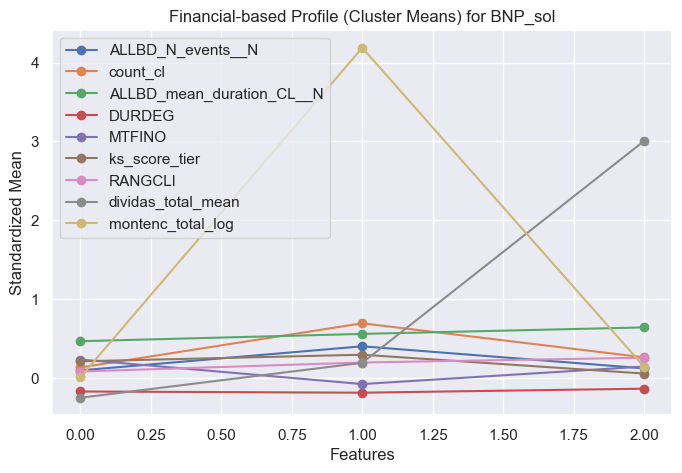

In [83]:
financial_means_sol = BNP_sol.groupby("hc3_labels_sol")[financial_features].mean()

# normalizar para visualização
# value_means_norm = (value_means - value_means.mean()) / value_means.std()

financial_means_sol.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Financial-based Profile (Cluster Means) for BNP_sol")
plt.ylabel("Standardized Mean")
plt.xlabel("Features")
plt.grid(True)
plt.show()

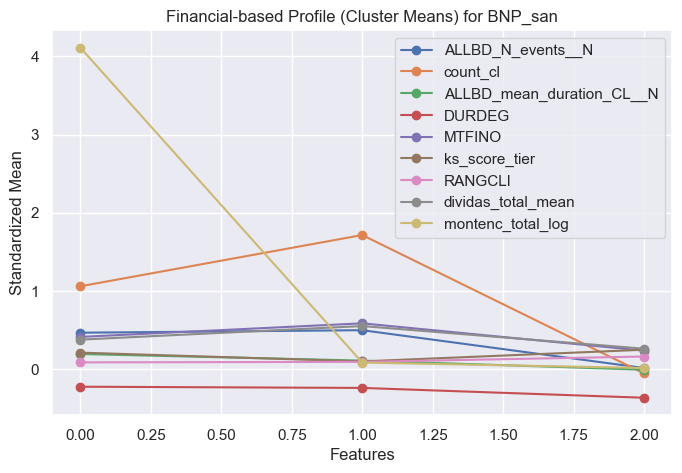

In [84]:
financial_means_san = BNP_san.groupby("hc3_labels_san")[financial_features].mean()

# normalizar para visualização
# value_means_norm = (value_means - value_means.mean()) / value_means.std()

financial_means_san.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Financial-based Profile (Cluster Means) for BNP_san")
plt.ylabel("Standardized Mean")
plt.xlabel("Features")
plt.grid(True)
plt.show()

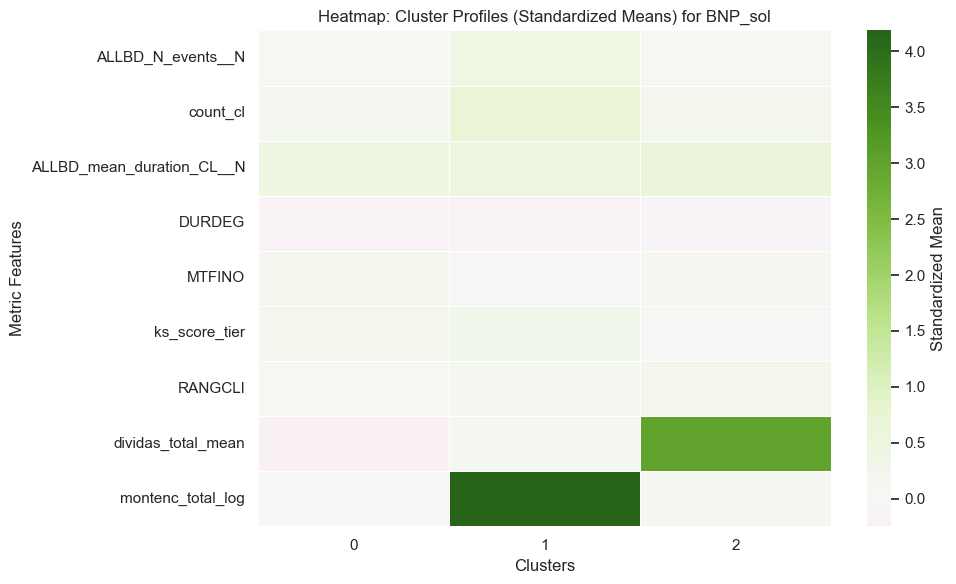

In [85]:
cluster_col_sol = "hc3_labels_sol"  # ou "merged_labels"

cluster_means_sol = BNP_sol.groupby(cluster_col_sol)[financial_features].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_means_sol.T,   # transposto: features nas linhas
    cmap="PiYG",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Mean"}
)

plt.title("Heatmap: Cluster Profiles (Standardized Means) for BNP_sol")
plt.xlabel("Clusters")
plt.ylabel("Metric Features")
plt.tight_layout()
plt.show()

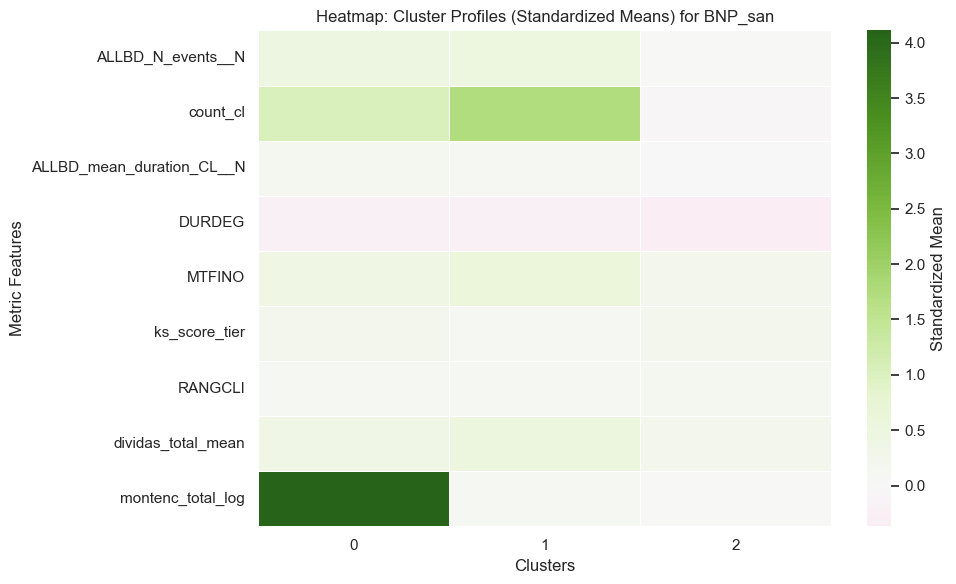

In [87]:
cluster_col_san = "hc3_labels_san"  # ou "merged_labels"

cluster_means_san = BNP_san.groupby(cluster_col_san)[financial_features].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_means_san.T,   # transposto: features nas linhas
    cmap="PiYG",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Mean"}
)

plt.title("Heatmap: Cluster Profiles (Standardized Means) for BNP_san")
plt.xlabel("Clusters")
plt.ylabel("Metric Features")
plt.tight_layout()
plt.show()

<a class="anchor" id="3.3.2 risk features">

### 3.3.2 Risk Features
    
</a>

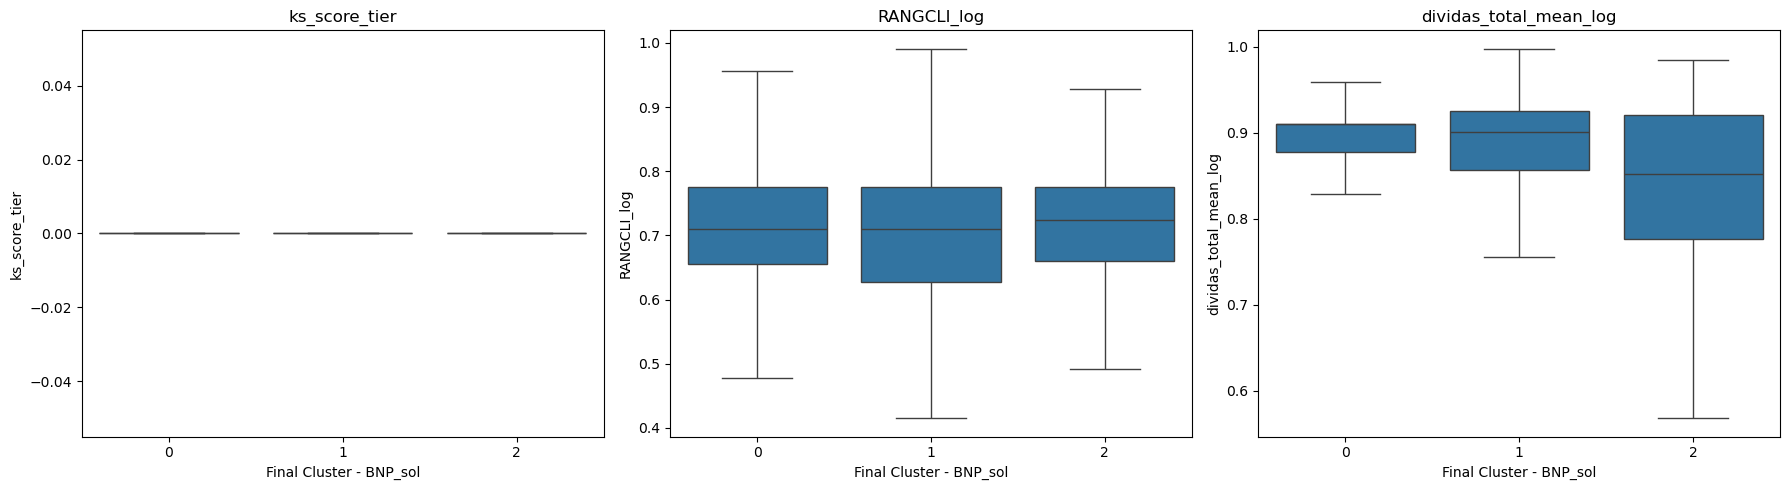

In [96]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, risk_features):
    sns.boxplot(
        data=BNP_sol,
        x="merged_labels_sol",
        y=var,
        ax=ax,
        showfliers=False
    )
    ax.set_title(var)
    ax.set_xlabel("Final Cluster - BNP_sol")

plt.tight_layout()
plt.show()

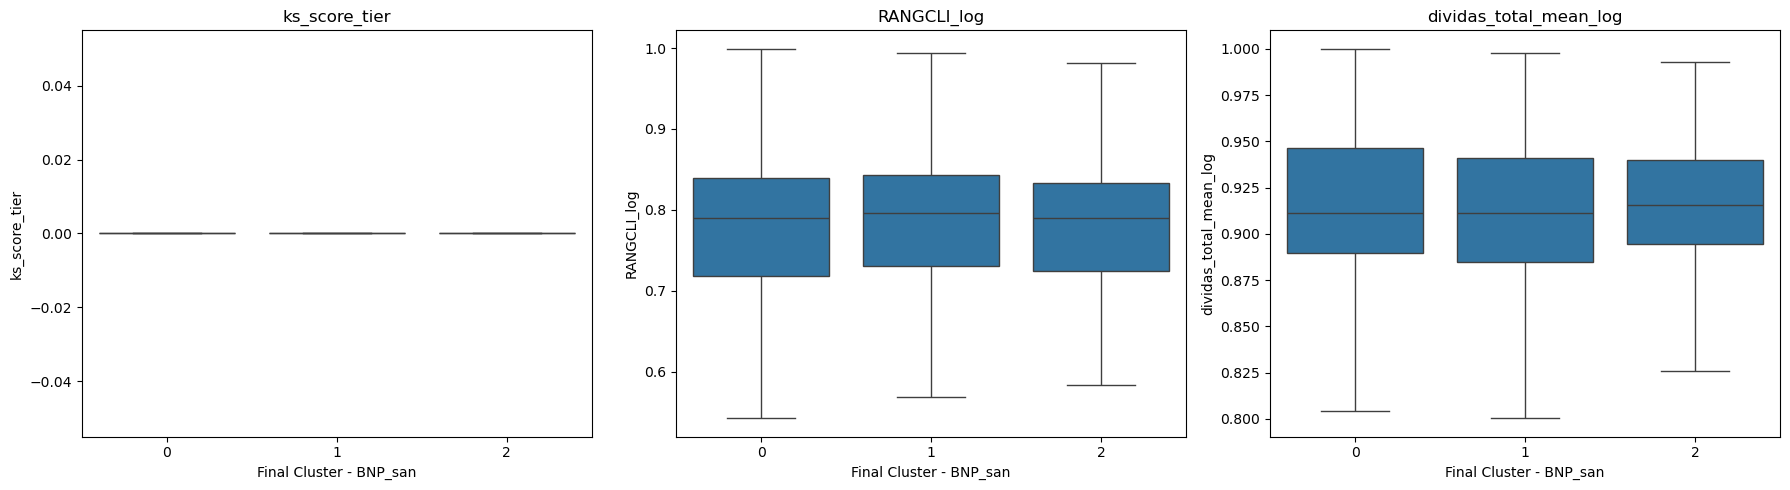

In [97]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, var in zip(axes, risk_features):
    sns.boxplot(
        data=BNP_san,
        x="merged_labels_san",
        y=var,
        ax=ax,
        showfliers=False
    )
    ax.set_title(var)
    ax.set_xlabel("Final Cluster - BNP_san")

plt.tight_layout()
plt.show()

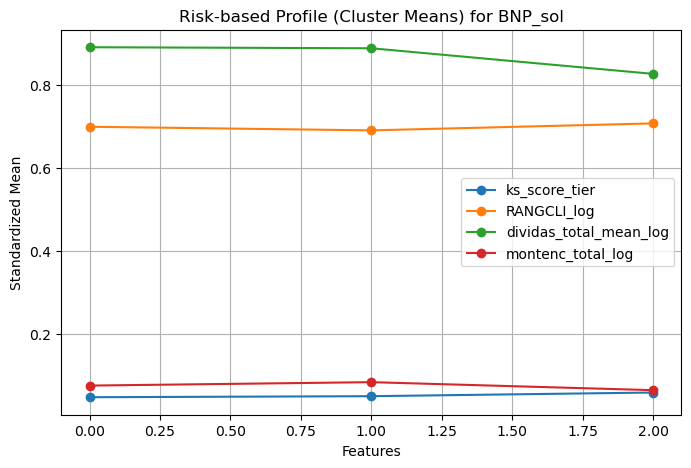

In [98]:
risk_means_sol = BNP_sol.groupby("merged_labels_sol")[risk_features].mean()

# normalizar para visualização
# value_means_norm = (value_means - value_means.mean()) / value_means.std()

risk_means_sol.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Risk-based Profile (Cluster Means) for BNP_sol")
plt.ylabel("Standardized Mean")
plt.xlabel("Features")
plt.grid(True)
plt.show()

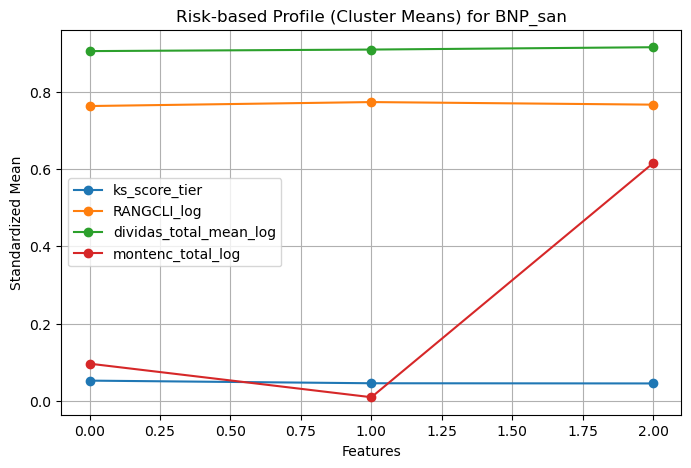

In [99]:
risk_means_san = BNP_san.groupby("merged_labels_san")[risk_features].mean()

# normalizar para visualização
# value_means_norm = (value_means - value_means.mean()) / value_means.std()

risk_means_san.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Risk-based Profile (Cluster Means) for BNP_san")
plt.ylabel("Standardized Mean")
plt.xlabel("Features")
plt.grid(True)
plt.show()

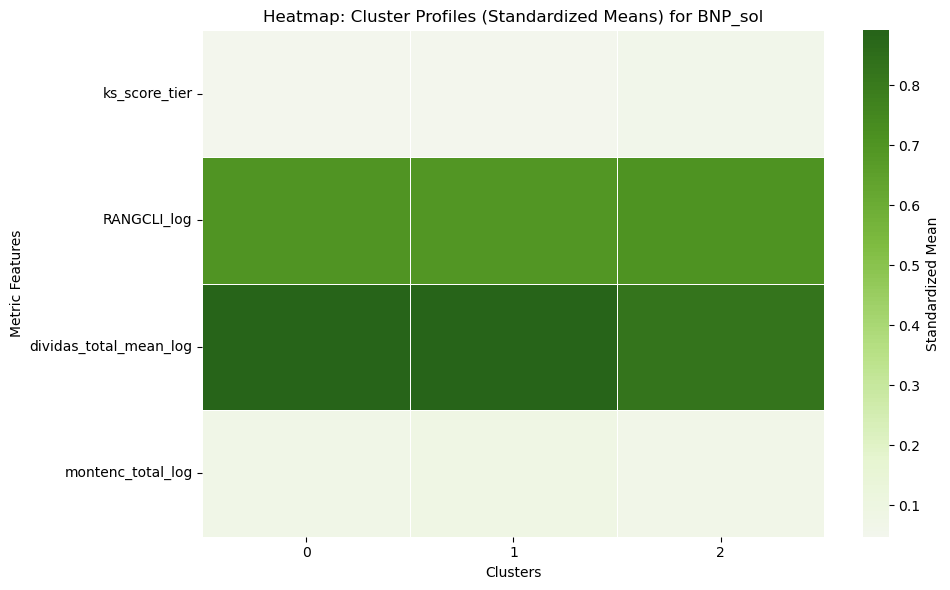

In [100]:
cluster_col_sol = "merged_labels_sol"  # ou "merged_labels"

cluster_means_sol = BNP_sol.groupby(cluster_col_sol)[risk_features].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_means_sol.T,   # transposto: features nas linhas
    cmap="PiYG",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Mean"}
)

plt.title("Heatmap: Cluster Profiles (Standardized Means) for BNP_sol")
plt.xlabel("Clusters")
plt.ylabel("Metric Features")
plt.tight_layout()
plt.show()

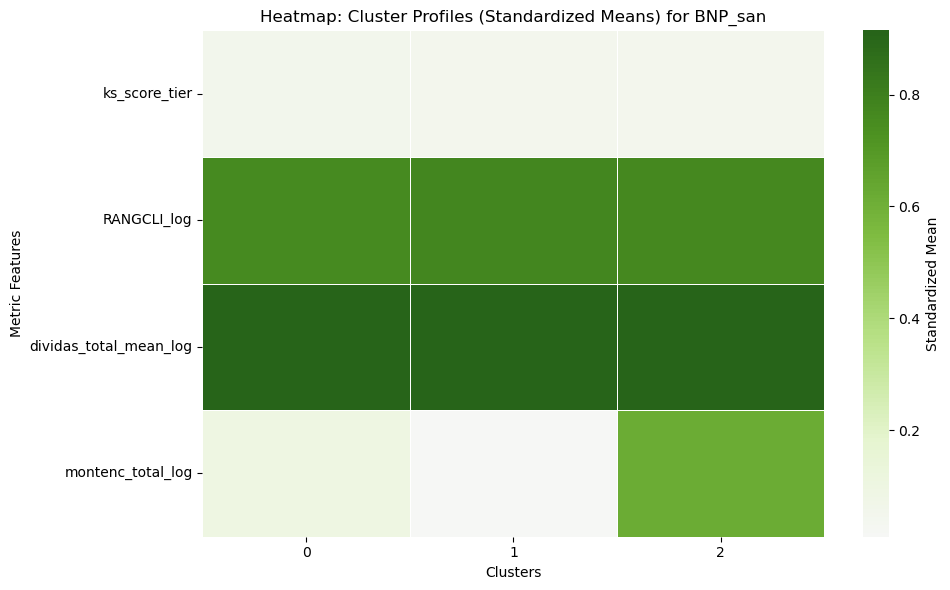

In [101]:
cluster_col_san = "merged_labels_san"  # ou "merged_labels"

cluster_means_san = BNP_san.groupby(cluster_col_san)[risk_features].mean()

plt.figure(figsize=(10,6))

sns.heatmap(
    cluster_means_san.T,   # transposto: features nas linhas
    cmap="PiYG",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Mean"}
)

plt.title("Heatmap: Cluster Profiles (Standardized Means) for BNP_san")
plt.xlabel("Clusters")
plt.ylabel("Metric Features")
plt.tight_layout()
plt.show()

<a class="anchor" id="3.3.3 non metric features">

### 3.3.3 Non-metric Features
    
</a>

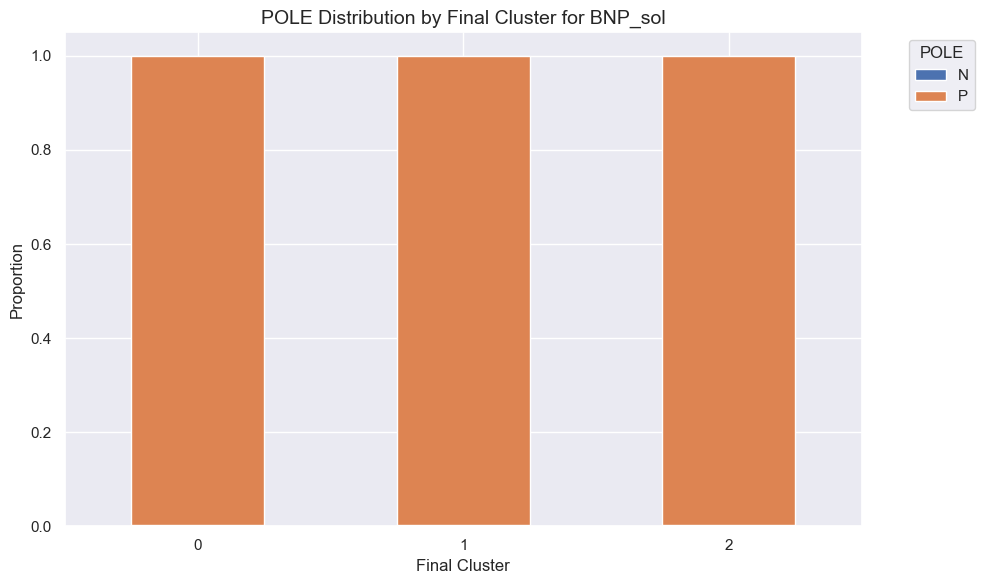

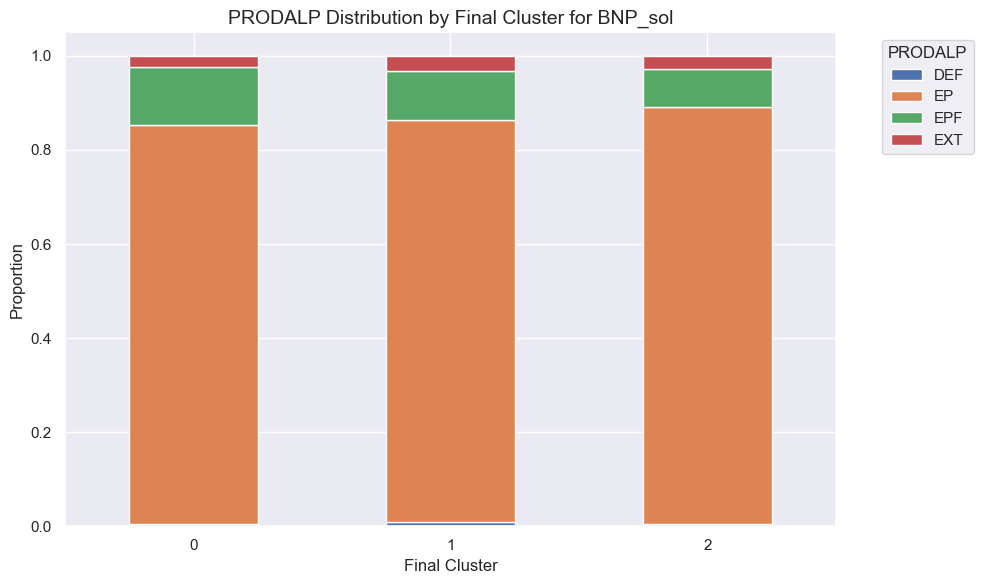

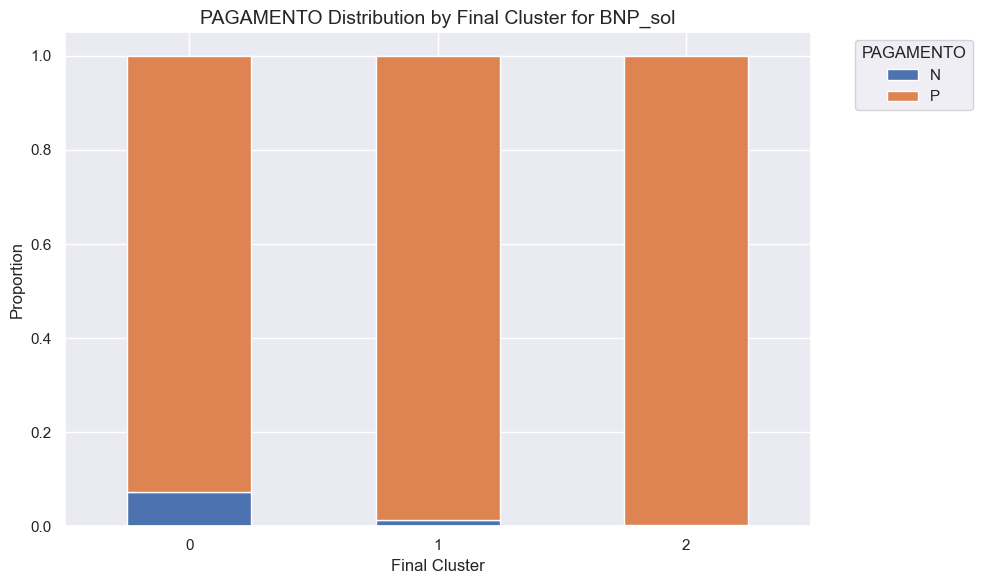

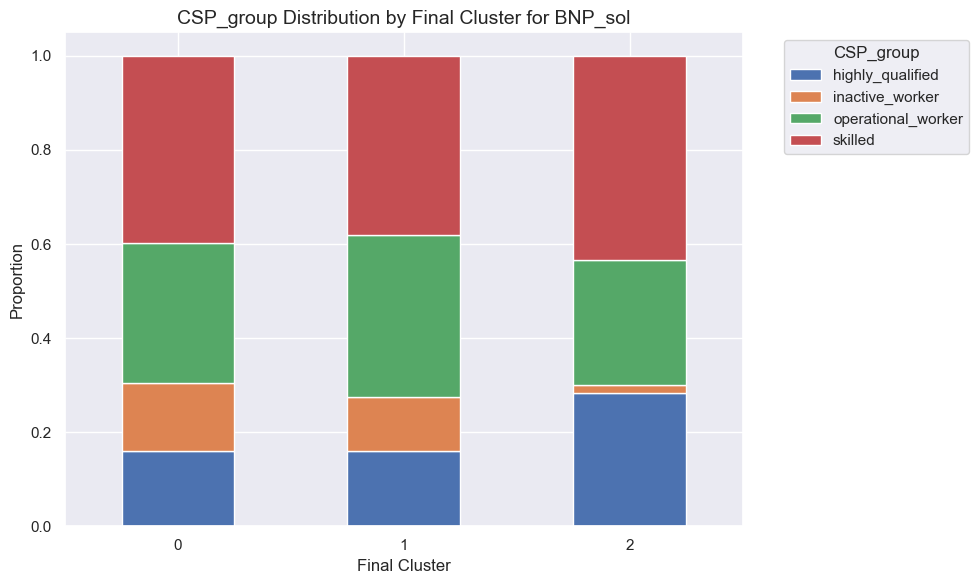

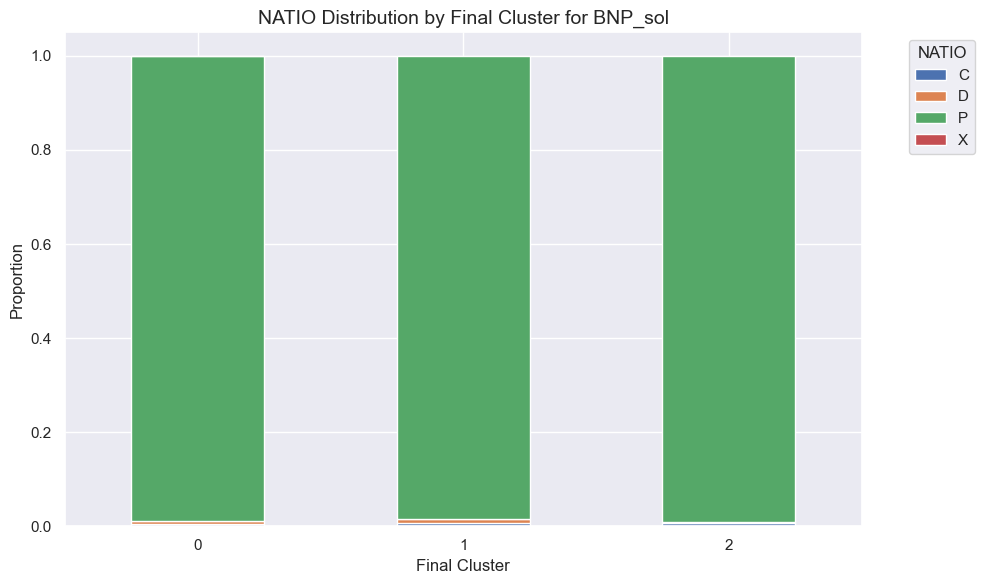

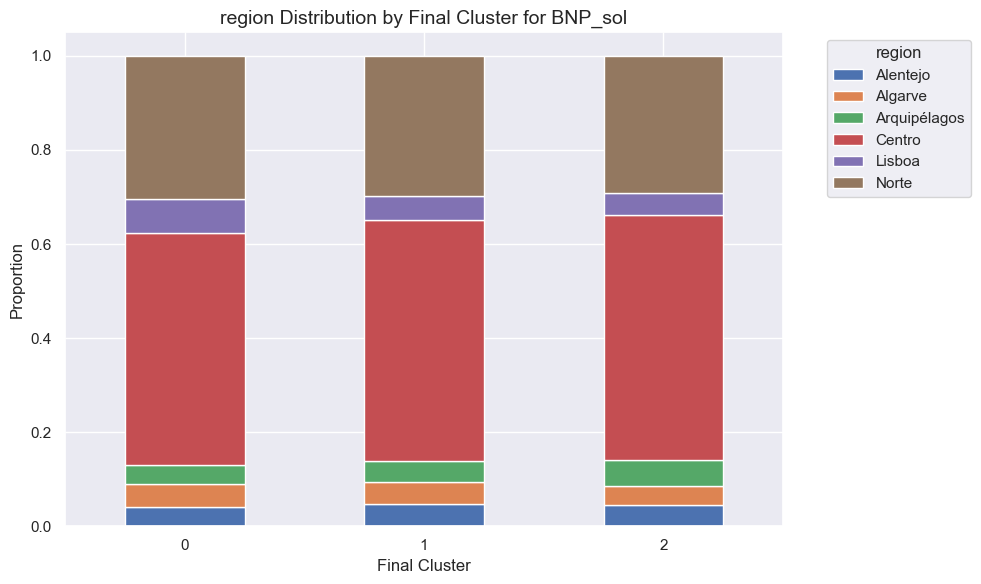

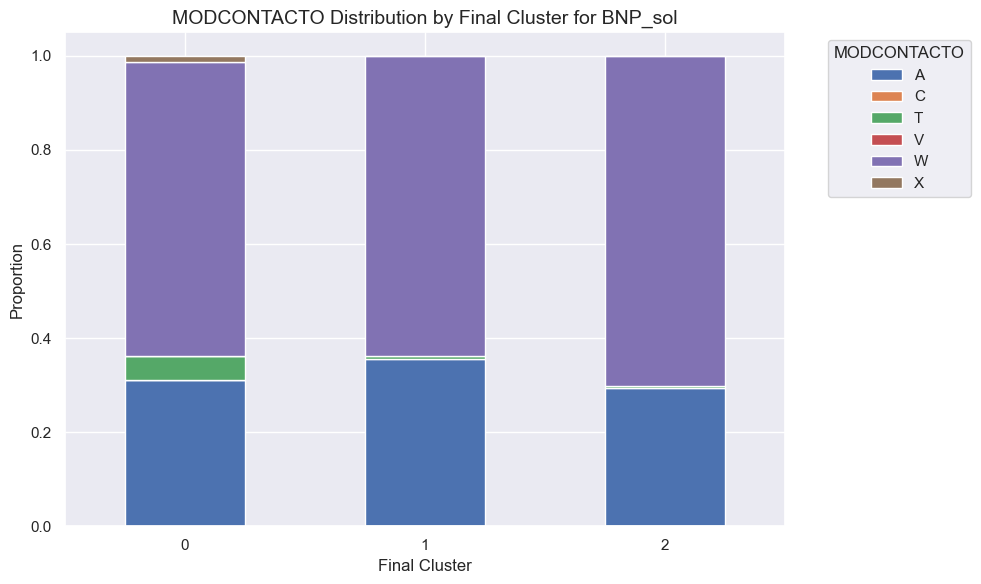

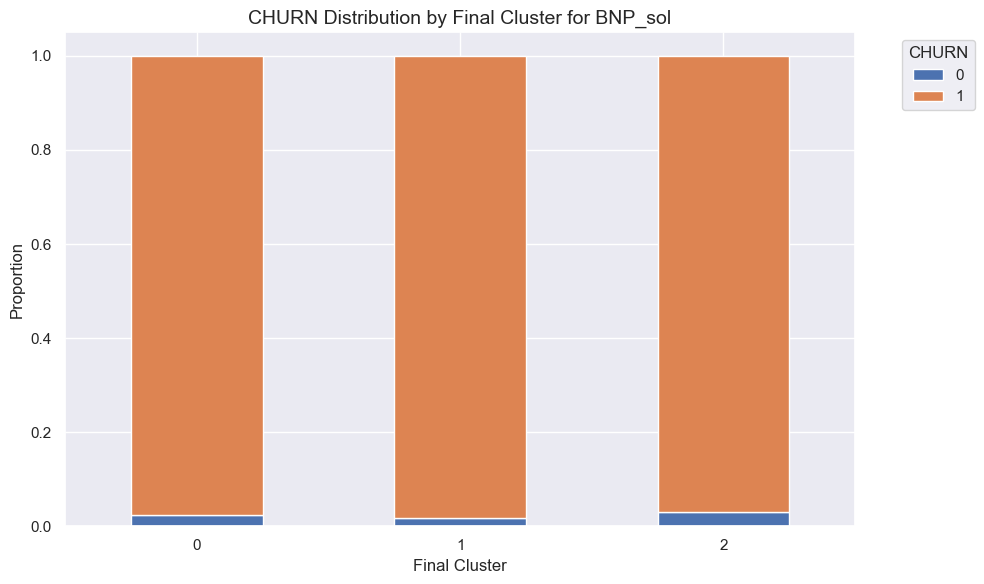

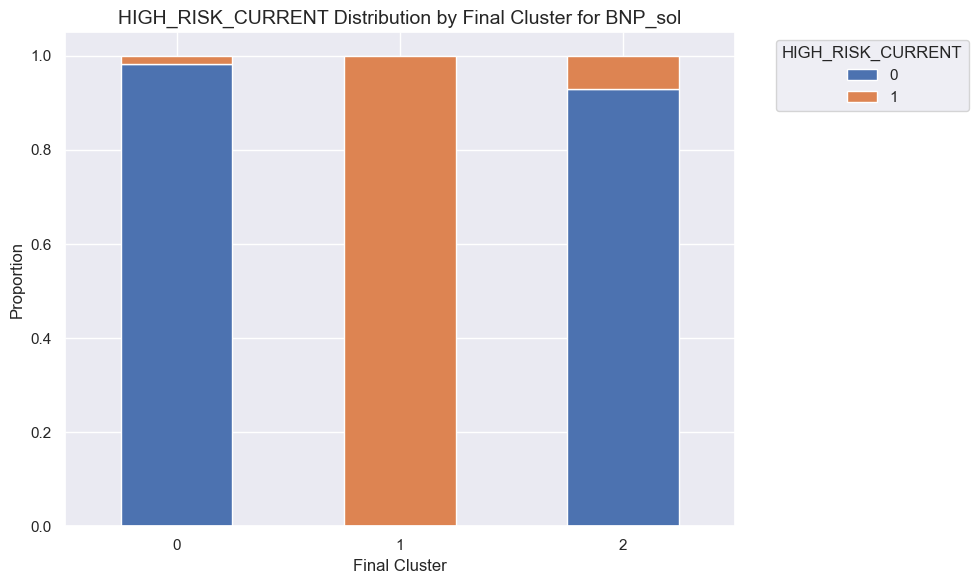

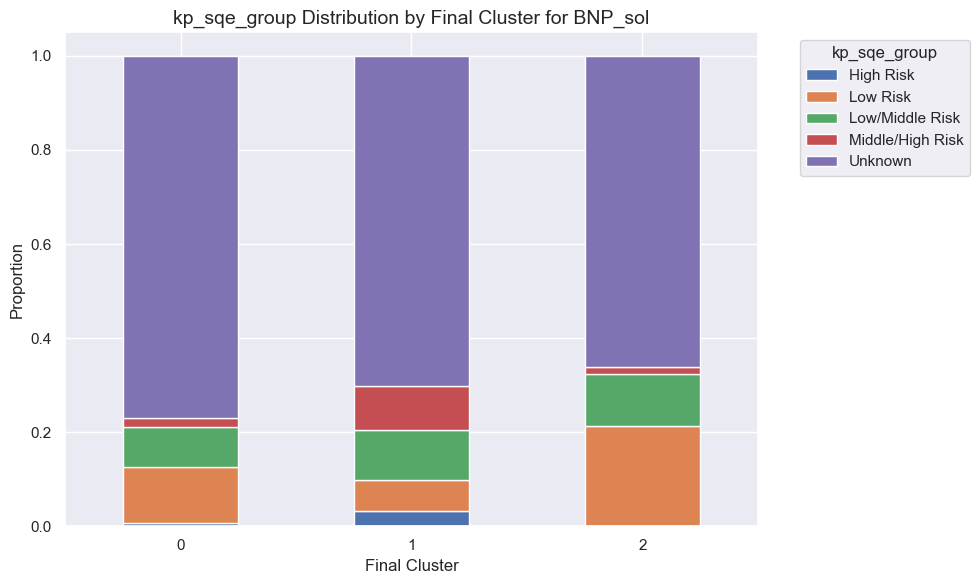

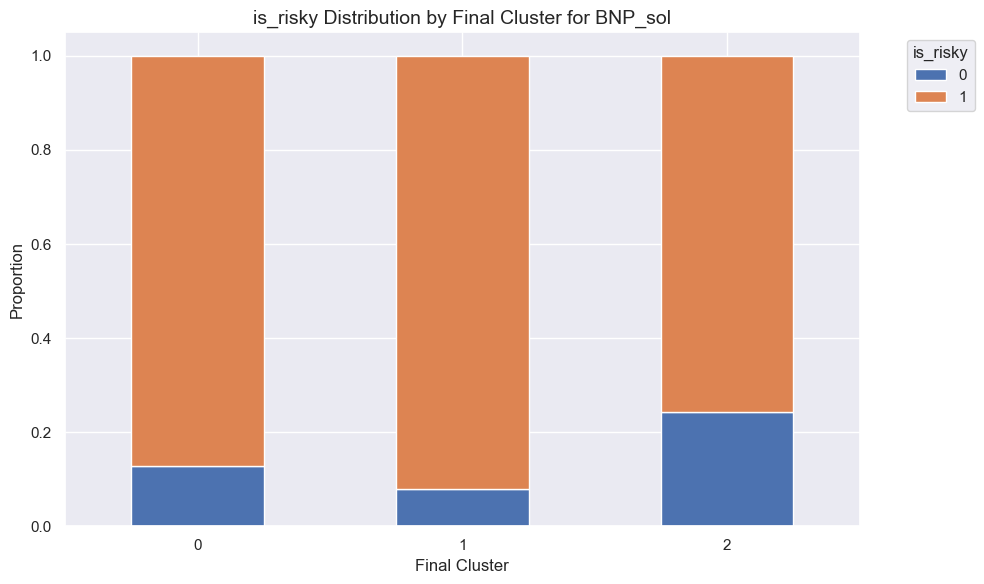

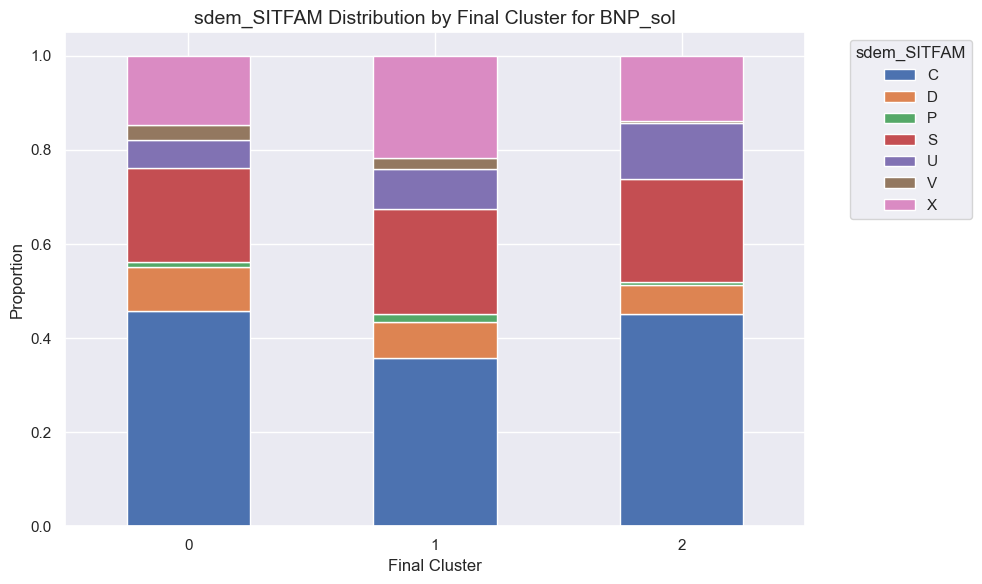

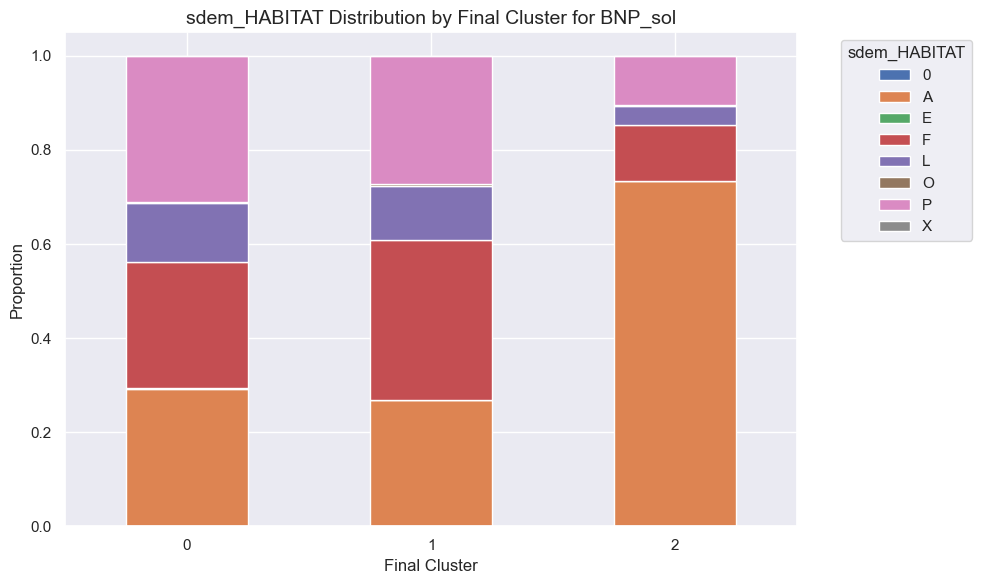

In [88]:
for var in non_metric_features:
    ct = pd.crosstab(
        BNP_sol[cluster_col_sol],
        BNP_sol[var],
        normalize="index"
    )

    ax = ct.plot(
        kind="bar",
        stacked=True,
        figsize=(10,6)
    )

    ax.set_title(f"{var} Distribution by Final Cluster for BNP_sol", fontsize=14)
    ax.set_xlabel("Final Cluster")
    ax.set_ylabel("Proportion")

    ax.legend(
        title=var,
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

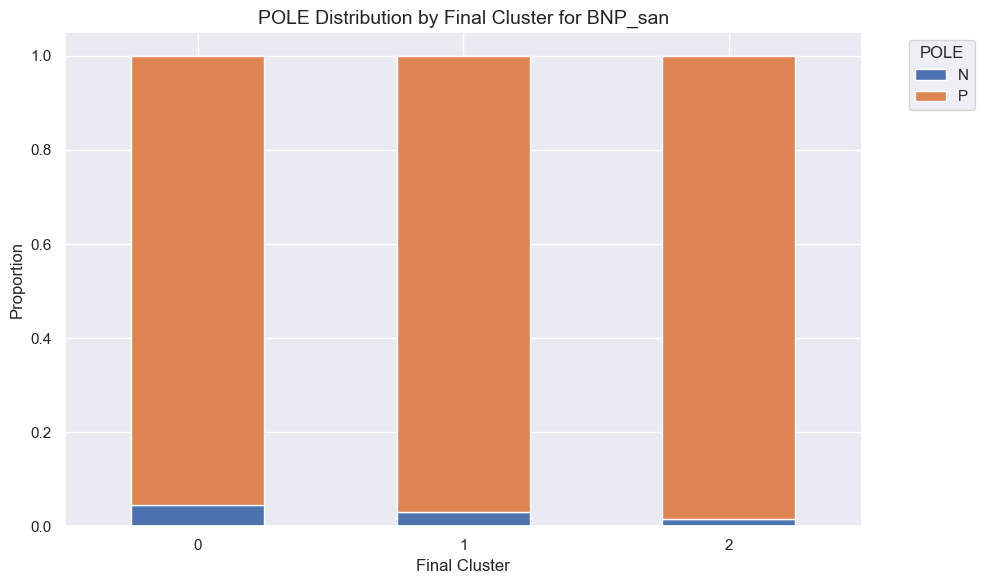

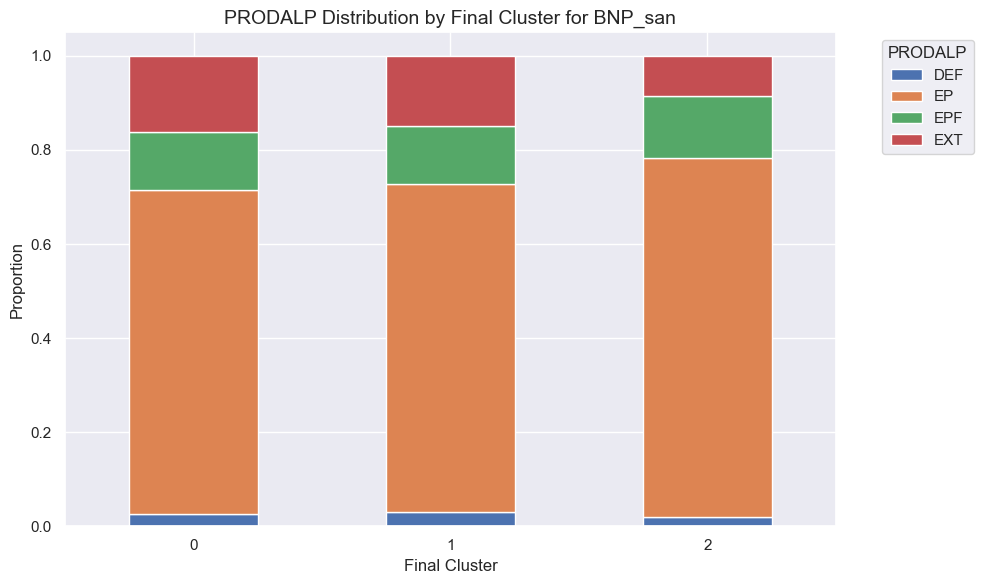

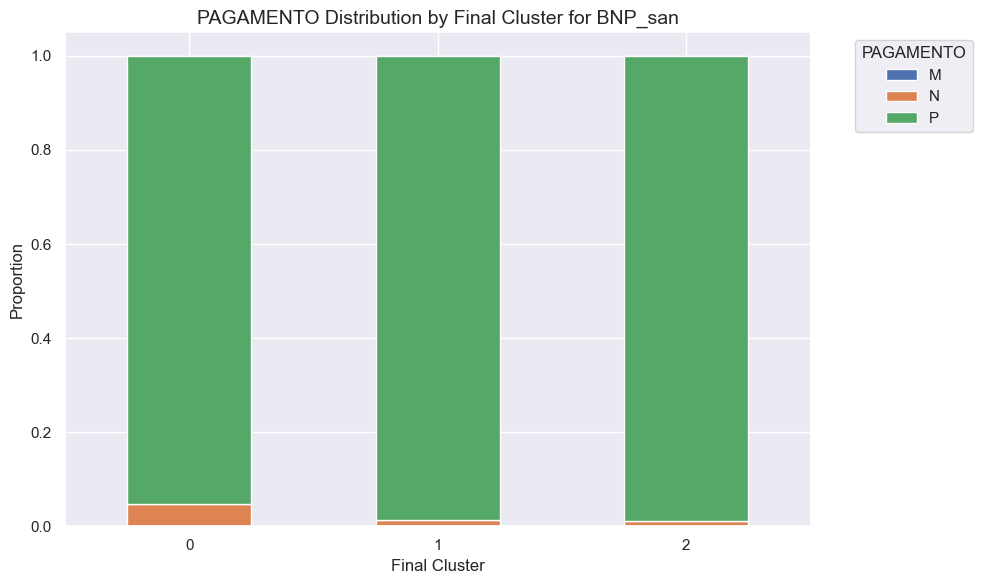

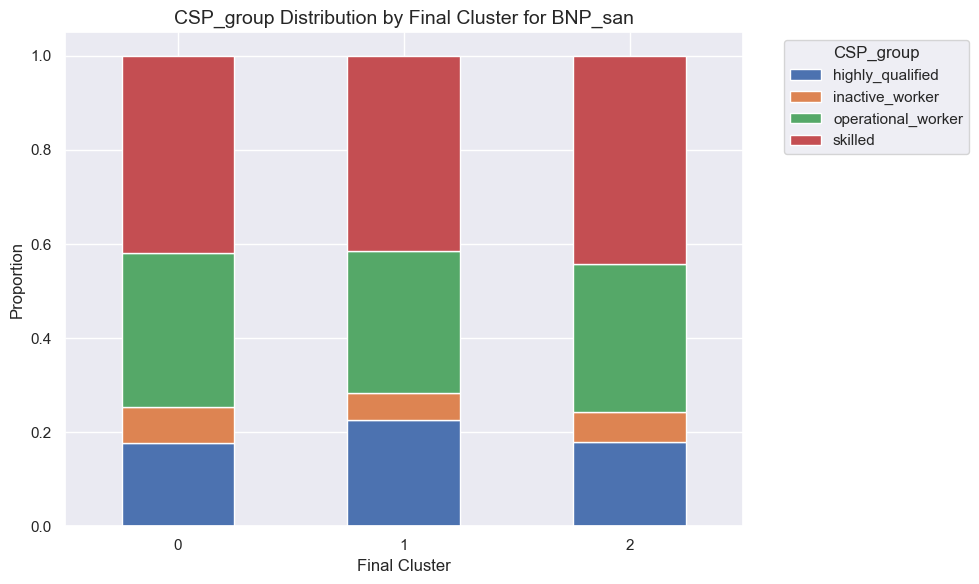

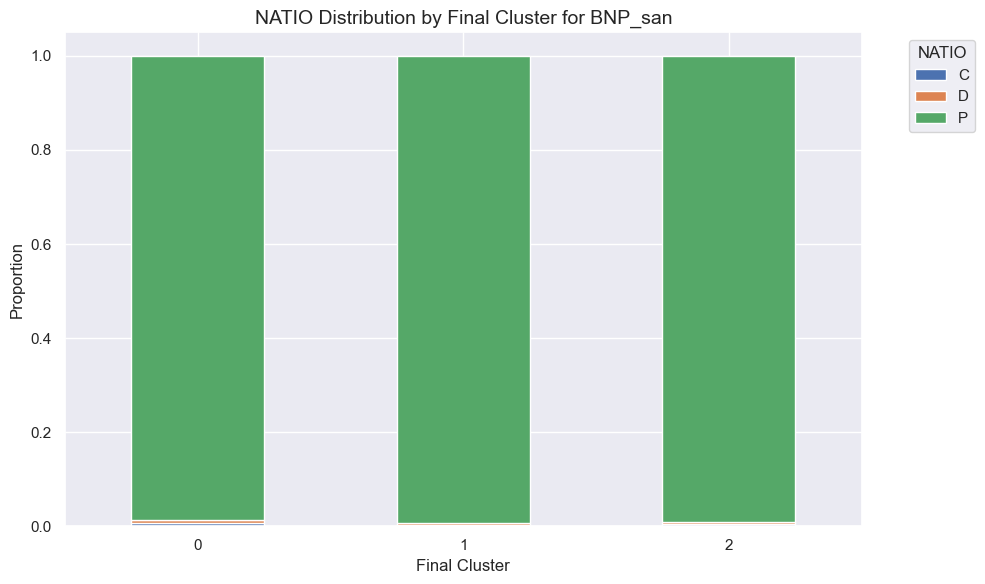

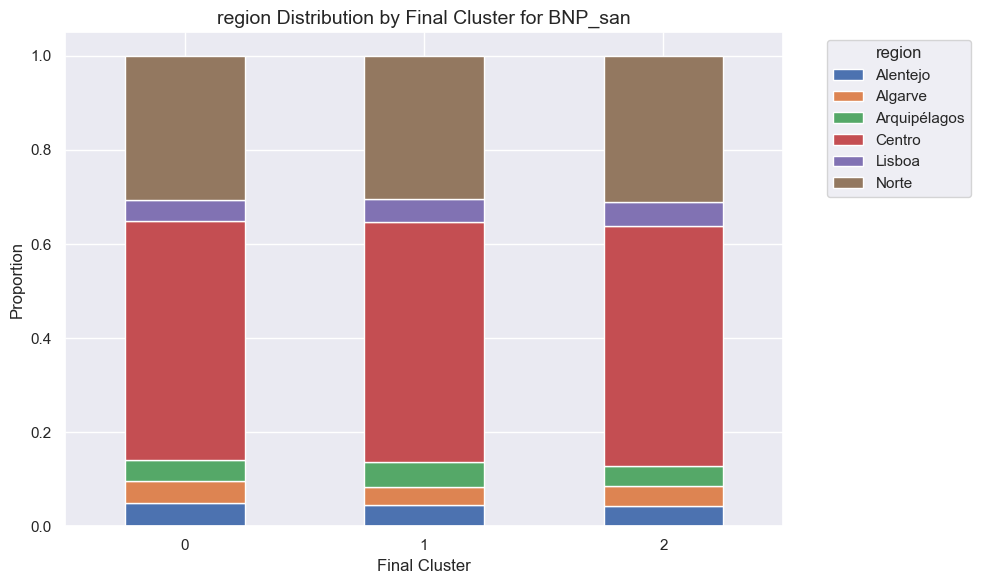

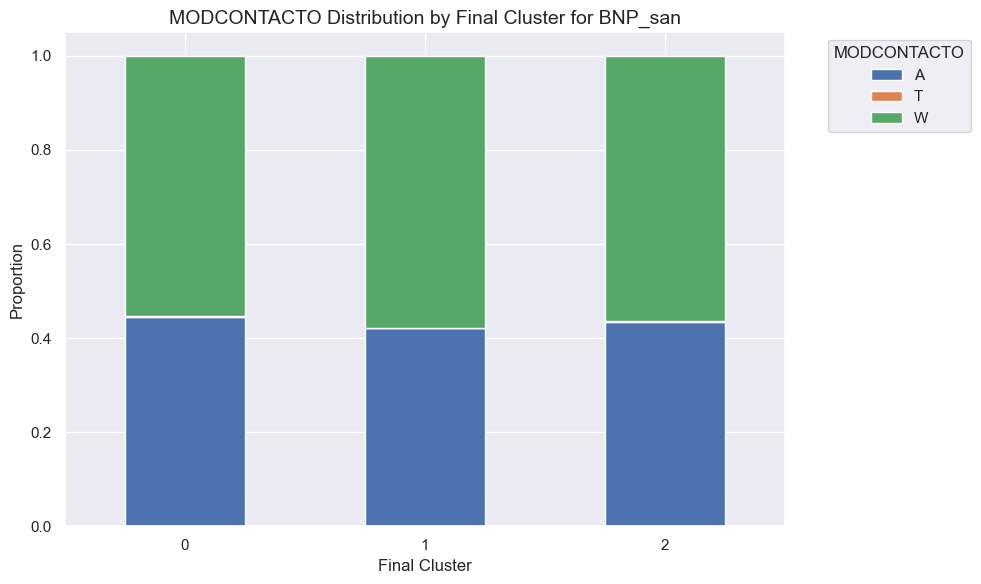

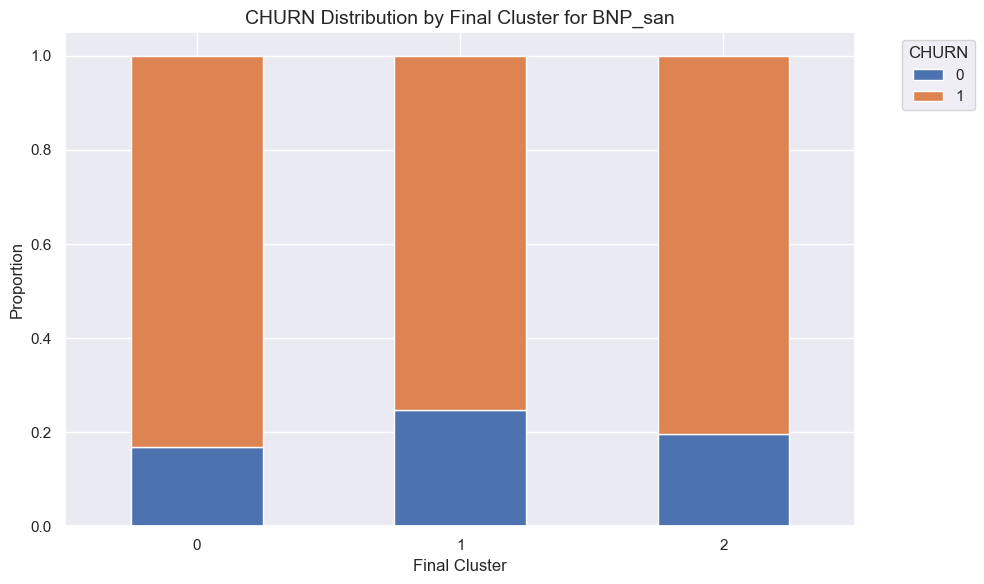

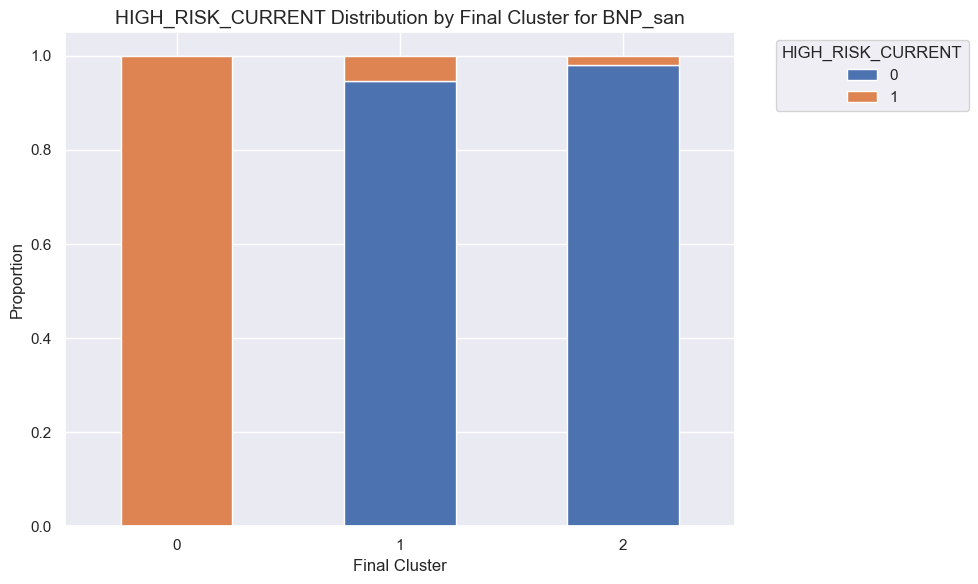

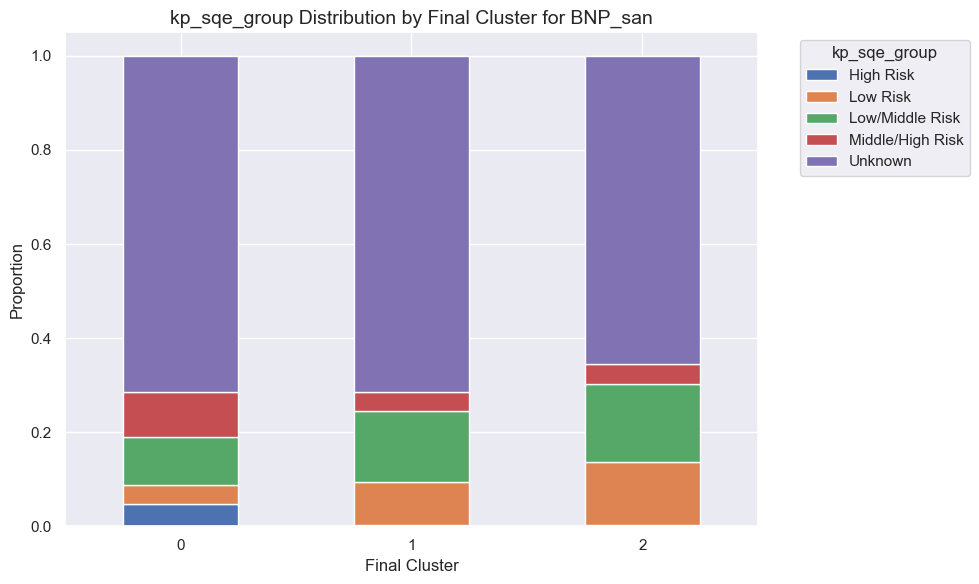

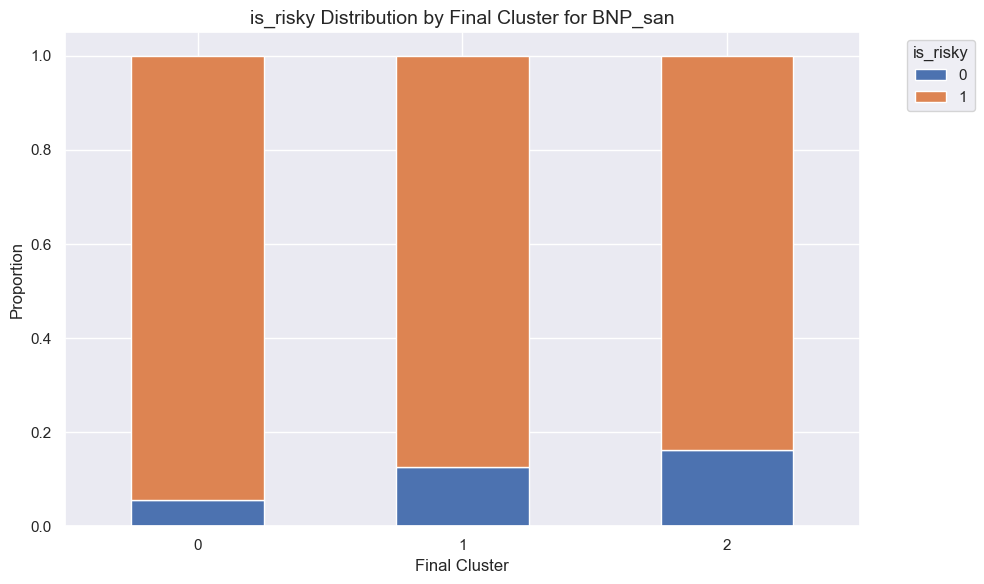

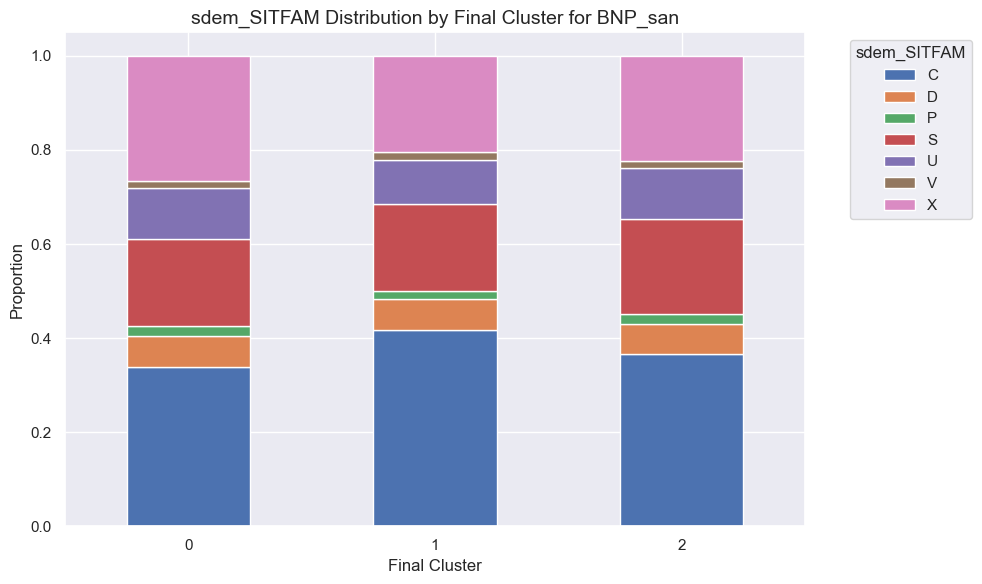

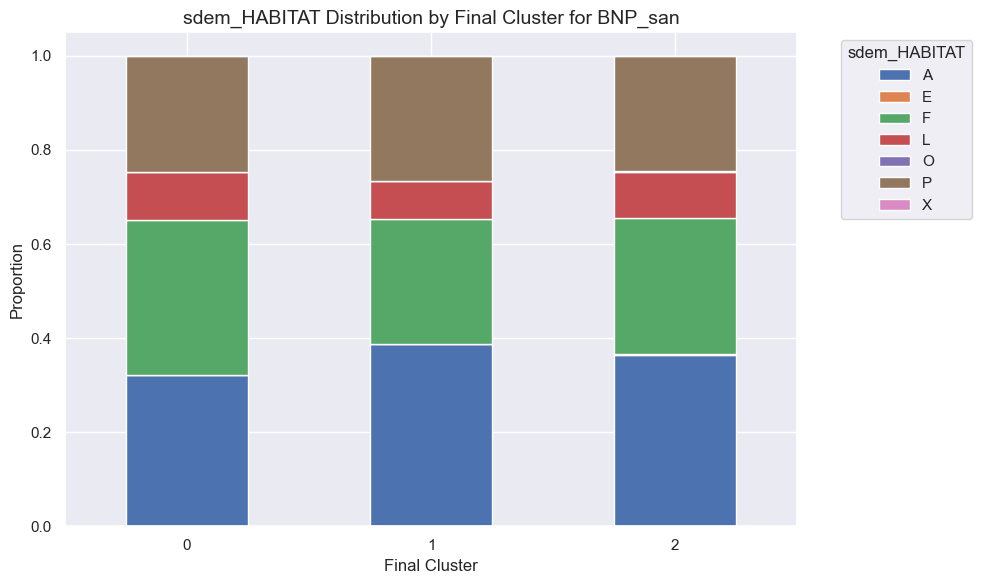

In [89]:
for var in non_metric_features:
    ct = pd.crosstab(
        BNP_san[cluster_col_san],
        BNP_san[var],
        normalize="index"
    )

    ax = ct.plot(
        kind="bar",
        stacked=True,
        figsize=(10,6)
    )

    ax.set_title(f"{var} Distribution by Final Cluster for BNP_san", fontsize=14)
    ax.set_xlabel("Final Cluster")
    ax.set_ylabel("Proportion")

    ax.legend(
        title=var,
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

<a class="anchor" id="3.4 feature importance">

## 3.4 Feature importance
    
</a>

In [90]:
def get_ss_variables(data):
    """Get the SS for each variable
    """
    ss_vars = data.var() * (data.count() - 1)
    return ss_vars

def r2_variables(data, labels):
    """Get the R² for each variable
    """
    sst_vars = get_ss_variables(data)
    ssw_vars = np.sum(data.groupby(labels).apply(get_ss_variables))
    return 1 - ssw_vars/sst_vars

In [94]:
r2_feats_sol = r2_variables(BNP_sol[financial_features + ['hc3_labels_sol']], 'hc3_labels_sol').drop('hc3_labels_sol')
r2_feats_sol

C:\Users\nicol\AppData\Local\Temp\ipykernel_21520\1761419925.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(data.groupby(labels).apply(get_ss_variables))
c:\Users\nicol\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


ALLBD_N_events__N            0.012848
count_cl                     0.025159
ALLBD_mean_duration_CL__N    0.009314
DURDEG                       0.000467
MTFINO                       0.008418
ks_score_tier                0.011739
RANGCLI                      0.007803
dividas_total_mean           0.572404
montenc_total_log            0.755903
dtype: float64

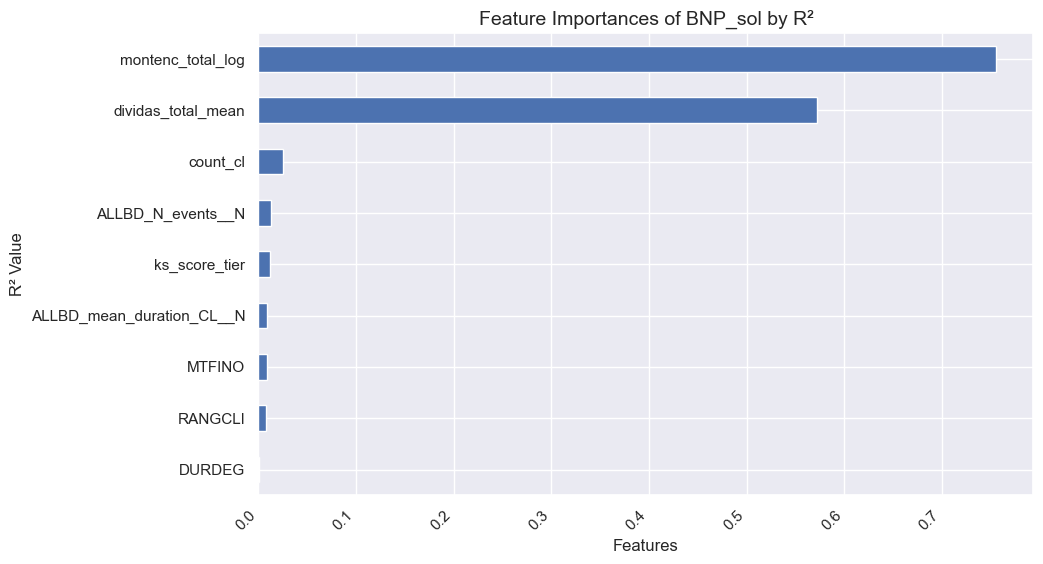

In [95]:
r2_feats_sol.sort_values().plot.barh(figsize=(10,6))
plt.title("Feature Importances of BNP_sol by R²", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("R² Value", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.show()

In [96]:
r2_feats_san = r2_variables(BNP_san[financial_features + ['hc3_labels_san']], 'hc3_labels_san').drop('hc3_labels_san')
r2_feats_san

C:\Users\nicol\AppData\Local\Temp\ipykernel_21520\1761419925.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ssw_vars = np.sum(data.groupby(labels).apply(get_ss_variables))
c:\Users\nicol\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


ALLBD_N_events__N            0.078081
count_cl                     0.339170
ALLBD_mean_duration_CL__N    0.022344
DURDEG                       0.006731
MTFINO                       0.022032
ks_score_tier                0.014557
RANGCLI                      0.002235
dividas_total_mean           0.021711
montenc_total_log            0.725379
dtype: float64

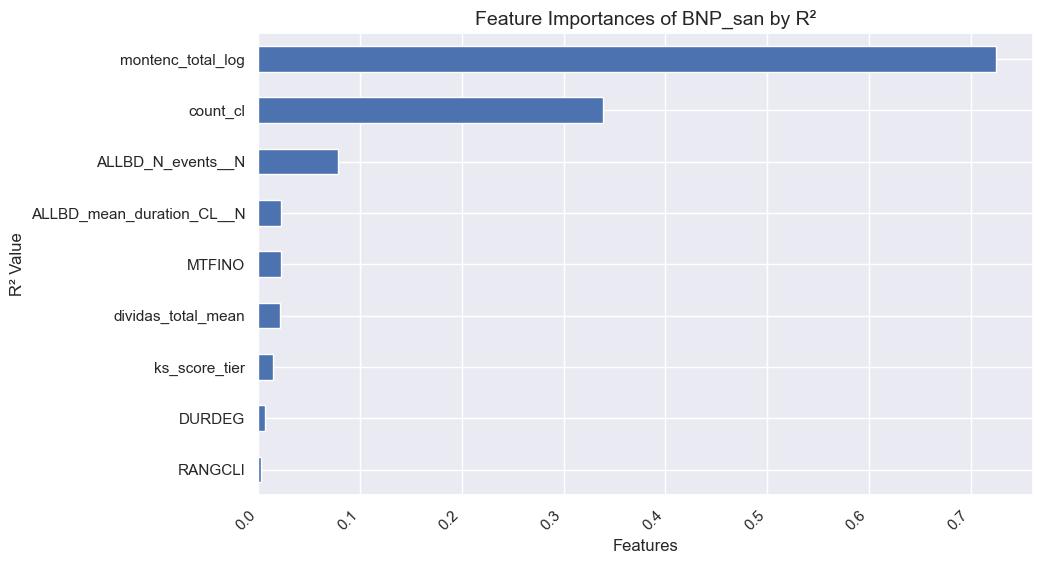

In [97]:
r2_feats_san.sort_values().plot.barh(figsize=(10,6))
plt.title("Feature Importances of BNP_san by R²", fontsize=14)
plt.xlabel("Features", fontsize=12)
plt.ylabel("R² Value", fontsize=12)
plt.xticks(rotation=45, ha='right') 
plt.show()

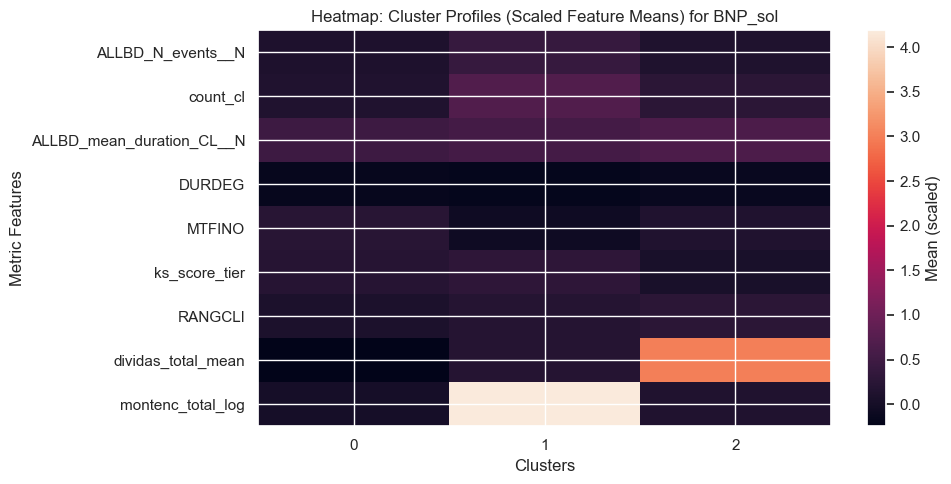

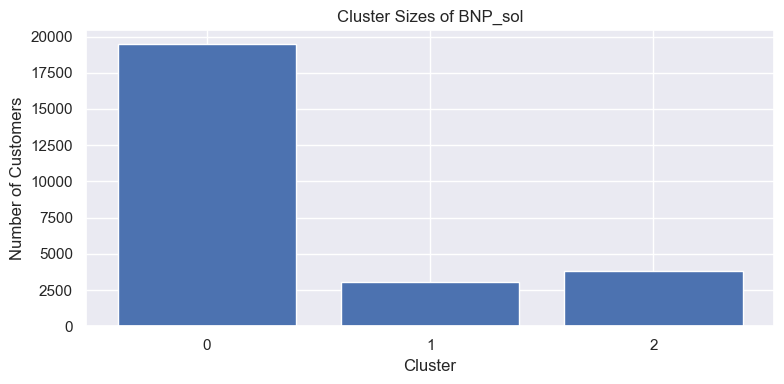

In [98]:
# 1) Cluster means (on scaled data)
# =========================
cluster_means_sol = (
    BNP_sol
    .groupby(cluster_col_sol)[financial_features]
    .mean()
)

# =========================
# 2) Heatmap (matplotlib only)
# =========================
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(cluster_means_sol.T.values, aspect="auto")

ax.set_title("Heatmap: Cluster Profiles (Scaled Feature Means) for BNP_sol")
ax.set_xlabel("Clusters")
ax.set_ylabel("Metric Features")

ax.set_xticks(range(cluster_means_sol.shape[0]))
ax.set_xticklabels(cluster_means_sol.index.astype(str))

ax.set_yticks(range(cluster_means_sol.shape[1]))
ax.set_yticklabels(cluster_means_sol.columns)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean (scaled)")

plt.tight_layout()
plt.show()

# =========================
# 3) Cluster sizes
# =========================
cluster_sizes_sol = (
    BNP_sol[cluster_col_sol]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(cluster_sizes_sol.index.astype(str), cluster_sizes_sol.values)
plt.title("Cluster Sizes of BNP_sol")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

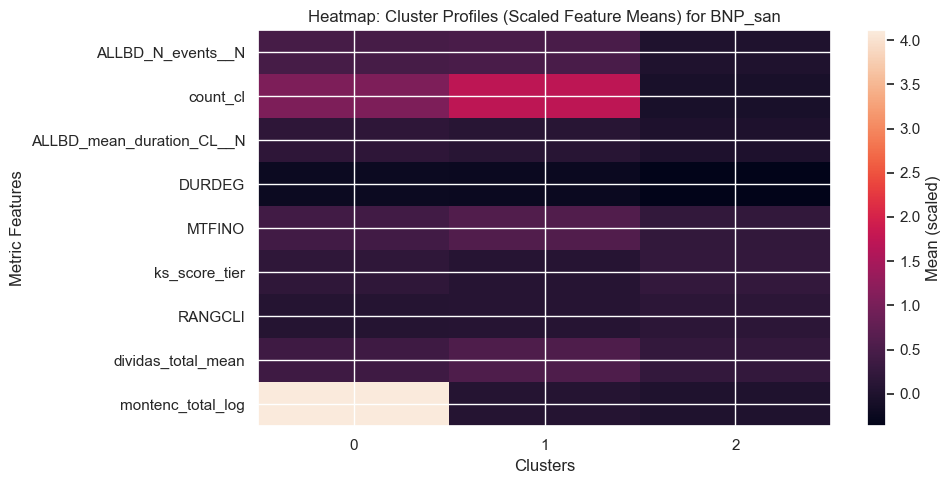

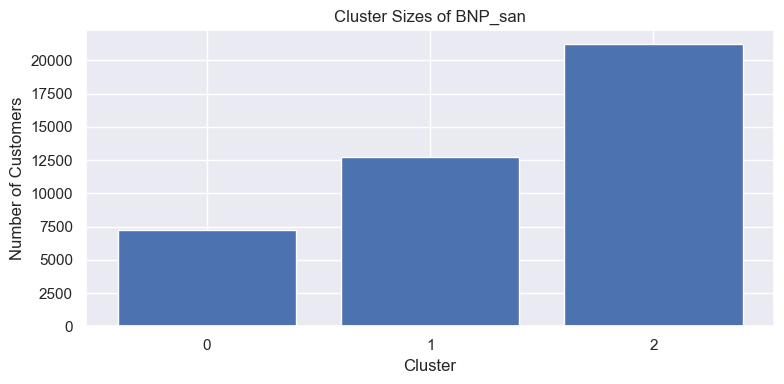

In [99]:
# 1) Cluster means (on scaled data)
# =========================
cluster_means_san = (
    BNP_san
    .groupby(cluster_col_san)[financial_features]
    .mean()
)

# =========================
# 2) Heatmap (matplotlib only)
# =========================
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(cluster_means_san.T.values, aspect="auto")

ax.set_title("Heatmap: Cluster Profiles (Scaled Feature Means) for BNP_san")
ax.set_xlabel("Clusters")
ax.set_ylabel("Metric Features")

ax.set_xticks(range(cluster_means_san.shape[0]))
ax.set_xticklabels(cluster_means_san.index.astype(str))

ax.set_yticks(range(cluster_means_san.shape[1]))
ax.set_yticklabels(cluster_means_san.columns)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean (scaled)")

plt.tight_layout()
plt.show()

# =========================
# 3) Cluster sizes
# =========================
cluster_sizes_san = (
    BNP_san[cluster_col_san]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 4))
plt.bar(cluster_sizes_san.index.astype(str), cluster_sizes_san.values)
plt.title("Cluster Sizes of BNP_san")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

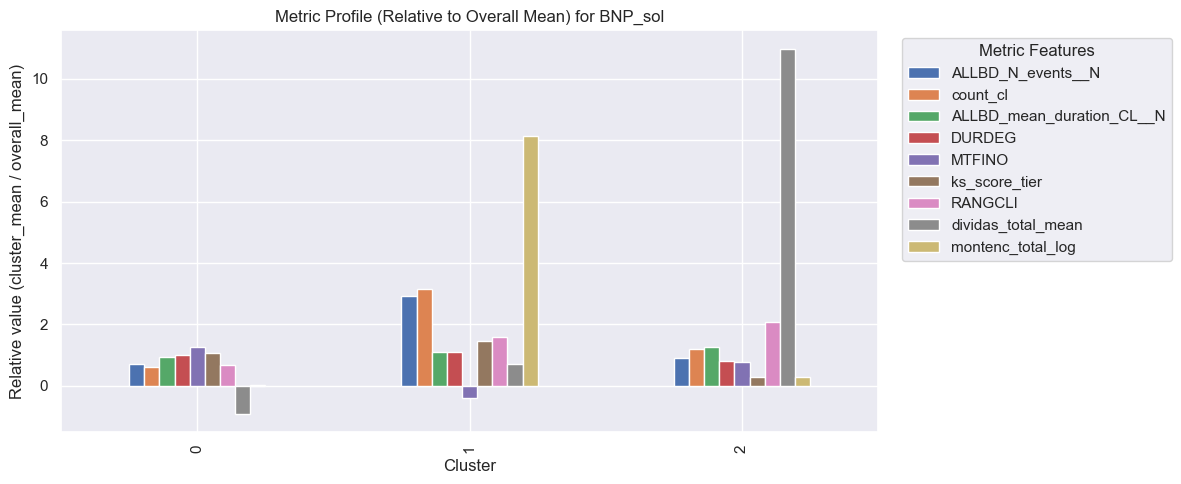

In [100]:
# Médias em valor original (não z-score)
cluster_means_raw_sol = BNP_sol.groupby(cluster_col_sol)[financial_features].mean()
overall_means_raw_sol = BNP_sol[financial_features].mean()

relative_sol = cluster_means_raw_sol / overall_means_raw_sol  # >1 acima da média, <1 abaixo

ax = relative_sol.plot(kind="bar", figsize=(12,5))
plt.title("Metric Profile (Relative to Overall Mean) for BNP_sol")
plt.xlabel("Cluster")
plt.ylabel("Relative value (cluster_mean / overall_mean)")
plt.legend(title="Metric Features", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

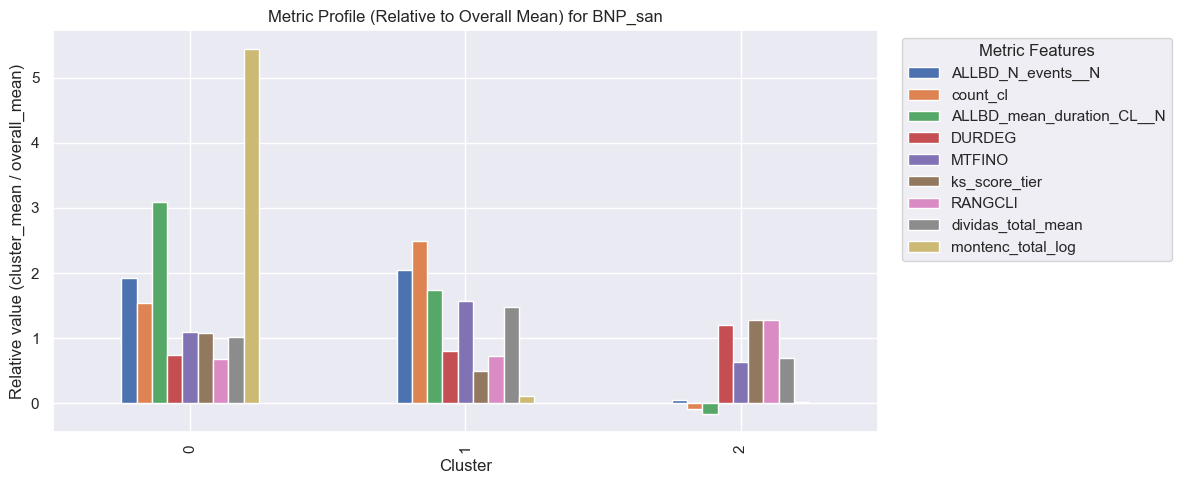

In [101]:
# Médias em valor original (não z-score)
cluster_means_raw_san = BNP_san.groupby(cluster_col_san)[financial_features].mean()
overall_means_raw_san = BNP_san[financial_features].mean()

relative_san = cluster_means_raw_san / overall_means_raw_san  # >1 acima da média, <1 abaixo

ax = relative_san.plot(kind="bar", figsize=(12,5))
plt.title("Metric Profile (Relative to Overall Mean) for BNP_san")
plt.xlabel("Cluster")
plt.ylabel("Relative value (cluster_mean / overall_mean)")
plt.legend(title="Metric Features", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()